# 07 — Check and Clean
Post-Nominatim enrichment: n_civ direct recheck (tier 1b/2b), linear interpolation for still-missing civic numbers (tier 8), manual geocoding (tier 9), and final cross-source stats.

Pipeline position: OCR -> Evaluation -> Version Selection -> Statistics -> Geocoder -> Nominatim Geocoder -> Check and Clean


## Imports


In [1]:
import io
import re
import json
import time
import glob
import urllib.request
import urllib.parse
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import openai
from pathlib import Path
from datetime import datetime
from shapely.geometry import Point
from rapidfuzz import fuzz, process

from config import (
    DRIVE_ROOT_FOLDER,
    DRIVE_GEOSPATIAL_FOLDER,
    DRIVE_NOMINATIM_FOLDER,
    DRIVE_OUTPUTS_FOLDER,
    DRIVE_CLEAN_PAGES_FOLDER,
    DRIVE_FINAL_FOLDER,
    SESTIERE_PATH,
    NCIV_PATH,
    GEOCODER_OUTPUT_DIR,
    NOMINATIM_OUTPUT_DIR,
    FINAL_OUTPUT_DIR,
    FINAL_DETAIL_CSV_DIR,
    FINAL_DETAIL_GEOJSON_DIR,
    FINAL_CLEANING_DIR,
    FINAL_AUDIT_DIR,
    CLEAN_PAGES_DIR,
    SAVE_MODE,
    OPENAI_KEY_FILE,
)

print("Notebook 07 — Check and Clean")
print(f"Save mode: {SAVE_MODE}")


Notebook 07 — Check and Clean
Save mode: both


## Drive helpers
Shared Drive auth, folder resolution, and save/upload functions.


In [ ]:
#  CELL 2 — DRIVE HELPERS AND SAVE/UPLOAD FUNCTIONS

from drive_utils import (
    get_drive_service,
    find_folder,
    list_files_in_folder,
    download_text,
    upload_text,
    upload_bytes,
    save_or_upload_csv,
    save_or_upload_geojson,
    normalize_tier_column,
    find_csv_by_name,
    find_run_folder,
)


print("  Drive helpers loaded.")



  Drive helpers loaded.


/Users/charlottegarcia/global_venv/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.2.3) or chardet (7.2.0)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


## Configuration
Which Nominatim run to enrich, final/ folder setup.


In [ ]:

# Point to the nominatim run we chose
NOMINATIM_RUN_NAME = "nominatim_20260721_1922"

# ── Setup final/ folder on Drive and local ────────────────────────────
_final_local = Path(FINAL_OUTPUT_DIR)
_final_local.mkdir(parents=True, exist_ok=True)

_svc_f  = get_drive_service()
_root_f = find_folder(_svc_f, DRIVE_ROOT_FOLDER)
_geo_f  = find_folder(_svc_f, DRIVE_GEOSPATIAL_FOLDER, _root_f)
_existing_final = _svc_f.files().list(
    q=f"name='{DRIVE_FINAL_FOLDER}' and '{_geo_f}' in parents "
      "and trashed=false and "
      "mimeType='application/vnd.google-apps.folder'",
    fields="files(id,name)",
    supportsAllDrives=True, includeItemsFromAllDrives=True
).execute().get("files", [])
if _existing_final:
    _final_drive_id = _existing_final[0]["id"]
    print(f"Final folder found on Drive: {DRIVE_FINAL_FOLDER}/")
else:
    _final_drive_id = _svc_f.files().create(
        body={"name": DRIVE_FINAL_FOLDER, "parents": [_geo_f],
              "mimeType": "application/vnd.google-apps.folder"},
        fields="id", supportsAllDrives=True
    ).execute()["id"]
    print(f"Final folder created on Drive: {DRIVE_FINAL_FOLDER}/")

# ── Cached folder IDs, reused by every cell below instead of re-resolving the same folders via repeated Drive API calls ─────
ROOT_ID       = _root_f
GEO_ID        = _geo_f
FINAL_ID      = _final_drive_id
OUTPUTS_ID    = find_folder(_svc_f, DRIVE_OUTPUTS_FOLDER, GEO_ID)
NOMINATIM_ID  = find_folder(_svc_f, DRIVE_NOMINATIM_FOLDER, GEO_ID)
CLEAN_PAGES_ID = find_folder(_svc_f, DRIVE_CLEAN_PAGES_FOLDER, ROOT_ID)

_final_detail_id = get_or_create_folder(_svc_f, "detail", FINAL_ID)
FINAL_DETAIL_CSV_ID     = get_or_create_folder(_svc_f, "csv", _final_detail_id)
FINAL_DETAIL_GEOJSON_ID = get_or_create_folder(_svc_f, "geojson", _final_detail_id)
FINAL_AUDIT_ID            = get_or_create_folder(_svc_f, "audit", FINAL_ID)

# ── Save helpers for final/ folder ───────────────────────────────────
def _save(name, df_to_save):
    save_or_upload_csv(df_to_save, Path(FINAL_DETAIL_CSV_DIR) / name, _svc_f, FINAL_DETAIL_CSV_ID)
    print(f"  Saved: {name} ({len(df_to_save)} rows)")

def _save_geojson(name, gdf):
    save_or_upload_geojson(gdf, Path(FINAL_DETAIL_GEOJSON_DIR) / name, _svc_f, FINAL_DETAIL_GEOJSON_ID)
    print(f"  Saved: {name} ({len(gdf)} rows)")

print(f"Nominatim run: {NOMINATIM_RUN_NAME}")
print(f"Final output : {FINAL_OUTPUT_DIR}")

# ── Local-first file/folder helpers ────────────────────────────────────

def _load_csv(name_contains, local_dir, drive_folder_id, service=_svc_f,
              exclude_prefixes=(), exclude_suffixes=(".geojson",)):
    return find_csv_by_name(name_contains, local_dir, drive_folder_id, service=service,
                             exclude_prefixes=exclude_prefixes, exclude_suffixes=exclude_suffixes)


def _find_run_folder(local_base, drive_parent_id, name_prefix, required_substrings, service=_svc_f):
    return find_run_folder(local_base, drive_parent_id, name_prefix, required_substrings, service=service)


Final folder found on Drive: final/
Nominatim run: nominatim_20260721_1922
Final output : ./geospatial/final


## n_civ direct match (sestiere recheck)
Tier 1b: exact civic number via sestiere join. Tier 2b: sestiere normalisation (Sant'Elena -> Castello).


In [ ]:
#  CELL 4 — n_civ DIRECT MATCH (SESTIERE RECHECK)
#  Tier 1b: exact civic number match via sestiere join
#  Tier 2b: match via sestiere normalisation (Sant'Elena→Castello)

RUN_NCIV_DIRECT = True

if RUN_NCIV_DIRECT:
    print("=== CELL 4 — n_civ SESTIERE RECHECK ===\n")

    # ── Find latest nominatim run folder (local first, Drive fallback) ─
    _svc_n  = get_drive_service()
    _root_n = ROOT_ID
    _geo_n  = GEO_ID
    _nom_n  = NOMINATIM_ID

    _nom_local_dir, _nom_folder_id, _nom_folder_name = _find_run_folder(
        NOMINATIM_OUTPUT_DIR, _nom_n, "nominatim_",
        ["unmatched_inside", "nominatim_inside_matched"], service=_svc_n
    )

    if not _nom_folder_name:
        raise RuntimeError("No complete nominatim run folder found locally or on Drive")
    print(f"  Using nominatim run: {_nom_folder_name}")

    def _load_nom_file(name_contains):
        df, _ = _load_csv(
            name_contains,
            _nom_local_dir if _nom_local_dir else Path(NOMINATIM_OUTPUT_DIR) / "__none__",
            _nom_folder_id, service=_svc_n
        )
        return df

    df_unmatched = _load_nom_file("unmatched_inside")
    print(f"  Unmatched inside loaded: {len(df_unmatched)} rows")
    print(f"  of which number_not_in_reference: "
          f"{(df_unmatched['fail_reason'] == 'number_not_in_reference').sum()}")

    # ── Sestiere key normalisation ────────────────────────────────────
    # Track which rows used normalisation (→ tier 2b vs 1b)

    def sestiere_key(value):
        if pd.isna(value):
            return pd.NA
        value = re.sub(r"\s+", " ", str(value).strip().upper().replace(".", ""))
        return {
            "S MARCO":    "SAN MARCO",
            "S POLO":     "SAN POLO",
            "S CROCE":    "SANTA CROCE",
            "SAN CROCE":  "SANTA CROCE",
            "GUIDECCA":   "GIUDECCA",
            "SANT ELENA": "CASTELLO",
        }.get(value, value)

    # ── Load n_civ and sestieri ───────────────────────────────────────
    n_civ    = gpd.read_file(NCIV_PATH, on_invalid="ignore")
    sestieri = gpd.read_file(SESTIERE_PATH)

    n_civ["nc_num"] = pd.to_numeric(
        n_civ["NC_NUM"], errors="coerce"
    ).astype("Int64")
    n_civ_valid = n_civ[n_civ.geometry.notna() & n_civ["nc_num"].notna()].copy()

    n_civ_pts = n_civ_valid.copy()
    n_civ_pts["geometry"] = n_civ_pts.geometry.centroid
    n_civ_pts = n_civ_pts.to_crs(sestieri.crs)

    print("  Joining n_civ to sestieri polygons ...")
    n_civ_joined = gpd.sjoin(
        n_civ_pts[["nc_num", "NC_LETT", "geometry"]],
        sestieri[["division_name", "geometry"]],
        how="left", predicate="within"
    )
    n_civ_joined = n_civ_joined[n_civ_joined["division_name"].notna()].copy()
    n_civ_joined["_sestiere_key"] = n_civ_joined["division_name"].map(sestiere_key)
    print(f"  n_civ points assigned to sestiere: {len(n_civ_joined)}")

    n_civ_wgs84 = n_civ_joined.copy()
    n_civ_wgs84 = n_civ_wgs84.to_crs("EPSG:4326")
    n_civ_wgs84["lon"] = n_civ_wgs84.geometry.x
    n_civ_wgs84["lat"] = n_civ_wgs84.geometry.y
    n_civ_lookup = (
        n_civ_wgs84
        .groupby(["_sestiere_key", "nc_num"], as_index=False)
        .agg(lat=("lat", "mean"), lon=("lon", "mean"))
    )
    n_civ_lookup_set = set(
        zip(n_civ_lookup["_sestiere_key"], n_civ_lookup["nc_num"])
    )
    print(f"  n_civ lookup keys built: {len(n_civ_lookup_set)}")

    # ── Match ─────────────────────────────────────────────────────────
    df = df_unmatched.copy()
    df["_sestiere_key"] = df["sestiere_parsed"].map(sestiere_key)
    df["_civic_num"]    = pd.to_numeric(
        df["civic_num"], errors="coerce"
    ).astype("Int64")

    has_both   = df["_sestiere_key"].notna() & df["_civic_num"].notna()
    candidates = df[has_both].copy()
    print(f"  Rows with sestiere+number to check: {len(candidates)}")

    direct_mask = candidates.apply(
        lambda r: (r["_sestiere_key"], r["_civic_num"]) in n_civ_lookup_set,
        axis=1
    )
    direct_df = candidates[direct_mask].copy()
    _direct_df_original_index = direct_df.index  # merge() below resets the index -- save it first
    direct_df = direct_df.merge(
        n_civ_lookup.rename(columns={"nc_num": "_civic_num"}),
        on=["_sestiere_key", "_civic_num"], how="left"
    )
    direct_df.index = _direct_df_original_index
    direct_df["matched_lat"] = direct_df["lat"]
    direct_df["matched_lon"] = direct_df["lon"]
    direct_df["matched_sestiere"] = direct_df["_sestiere_key"]

    # Assign tier 1b or 2b
    direct_df["geocoding_tier"]   = "1b"
    direct_df["match_confidence"] = "nciv_direct_exact"
    direct_df["match_note"]       = (
        "Exact civic number match via direct sestiere join — "
        "recovered from nb05 parish boundary miss"
    )
    direct_df = direct_df.drop(
        columns=["lat","lon","_sestiere_key",
                 "_civic_num","_original_key"], errors="ignore"
    )

    unmatched_remaining = df_unmatched.drop(
        index=direct_df.index, errors="ignore"
    ).reset_index(drop=True)

    # ── Store for Cell 5 ──────────────────────────────────────────────
    NCIV_DIRECT_INDICES = set(direct_df.index)
    DF_UNMATCHED_FOR_5  = df
    N_CIV_JOINED_FOR_5  = n_civ_joined

    # ── Results ───────────────────────────────────────────────────────
    print(f"\n=== CELL 4 RESULTS ===")
    print(f"  Total unmatched inside (input)  : {len(df_unmatched)}")
    print(f"  Candidates (sestiere+number)    : {len(candidates)}")
    print(f"  Tier 1b (exact match)           : {(direct_df['geocoding_tier']=='1b').sum()}")
    print(f"  Total newly matched             : {len(direct_df)}")
    print(f"  Recovery rate                   : "
          f"{100*len(direct_df)/max(len(candidates),1):.1f}% of candidates")
    print(f"  Still unmatched                 : {len(unmatched_remaining)}")
    if not direct_df.empty:
        print(f"\n  Sestiere breakdown:")
        print(direct_df["sestiere_parsed"].value_counts().to_string())
        print(f"\n  Sample matches:")
        print(direct_df[["Name","Address","sestiere_parsed","civic_num",
                          "geocoding_tier","matched_lat",
                          "matched_lon"]].head(8).to_string(index=False))

    # ── Save ──────────────────────────────────────────────────────────
    _save("nciv_check_matched.csv", direct_df)
    if not direct_df.empty:
        _save_geojson("nciv_check_matched.geojson", gpd.GeoDataFrame(
            direct_df,
            geometry=gpd.points_from_xy(
                direct_df["matched_lon"], direct_df["matched_lat"]
            ), crs="EPSG:4326"
        ))
    _save("nciv_check_unmatched.csv", unmatched_remaining)
    print(f"\n=== CELL 4 DONE ===")

else:
    print("Cell 4 skipped (RUN_NCIV_DIRECT=False)")
    NCIV_DIRECT_INDICES = set()
    DF_UNMATCHED_FOR_5  = None
    N_CIV_JOINED_FOR_5  = None

=== CELL 4 — n_civ SESTIERE RECHECK ===

  Using nominatim run: nominatim_20260721_1922
  Unmatched inside loaded: 3398 rows
  of which number_not_in_reference: 928
  Final folder ready
  Joining n_civ to sestieri polygons ...
  n_civ points assigned to sestiere: 34506
  n_civ lookup keys built: 25931
  Rows with sestiere+number to check: 866

=== CELL 4 RESULTS ===
  Total unmatched inside (input)  : 3398
  Candidates (sestiere+number)    : 866
  Tier 1b (exact match)           : 266
  Total newly matched             : 266
  Recovery rate                   : 30.7% of candidates
  Still unmatched                 : 3132

  Sestiere breakdown:
sestiere_parsed
CASTELLO       71
CANNAREGIO     62
SAN POLO       62
SANT'ELENA     27
SANTA CROCE    25
DORSODURO      19

  Sample matches:
                 Name                  Address sestiere_parsed  civic_num geocoding_tier  matched_lat  matched_lon
   Ing. Gildo Sperati   Cannaregio numero 6104      CANNAREGIO     6104.0             1b    

## n_civ linear interpolation
Tier 8: rows within 10m of a known door.


=== CELL 5 — n_civ LINEAR INTERPOLATION ===

  Loaded from memory: 3132 rows
  Rows to attempt interpolation: 600
  Interpolation results:
    accepted (≤10m): 393
    rejected (>10m): 34
    no numeric bounds:       173
    missing key/no doors:    0
    not attempted:           2532

  unmatched_after_interpolation: 2739 rows
  fail_reason breakdown:
fail_reason
no_civic_number                    2470
no_numeric_bounds                   173
number_not_in_reference              62
interpolation_distance_exceeded      34


/var/folders/zx/y690zk891278q0tkfsym931c0000gn/T/ipykernel_1622/1242965021.py:230: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


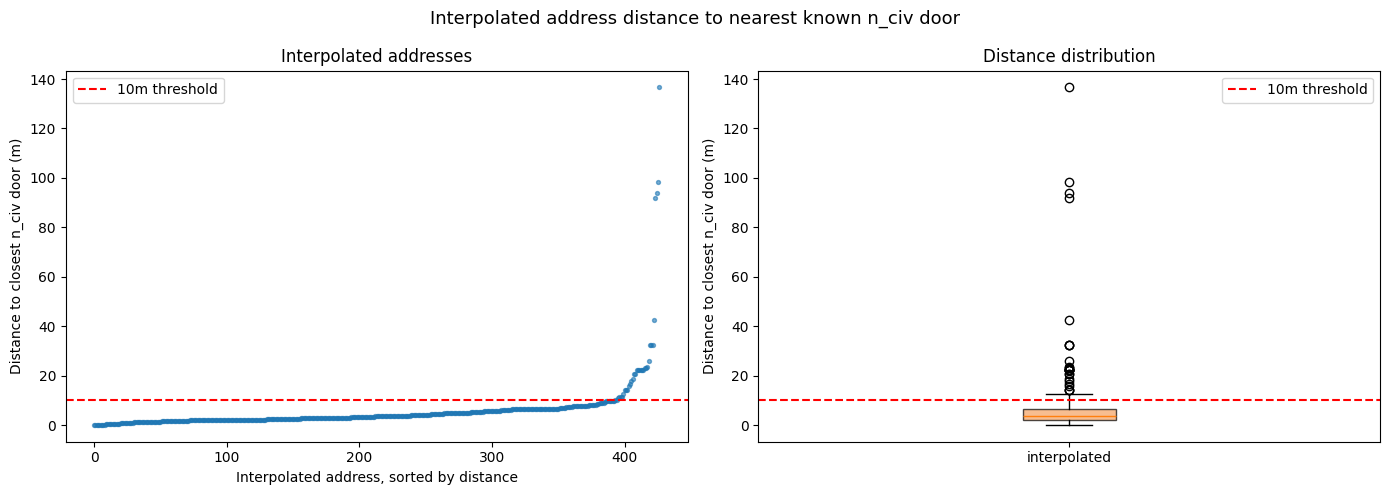


  Distance stats (all interpolated):
    count : 427
    min   : 0.07m
    median: 3.46m
    mean  : 5.83m
    p90   : 8.95m
    max   : 136.59m
  Saved (local+Drive): nciv_interpolated_matched.csv (393 rows)
  Saved (local+Drive): nciv_interpolated_matched.geojson (393 rows)
  Saved (local+Drive): unmatched_after_interpolation.csv (2739 rows)

=== CELL 5 DONE ===
  nciv_interpolated_matched  : 393 rows
  unmatched_after_interpolation: 2739 rows


In [75]:
#  CELL 5 — n_civ LINEAR INTERPOLATION
#
#  Input: nciv_check_unmatched.csv (output of Cell 4)
#  Outputs:
#    nciv_interpolated_matched.csv/.geojson — within 10m (tier 8)
#    interpolation_unmatched.csv — all remaining rows
#      includes interpolation_distance_exceeded flag
#      includes no_numeric_bounds flag
#      includes no_civic_number / number_not_in_reference

RUN_NCIV_INTERPOLATION       = True
MAX_INTERPOLATION_DISTANCE_M = 10

if RUN_NCIV_INTERPOLATION:
    print("=== CELL 5 — n_civ LINEAR INTERPOLATION ===\n")

    if DF_UNMATCHED_FOR_5 is None or N_CIV_JOINED_FOR_5 is None:
        raise RuntimeError("Run Cell 4 first — DF_UNMATCHED_FOR_5 or "
                           "N_CIV_JOINED_FOR_5 not in memory")

    # ── Load remaining unmatched ──────────────────────────────────────
    try:
        df_remaining = DF_UNMATCHED_FOR_5.copy()
        df_remaining = df_remaining[
            ~df_remaining.index.isin(NCIV_DIRECT_INDICES)
        ].copy()
        print(f"  Loaded from memory: {len(df_remaining)} rows")
    except Exception:
        print("  Memory load failed — loading nciv_check_unmatched (local first) ...")
        _svc_r  = get_drive_service()
        _root_r = ROOT_ID
        _geo_r  = GEO_ID
        _fin_r  = FINAL_ID
        df_remaining, _ = _load_csv(
            "nciv_check_unmatched", FINAL_OUTPUT_DIR, _fin_r, service=_svc_r
        )
        print(f"  Loaded: {len(df_remaining)} rows")

    # ── Build projected known_doors per sestiere ──────────────────────
    n_civ_proj = N_CIV_JOINED_FOR_5.copy()
    if not n_civ_proj.crs.is_projected:
        n_civ_proj = n_civ_proj.to_crs("EPSG:32633")
    n_civ_proj["x"] = n_civ_proj.geometry.x
    n_civ_proj["y"] = n_civ_proj.geometry.y

    known_doors = (
        n_civ_proj
        .groupby(["_sestiere_key", "nc_num"], as_index=False)
        .agg(x=("x", "mean"), y=("y", "mean"))
    )
    known_doors = gpd.GeoDataFrame(
        known_doors,
        geometry=gpd.points_from_xy(known_doors["x"], known_doors["y"]),
        crs=n_civ_proj.crs,
    )
    known_doors_by_sestiere = {
        s: g.sort_values("nc_num").reset_index(drop=True)
        for s, g in known_doors.groupby("_sestiere_key")
    }

    def interpolate_address(row):
        sestiere  = row.get("_sestiere_key")
        door_numb = row.get("_civic_num")
        if pd.isna(sestiere) or pd.isna(door_numb):
            return pd.Series({"interp_status": "missing_key"})
        door_numb = int(door_numb)
        doors = known_doors_by_sestiere.get(sestiere)
        if doors is None or doors.empty:
            return pd.Series({"interp_status": "no_doors_for_sestiere"})
        prev = doors[doors["nc_num"] < door_numb]
        nxt  = doors[doors["nc_num"] > door_numb]
        if prev.empty or nxt.empty:
            return pd.Series({"interp_status": "no_numeric_bounds"})
        p0   = prev.iloc[-1]
        n0   = nxt.iloc[0]
        frac = (door_numb - int(p0["nc_num"])) / (
            int(n0["nc_num"]) - int(p0["nc_num"])
        )
        pt   = Point(
            p0.geometry.x + (n0.geometry.x - p0.geometry.x) * frac,
            p0.geometry.y + (n0.geometry.y - p0.geometry.y) * frac,
        )
        dist = float(doors.geometry.distance(pt).min())
        return pd.Series({
            "interp_status":   "interpolated",
            "interp_geometry": pt,
            "interp_dist_m":   dist,
        })

    # ── Run interpolation on candidates with sestiere+number ──────────
    df_candidates = df_remaining[
        df_remaining.get("_sestiere_key", pd.Series(dtype=str)).notna() &
        df_remaining.get("_civic_num", pd.Series(dtype=float)).notna()
    ].copy() if "_sestiere_key" in df_remaining.columns else pd.DataFrame()

    if df_candidates.empty:
        # Recompute keys if not in memory
        def _sestiere_key_local(value):
            if pd.isna(value):
                return pd.NA
            value = re.sub(
                r"\s+", " ", str(value).strip().upper().replace(".", "")
            )
            return {
                "S MARCO": "SAN MARCO", "S POLO": "SAN POLO",
                "S CROCE": "SANTA CROCE", "SAN CROCE": "SANTA CROCE",
                "GUIDECCA": "GIUDECCA", "SANT ELENA": "CASTELLO",
            }.get(value, value)

        df_remaining["_sestiere_key"] = df_remaining[
            "sestiere_parsed"
        ].map(_sestiere_key_local)
        df_remaining["_civic_num"] = pd.to_numeric(
            df_remaining["civic_num"], errors="coerce"
        ).astype("Int64")
        df_candidates = df_remaining[
            df_remaining["_sestiere_key"].notna() &
            df_remaining["_civic_num"].notna()
        ].copy()

    print(f"  Rows to attempt interpolation: {len(df_candidates)}")
    interp_res    = df_candidates.apply(interpolate_address, axis=1)
    df_candidates = df_candidates.join(interp_res)

    # ── Split results ─────────────────────────────────────────────────
    all_interp  = df_candidates[
        df_candidates["interp_status"] == "interpolated"
    ].copy()
    interp_ok   = all_interp[
        all_interp["interp_dist_m"] <= MAX_INTERPOLATION_DISTANCE_M
    ].copy()
    interp_over = all_interp[
        all_interp["interp_dist_m"] > MAX_INTERPOLATION_DISTANCE_M
    ].copy()
    no_bounds   = df_candidates[
        df_candidates["interp_status"] == "no_numeric_bounds"
    ].copy()
    missing_key = df_candidates[
        df_candidates["interp_status"].isin(
            ["missing_key", "no_doors_for_sestiere"]
        )
    ].copy()
    not_candidate = df_remaining[
        ~df_remaining.index.isin(df_candidates.index)
    ].copy()

    print(f"  Interpolation results:")
    print(f"    accepted (≤{MAX_INTERPOLATION_DISTANCE_M}m): {len(interp_ok)}")
    print(f"    rejected (>{MAX_INTERPOLATION_DISTANCE_M}m): {len(interp_over)}")
    print(f"    no numeric bounds:       {len(no_bounds)}")
    print(f"    missing key/no doors:    {len(missing_key)}")
    print(f"    not attempted:           {len(not_candidate)}")

    # ── Build matched output ──────────────────────────────────────────
    if not interp_ok.empty:
        interp_gdf = gpd.GeoDataFrame(
            interp_ok, geometry="interp_geometry", crs="EPSG:32633"
        ).to_crs("EPSG:4326")
        interp_ok["matched_lat"]      = interp_gdf.geometry.y
        interp_ok["matched_lon"]      = interp_gdf.geometry.x
        interp_ok["geocoding_tier"]   = "8"
        interp_ok["match_confidence"] = "nciv_interpolated"
        interp_ok["match_note"]       = interp_ok["interp_dist_m"].apply(
            lambda d: f"Linear interpolation, dist={d:.1f}m to nearest door"
        )
    interp_ok = interp_ok.drop(
        columns=["interp_geometry","interp_dist_m",
                 "interp_status","_sestiere_key","_civic_num"],
        errors="ignore"
    )

    # ── Build interpolation_unmatched ───────────────────────────
    # All non-matched rows with updated fail_reason flags

    def _flag_unmatched(df, reason):
        df = df.copy()
        df["fail_reason"] = reason
        return df.drop(
            columns=["interp_geometry","interp_dist_m",
                     "interp_status","_sestiere_key","_civic_num"],
            errors="ignore"
        )

    interp_over_flagged  = _flag_unmatched(
        interp_over, "interpolation_distance_exceeded"
    )
    no_bounds_flagged    = _flag_unmatched(no_bounds, "no_numeric_bounds")
    missing_key_flagged  = _flag_unmatched(missing_key, "missing_sestiere_key")
    not_candidate_clean  = not_candidate.drop(
        columns=["_sestiere_key","_civic_num"], errors="ignore"
    )

    unmatched_after = pd.concat([
        interp_over_flagged,
        no_bounds_flagged,
        missing_key_flagged,
        not_candidate_clean,
    ], ignore_index=True)

    print(f"\n  interpolation_unmatched: {len(unmatched_after)} rows")
    print(f"  fail_reason breakdown:")
    print(unmatched_after["fail_reason"].value_counts(dropna=False).to_string())

    # ── Distance distribution plots ───────────────────────────────────
    if not all_interp.empty:
        distances = all_interp["interp_dist_m"].sort_values().reset_index(drop=True)
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(
            "Interpolated address distance to nearest known n_civ door",
            fontsize=13
        )
        axes[0].scatter(range(len(distances)), distances, s=8, alpha=0.6)
        axes[0].axhline(
            y=MAX_INTERPOLATION_DISTANCE_M, color="red",
            linestyle="--", label=f"{MAX_INTERPOLATION_DISTANCE_M}m threshold"
        )
        axes[0].set_xlabel("Interpolated address, sorted by distance")
        axes[0].set_ylabel("Distance to closest n_civ door (m)")
        axes[0].set_title("Interpolated addresses")
        axes[0].legend()
        axes[1].boxplot(
            distances, labels=["interpolated"],
            showfliers=True, patch_artist=True,
            boxprops=dict(facecolor="#f4a261", alpha=0.7)
        )
        axes[1].axhline(
            y=MAX_INTERPOLATION_DISTANCE_M, color="red",
            linestyle="--", label=f"{MAX_INTERPOLATION_DISTANCE_M}m threshold"
        )
        axes[1].set_ylabel("Distance to closest n_civ door (m)")
        axes[1].set_title("Distance distribution")
        axes[1].legend()
        plt.tight_layout()
        plt.show()

        print(f"\n  Distance stats (all interpolated):")
        print(f"    count : {len(distances)}")
        print(f"    min   : {distances.min():.2f}m")
        print(f"    median: {distances.median():.2f}m")
        print(f"    mean  : {distances.mean():.2f}m")
        print(f"    p90   : {distances.quantile(0.90):.2f}m")
        print(f"    max   : {distances.max():.2f}m")

    # ── Save to final/ ────────────────────────────────────────────────
    _svc_5  = get_drive_service()
    _root_5 = ROOT_ID
    _geo_5  = GEO_ID
    _fin_5  = FINAL_ID

    # Save matched
    _save("nciv_interpolated_matched.csv", interp_ok)
    if not interp_ok.empty:
        gdf_interp = gpd.GeoDataFrame(
            interp_ok,
            geometry=gpd.points_from_xy(
                interp_ok["matched_lon"].astype(float),
                interp_ok["matched_lat"].astype(float)
            ),
            crs="EPSG:4326"
        )
        _save_geojson("nciv_interpolated_matched.geojson", gdf_interp)

    # Save unmatched (no GeoJSON — no coordinates)
    _save("interpolation_unmatched.csv", unmatched_after)

    # Delete old nciv_interpolated_rejected if exists
    _old_rej = next((f for f in list_files_in_folder(_svc_5, _fin_5)
                     if "interpolated_rejected" in f["name"]), None)
    if _old_rej:
        _svc_5.files().delete(fileId=_old_rej["id"]).execute()
        print(f"  Deleted: {_old_rej['name']} (merged into unmatched)")

    print(f"\n=== CELL 5 DONE ===")
    print(f"  nciv_interpolated_matched  : {len(interp_ok)} rows")
    print(f"  interpolation_unmatched: {len(unmatched_after)} rows")

else:
    print("Cell 5 skipped (RUN_NCIV_INTERPOLATION=False)")
    interp_ok       = pd.DataFrame()
    unmatched_after = pd.DataFrame()

## Manual geocoding + Big Fish
Tier 9: known high-frequency and institutional addresses (pages 42-45).


In [76]:
#   MANUAL GEOCODING + BIG FISH
#
#  Input: interpolation_unmatched.csv
#  Attempts Nominatim lookup for known high-frequency addresses
#  and institution addresses (pages 42-45)
#
#  Outputs:
#    manual_matched.csv/.geojson — rows with coordinates (tier 9)
#    manual_unmatched.csv — all remaining unmatched rows
#      with match_confidence flags:
#      - needs_manual_lookup: address known, Nominatim failed
#      - no_address: no address at all
#      - no_geocodable_address: only sestiere name


MANUAL_COORDS = {
    "Palazzo del Governo - S. Maurizio, fondamenta Zaguri 2662":
        (45.4326886, 12.3318999),
    "(San Servolo)":
        (45.4179717, 12.3578644),
    "S. Marco Piscina S. Moisè":
        (45.4333462, 12.3347688),
    "S. Marco numero 4465":
        (45.4348289, 12.3340247),
    "TRIBUNALE DIOCESANO E METROPOLITANO":
        (45.526, 12.203),
    "San Lio. calle delle Bande":
        (45.4354, 12.3387),
    "S. Luca - Calle Bembo":
        (45.4367016, 12.3352261),
    "Fondamenta S. Lorenzo n. 1355":
        (45.4365087, 12.3442665),
    "Via Manin":
        (45.2607,12.2003), 
    "Riva dei Sette Martiri":
        (45.4310715, 12.352603),
    "Palazzo ex Reale":
        (45.433611, 12.337222),
    "Accademia di Belle Arti e Liceo Artistico":
        (45.4286325, 12.330488),
    "S. Salvador, Palazzo Faccanon":
        (45.4368846, 12.3361736),
    "Riva dell'Olio numero 1781":
        (45.4375002, 12.3345911),
    "SANTA MARIA DEGLI ANGELI":
        (45.4585721, 12.3487909),
    "Via XXII Marzo n. 2834":
        (45.433766, 12.333982),
    "Via Roma":
        (45.4923, 12.2359),
    "Sezione di Venezia - (ex Palazzo Reale)":
        (45.433611, 12.337222),
    "Campo S. Stefano":
        (45.4328097, 12.3300846),
    "S. Marco - Palazzo ex Prigioni":
        (45.433790, 12.341367), 
    "Via XXII Marzo, 2288":
        (45.4328825, 12.3341704),
    "Palazzo ex Fontego dei Tedeschi, S. Bartolomeo.":
        (45.4378709, 12.3365747),
    "Ponte della Canonica":
        (45.43494, 12.34056),
    "Fondamenta S. Lucia":
        (45.4407929, 12.3214558),
    "V E N E Z I A - S. LIO":
        (45.4375614, 12.3385856),
    
}

# Sestiere-only addresses — not geocodable precisely
SESTIERE_ONLY = {
    "s. marco", "san marco", "castello", "cannaregio",
    "dorsoduro", "santa croce", "san polo", "giudecca",
    "s. croce", "s. polo"
}

# ── Load interpolation_unmatched from final/ (local first) ──────
_svc_8  = get_drive_service()
_root_8 = ROOT_ID
_geo_8  = GEO_ID
_fin_8  = FINAL_ID
_fin_files_8 = list_files_in_folder(_svc_8, _fin_8)  # still needed for the old-file cleanup below

def _load_8(name):
    return _load_csv(name, FINAL_OUTPUT_DIR, _fin_8, service=_svc_8)

unmatched_df, _unm_8_f = _load_8("interpolation_unmatched")
print(f"  interpolation_unmatched loaded: {len(unmatched_df)} rows")

# ── Assign coordinates where available ───────────────────────────────
def get_coord(address, idx):
    addr = str(address or "").strip()
    coords = MANUAL_COORDS.get(addr, (None, None))
    return coords[idx]

unmatched_df["matched_lat"] = unmatched_df["Address"].apply(
    lambda a: get_coord(a, 0) if pd.notna(a) else None
)
unmatched_df["matched_lon"] = unmatched_df["Address"].apply(
    lambda a: get_coord(a, 1) if pd.notna(a) else None
)

# ── Split matched vs unmatched ────────────────────────────────────────
matched_mask = unmatched_df["matched_lat"].notna()
matched_df   = unmatched_df[matched_mask].copy()
still_unm    = unmatched_df[~matched_mask].copy()

matched_df["geocoding_tier"]   = "9"
matched_df["match_confidence"] = "manual_nominatim"
matched_df["match_note"]       = matched_df["Address"].apply(
    lambda a: f"Manually geocoded via Nominatim lookup: {a}"
)

print(f"  Matched (tier 9): {len(matched_df)}")
print(f"  Still unmatched : {len(still_unm)}")

# ── Flag unmatched rows ───────────────────────────────────────────────
def classify_unmatched(row):
    addr = str(row.get("Address") or "").strip()
    if not addr or addr == "nan":
        return "no_address"
    if addr.lower() in SESTIERE_ONLY:
        return "no_geocodable_address"
    if addr in MANUAL_COORDS:
        return "needs_manual_lookup"
    return row.get("fail_reason", "unmatched")

still_unm["match_confidence"] = still_unm.apply(classify_unmatched, axis=1)

print(f"\n  Unmatched breakdown:")
print(still_unm["match_confidence"].value_counts().to_string())

# ── Also add NaN sestiere patched rows from manual_matched ────────────
# Load existing manual_matched to merge with new matched
existing_manual, _man_f = _load_8("manual_matched")
if not existing_manual.empty:
    # Keep only tier 1b rows (NaN sestiere patch) from existing
    tier1b = existing_manual[
        existing_manual["geocoding_tier"].astype(str) == "1b"
    ].copy()
    print(f"\n  Keeping {len(tier1b)} tier 1b rows from previous manual_matched")
    matched_final = pd.concat([matched_df, tier1b], ignore_index=True)
else:
    matched_final = matched_df.copy()

print(f"  Total manual_matched: {len(matched_final)}")

# ── Save manual_matched ───────────────────────────────────────────────
_save("manual_matched.csv", matched_final)

if not matched_final.empty:
    _coords_df = matched_final[matched_final["matched_lat"].notna()].copy()
    gdf_manual = gpd.GeoDataFrame(
        _coords_df,
        geometry=gpd.points_from_xy(
            _coords_df["matched_lon"].astype(float),
            _coords_df["matched_lat"].astype(float)
        ),
        crs="EPSG:4326"
    )
    _save_geojson("manual_matched.geojson", gdf_manual)

# ── Save manual_unmatched ───────────────────────────────────────
_save("manual_unmatched.csv", still_unm)

# ── Delete old files no longer needed ────────────────────────────────
for old_name in ["needs_manual_lookup.csv"]:
    old_f = next((f for f in _fin_files_8 if f["name"] == old_name), None)
    if old_f:
        try:
            _svc_8.files().delete(fileId=old_f["id"]).execute()
            print(f"  Deleted: {old_name}")
        except Exception as e:
            print(f"  WARNING: could not delete {old_name} — {e}")
print(f"\n=== CELL 8 DONE ===")
print(f"  manual_matched.csv         : {len(matched_final)} rows")
print(f"  manual_unmatched.csv : {len(still_unm)} rows")

  unmatched_after_interpolation loaded: 2739 rows
  Matched (tier 9): 472
  Still unmatched : 2267

  Unmatched breakdown:
match_confidence
no_civic_number                    1825
no_numeric_bounds                   173
no_address                          101
no_geocodable_address                72
number_not_in_reference              62
interpolation_distance_exceeded      34

  Keeping 56 tier 1b rows from previous matched_manual
  Total matched_manual: 528
  Saved (local+Drive): matched_manual.csv (528 rows)
  Saved (local+Drive): matched_manual.geojson (528 rows)
  Saved (local+Drive): unmatched_after_manual.csv (2267 rows)

=== CELL 8 DONE ===
  matched_manual.csv         : 528 rows
  unmatched_after_manual.csv : 2267 rows


### Analysis

## Sestiere resolution for number_not_in_reference rows


In [78]:
# Resolves sestiere from parish/place names in address, attempts n_civ
# direct lookup, appends results to manual_matched.csv.

PLACE_SESTIERE_MAP = {
    "san angelo":                    "SAN MARCO",
    "ponte dell'angelo":             "SAN MARCO",
    "ponte dell angelo":             "SAN MARCO",
    "s. luca":                       "SAN MARCO",
    "san luca":                      "SAN MARCO",
    "via 22 marzo":                  "SAN MARCO",
    "via xxii marzo":                "SAN MARCO",
    "ss. filippo e giacomo":         "CASTELLO",
    "s.s. filippo e giacomo":        "CASTELLO",
    "s. filippo e giacomo":          "CASTELLO",
    "calle lunga s. maria formosa":  "CASTELLO",
    "ss. apostoli":                  "CANNAREGIO",
    "canal ss. apostoli":            "CANNAREGIO",
    "s. felice":                     "CANNAREGIO",
}

SKIP_ADDRESSES = [
    "via l. settembrini",
    "via sanmicheli",
]

def sestiere_key(value):
    if pd.isna(value):
        return pd.NA
    value = re.sub(r"\s+", " ", str(value).strip().upper().replace(".", ""))
    return {
        "S MARCO":    "SAN MARCO",
        "S POLO":     "SAN POLO",
        "S CROCE":    "SANTA CROCE",
        "SAN CROCE":  "SANTA CROCE",
        "GUIDECCA":   "GIUDECCA",
        "SANT ELENA": "CASTELLO",
    }.get(value, value)

def resolve_sestiere(address):
    addr_lower = str(address).lower().strip()
    for place, ses in PLACE_SESTIERE_MAP.items():
        if place in addr_lower:
            return ses
    return None

# ── Load n_civ lookup ─────────────────────────────────────────────────
n_civ    = gpd.read_file(NCIV_PATH, on_invalid="ignore")
sestieri = gpd.read_file(SESTIERE_PATH)

n_civ["nc_num"] = pd.to_numeric(n_civ["NC_NUM"], errors="coerce").astype("Int64")
n_civ_valid = n_civ[n_civ.geometry.notna() & n_civ["nc_num"].notna()].copy()
n_civ_pts = n_civ_valid.copy()
n_civ_pts["geometry"] = n_civ_pts.geometry.centroid
n_civ_pts = n_civ_pts.to_crs(sestieri.crs)

n_civ_joined = gpd.sjoin(
    n_civ_pts[["nc_num","geometry"]],
    sestieri[["division_name","geometry"]],
    how="left", predicate="within"
)
n_civ_joined = n_civ_joined[n_civ_joined["division_name"].notna()].copy()
n_civ_joined["_sestiere_key"] = n_civ_joined["division_name"].map(sestiere_key)

n_civ_wgs84 = n_civ_joined.copy().to_crs("EPSG:4326")
n_civ_wgs84["lon"] = n_civ_wgs84.geometry.x
n_civ_wgs84["lat"] = n_civ_wgs84.geometry.y

n_civ_lookup = (
    n_civ_wgs84
    .groupby(["_sestiere_key","nc_num"], as_index=False)
    .agg(lat=("lat","mean"), lon=("lon","mean"))
)
n_civ_lookup_set = set(
    zip(n_civ_lookup["_sestiere_key"], n_civ_lookup["nc_num"])
)
print(f"n_civ lookup keys: {len(n_civ_lookup_set)}")

# ── Load files from final/ (local first) ───────────────────────────────
_svc_f   = get_drive_service()
_root_f  = ROOT_ID
_geo_f   = GEO_ID
_fin_f   = FINAL_ID
_fin_files = list_files_in_folder(_svc_f, _fin_f)  # still needed for the geojson cleanup below

unmatched_df, _unm_f      = _load_csv("interpolation_unmatched", FINAL_OUTPUT_DIR, _fin_f, service=_svc_f)
manual_matched_df, _man_f = _load_csv("manual_matched", FINAL_OUTPUT_DIR, _fin_f, service=_svc_f)

print(f"Unmatched loaded      : {len(unmatched_df)} rows")
print(f"manual_matched loaded : {len(manual_matched_df)} rows")

# ── Process NaN sestiere rows ─────────────────────────────────────────
nan_ses_rows = unmatched_df[
    (unmatched_df["fail_reason"] == "number_not_in_reference") &
    unmatched_df["sestiere_parsed"].isna() &
    unmatched_df["civic_num"].notna()
].copy()

print(f"\nNaN sestiere rows to attempt: {len(nan_ses_rows)}")

newly_matched      = []
still_unmatched_idx = []

for idx, row in nan_ses_rows.iterrows():
    addr    = str(row.get("Address","") or "").lower()
    civ_num = row.get("civic_num")

    if any(skip in addr for skip in SKIP_ADDRESSES):
        still_unmatched_idx.append(idx)
        continue

    resolved = resolve_sestiere(addr)
    if not resolved or pd.isna(civ_num):
        still_unmatched_idx.append(idx)
        continue

    ses_key = sestiere_key(resolved)
    civ_int = int(civ_num)
    coords  = n_civ_lookup[
        (n_civ_lookup["_sestiere_key"] == ses_key) &
        (n_civ_lookup["nc_num"]        == civ_int)
    ]

    if not coords.empty:
        r = row.copy()
        r["matched_lat"]      = coords.iloc[0]["lat"]
        r["matched_lon"]      = coords.iloc[0]["lon"]
        r["geocoding_tier"]   = "1b"
        r["match_confidence"] = "nciv_direct_sestiere_patched"
        r["match_note"]       = (
            f"Sestiere resolved from '{row.get('Address','')}' → {resolved}. "
            f"n_civ direct match."
        )
        r["sestiere_parsed"]  = resolved
        newly_matched.append(r)
    else:
        still_unmatched_idx.append(idx)

newly_matched_df = pd.DataFrame(newly_matched)
print(f"Newly matched         : {len(newly_matched_df)}")
print(f"Still unmatched       : {len(nan_ses_rows) - len(newly_matched_df)}")

if not newly_matched_df.empty:
    print("\nMatched rows:")
    print(newly_matched_df[["Name","Address","sestiere_parsed",
                             "civic_num","matched_lat","matched_lon"]
                           ].to_string(index=False))

    # Append to manual_matched
    manual_matched_updated = pd.concat(
        [manual_matched_df, newly_matched_df], ignore_index=True
    )

    # Remove from unmatched
    unmatched_updated = unmatched_df.drop(
        index=newly_matched_df.index, errors="ignore"
    ).reset_index(drop=True)

    _save("interpolation_unmatched.csv", unmatched_updated)
    _save("manual_matched.csv", manual_matched_updated)

    # Rebuild manual_matched.geojson
    gdf = gpd.GeoDataFrame(
        manual_matched_updated[
            manual_matched_updated["matched_lat"].notna()
        ].copy(),
        geometry=gpd.points_from_xy(
            manual_matched_updated[
                manual_matched_updated["matched_lat"].notna()
            ]["matched_lon"].astype(float),
            manual_matched_updated[
                manual_matched_updated["matched_lat"].notna()
            ]["matched_lat"].astype(float)
        ),
        crs="EPSG:4326"
    )
    _save_geojson("manual_matched.geojson", gdf)

print("\n=== NaN SESTIERE PATCH DONE ===")

n_civ lookup keys: 25931
Unmatched loaded      : 2739 rows
matched_manual loaded : 528 rows

NaN sestiere rows to attempt: 62
Newly matched         : 14
Still unmatched       : 48

Matched rows:
                      Name                     Address sestiere_parsed  civic_num  matched_lat  matched_lon
          Cerleio Giovanni  S. Filippo e Giacomo, 4275        CASTELLO     4275.0    45.435054    12.341324
         Bernardi Giacinto  SS. Filippo e Giacomo 4482        CASTELLO     4482.0    45.435481    12.342136
          Cerillo Giovanni  S. Filippo e Giacomo, 4275        CASTELLO     4275.0    45.435054    12.341324
Lancerotto Al Lupo Coranto S.S. Filippo e Giacomo 4513        CASTELLO     4513.0    45.435074    12.341670
        Lancerotto Eugenio S.S. Filippo e Giacomo 4513        CASTELLO     4513.0    45.435074    12.341670
                     Lanzi  SS. Filippo e Giacomo 4523        CASTELLO     4523.0    45.435003    12.341674
      Marcon dr. Alessadro             San Angelo

## Pipeline exclusions


In [ ]:
# Removes out-of-scope rows from nb05_unmatched, creates pipeline_exclusions.csv in final/ with a reason column.


print("=== PIPELINE EXCLUSIONS CELL ===\n")

# ── Load nb05_unmatched (local first, Drive fallback) ─────────────────
_svc_e  = get_drive_service()
_root_e = ROOT_ID
_geo_e  = GEO_ID
_out_e  = OUTPUTS_ID
_fin_e  = FINAL_ID

_nb05_local_dir, _nb05_id, _nb05_name = _find_run_folder(
    GEOCODER_OUTPUT_DIR, _out_e, "all_pages_", ["_geocoded"], service=_svc_e
)

nb05_unmatched, _unm_f = _load_csv(
    "unmatched",
    _nb05_local_dir if _nb05_local_dir else Path(GEOCODER_OUTPUT_DIR) / "__none__",
    _nb05_id, service=_svc_e
)
print(f"nb05_unmatched loaded: {len(nb05_unmatched)} rows")

# ── Reconstruct pages 36-39 from clean_pages (local first) ────────────
_svc_cp  = get_drive_service()
_root_cp = ROOT_ID
_cp_cp   = CLEAN_PAGES_ID

PAGE_REASONS = {
    "36": "out_of_scope_vatican",
    "37": "out_of_scope_vatican",
    "38": "out_of_scope_rome_government",
    "39": "out_of_scope_rome_government",
}

exclusion_rows = []
for pg, reason in PAGE_REASONS.items():
    _local_page_dir = Path(CLEAN_PAGES_DIR) / f"page_{pg}"
    _df, _ = _load_csv("_semantic", _local_page_dir,
                        find_folder(_svc_cp, f"page_{pg}", _cp_cp), service=_svc_cp)
    if _df.empty:
        print(f"  WARNING: no semantic CSV for page_{pg}")
        continue
    _df["page_num"] = int(pg)
    _df["reason"]   = reason
    _df["source"]   = "nb05_unmatched"
    exclusion_rows.append(_df)
    print(f"  page_{pg}: {len(_df)} rows — {reason}")

exclusions = pd.concat(exclusion_rows, ignore_index=True)
print(f"\nTotal pipeline exclusions: {len(exclusions)}")
print(exclusions["reason"].value_counts().to_string())

# ── Check if pages 36-39 still in nb05_unmatched ─────────────────────
oos_mask = nb05_unmatched["page_num"].astype(str).isin(PAGE_REASONS.keys())
oos_count = oos_mask.sum()
print(f"\nPages 36-39 still in nb05_unmatched: {oos_count}")

if oos_count > 0:
    nb05_unmatched_clean = nb05_unmatched[~oos_mask].reset_index(drop=True)
    print(f"Removing {oos_count} rows from nb05_unmatched")
    # Overwrite nb05_unmatched (local + Drive)
    _nb05_unm_content = nb05_unmatched_clean.to_csv(index=False)
    try:
        _local_nb05_dir = Path(GEOCODER_OUTPUT_DIR) / _nb05_name
        _local_nb05_dir.mkdir(parents=True, exist_ok=True)
        (_local_nb05_dir / _unm_f["name"]).write_text(_nb05_unm_content, encoding="utf-8")
    except OSError as e:
        print(f"  WARNING: local write failed for {_unm_f['name']} — {e}")
    upload_text(_svc_e, _nb05_unm_content, _unm_f["name"], _nb05_id)
    print(f"  Updated (local+Drive): {_unm_f['name']} ({len(nb05_unmatched_clean)} rows)")
else:
    nb05_unmatched_clean = nb05_unmatched
    print("Pages 36-39 already removed — nb05_unmatched unchanged")

# ── Save pipeline_exclusions.csv to final/ ────────────────────────────
_save("pipeline_exclusions.csv", exclusions)

print(f"\n=== PIPELINE EXCLUSIONS DONE ===")
print(f"  pipeline_exclusions.csv : {len(exclusions)} rows")
print(f"  nb05_unmatched          : {len(nb05_unmatched_clean)} rows")

=== PIPELINE EXCLUSIONS CELL ===

nb05_unmatched loaded: 10228 rows
  page_36: 30 rows — out_of_scope_vatican
  page_37: 29 rows — out_of_scope_vatican
  page_38: 20 rows — out_of_scope_rome_government
  page_39: 24 rows — out_of_scope_rome_government

Total pipeline exclusions: 103
reason
out_of_scope_vatican            59
out_of_scope_rome_government    44

Pages 36-39 still in nb05_unmatched: 0
Pages 36-39 already removed — nb05_unmatched unchanged
  Saved (local+Drive): pipeline_exclusions.csv (103 rows)

=== PIPELINE EXCLUSIONS DONE ===
  pipeline_exclusions.csv : 103 rows
  nb05_unmatched          : 10228 rows


## Sync latest files to final/
Finds the latest nb05/nb06 runs, copies useful files, rebuilds stale GeoJSONs. No hardcoded run names.


In [ ]:
#  CELL 6 — SYNC LATEST FILES TO FINAL/ + REBUILD STALE GEOJSONS
#  Automatically finds latest nb05 and nb06 runs, copies useful files to final/, rebuilds GeoJSONs where CSV is newer than GeoJSON.

print("=== CELL 6 — SYNC TO FINAL/ ===\n")


# ── Setup Drive connections ───────────────────────────────────────────
_svc_c = get_drive_service()
_root_c = ROOT_ID
_geo_c  = GEO_ID
_out_c  = OUTPUTS_ID
_nom_c  = NOMINATIM_ID
_fin_c  = FINAL_ID


# ── Helper: get modified time as datetime ─────────────────────────────
def mod_time(f):
    return datetime.fromisoformat(f["modifiedTime"].replace("Z","+00:00"))

def _final_local_path(name):
    base_dir = FINAL_DETAIL_GEOJSON_DIR if name.endswith(".geojson") else FINAL_DETAIL_CSV_DIR
    return Path(base_dir) / name

def upload_to_final(name, content_bytes, mimetype):
    try:
        _local_p = _final_local_path(name)
        _local_p.parent.mkdir(parents=True, exist_ok=True)
        _local_p.write_bytes(content_bytes)
    except OSError as e:
        print(f"  WARNING: local write failed for {name} — {e}")
    _drive_id = FINAL_DETAIL_GEOJSON_ID if name.endswith(".geojson") else FINAL_DETAIL_CSV_ID
    upload_bytes(_svc_c, content_bytes, name, mimetype, _drive_id)

# ── Helper: rebuild GeoJSON from CSV ─────────────────────────────────
def rebuild_geojson(df, name):
    # rebuilds GeoJSON from a CSV's matched_lat/matched_lon columns
    if "matched_lat" not in df.columns or "matched_lon" not in df.columns:
        print(f"  WARNING: no coordinates in {name} — skipping GeoJSON")
        return
    df_geo = df[df["matched_lat"].notna() & df["matched_lon"].notna()].copy()
    if df_geo.empty:
        print(f"  WARNING: no valid coordinates in {name}")
        return
    gdf = gpd.GeoDataFrame(
        df_geo,
        geometry=gpd.points_from_xy(
            df_geo["matched_lon"].astype(float),
            df_geo["matched_lat"].astype(float)
        ),
        crs="EPSG:4326"
    )
    geojson_name = name.replace(".csv", ".geojson")
    geojson_bytes = gdf.to_json().encode("utf-8")
    upload_to_final(geojson_name, geojson_bytes, "application/geo+json")
    print(f"  Rebuilt GeoJSON: {geojson_name} ({len(gdf)} rows)")

# ── Helper: copy file to final/, rebuild GeoJSON if CSV newer ────────
def sync_file(f, folder_id, label="", local_source_dir=None):
    name = f["name"]
    is_csv     = name.endswith(".csv") or (
        not name.endswith(".geojson") and not name.endswith(".md")
        and "." not in name.split("/")[-1]
    )
    is_geojson = name.endswith(".geojson")
    if local_source_dir is not None:
        _local_src = Path(local_source_dir) / name
        if _local_src.exists():
            _local_dest = _final_local_path(name)
            if _local_dest.exists() and _local_dest.stat().st_mtime >= _local_src.stat().st_mtime:
                print(f"  [up to date, local] {name}")
                return

    # Check if already in final/ (Drive) and up to date -- AND locally present.
    fin_files  = list_files_in_folder(_svc_c, _fin_c)
    fin_match  = next((x for x in fin_files if x["name"] == name), None)
    _local_ok  = _final_local_path(name).exists()

    if fin_match and mod_time(fin_match) >= mod_time(f) and _local_ok:
        print(f"  [up to date] {name}")
        return

    # Download and upload to final/
    content = download_text(_svc_c, f["id"]).encode("utf-8")
    mimetype = "application/geo+json" if is_geojson else "text/plain"
    upload_to_final(name, content, mimetype)
    print(f"  [synced] {name}")

    # If CSV, check if GeoJSON needs rebuild
    if is_csv:
        geojson_name = name.replace(".csv", ".geojson") \
            if name.endswith(".csv") else name + ".geojson"
        fin_geojson = next((x for x in fin_files
                            if x["name"] == geojson_name), None)
        if fin_geojson is None or mod_time(fin_geojson) < mod_time(f):
            df = pd.read_csv(io.StringIO(content.decode("utf-8")))
            rebuild_geojson(df, name if name.endswith(".csv")
                           else name + ".csv")

# ── Find latest nb05 run (local first, Drive fallback) ────────────────
_nb05_local_dir, _nb05_id, _nb05_name = _find_run_folder(
    GEOCODER_OUTPUT_DIR, _out_c, "all_pages_", ["_geocoded"], service=_svc_c
)

print(f"nb05 run: {_nb05_name}")

# Files to sync from nb05
NB05_INCLUDE = ["_geocoded", "_unmatched"]
_nb05_files = list_files_in_folder(_svc_c, _nb05_id) if _nb05_id else []
for f in _nb05_files:
    if any(k in f["name"] for k in NB05_INCLUDE) \
            and not f["name"].endswith(".md"):
        sync_file(f, _nb05_id, "nb05", local_source_dir=_nb05_local_dir)

# ── Find latest nb06 run (local first, Drive fallback) ─────────────────
_nom_local_dir, _nom_id, _nom_name = _find_run_folder(
    NOMINATIM_OUTPUT_DIR, _nom_c, "nominatim_", ["nominatim_inside_matched"], service=_svc_c
)

print(f"\nnb06 run: {_nom_name}")

# Files to exclude from nb06 (decisions + md)
NB06_EXCLUDE = ["decisions", ".md", "global_match_summary"]
_nom_files = list_files_in_folder(_svc_c, _nom_id) if _nom_id else []
for f in _nom_files:
    if not any(k in f["name"] for k in NB06_EXCLUDE):
        sync_file(f, _nom_id, "nb06", local_source_dir=_nom_local_dir)

print(f"\n=== CELL 6 DONE ===")
print(f"final/ folder is now up to date.")


=== CELL 6 — SYNC TO FINAL/ ===

nb05 run: all_pages_20260721_1901
  [synced] all_pages_20260721_1901_geocoded.csv
  Rebuilt GeoJSON: all_pages_20260721_1901_geocoded.geojson (14295 rows)
  [up to date] all_pages_20260721_1901_unmatched_sestiere.csv
  [up to date] all_pages_20260721_1901_geocoded.geojson

nb06 run: nominatim_20260721_1922
  [up to date] nominatim_20260721_1924_matched_nominatim_outside.csv
  [up to date] nominatim_20260721_1924_matched_provincia_centroid.csv
  [up to date] nominatim_20260722_1042_nominatim_unmatched_inside.csv
  [up to date] nominatim_20260722_1042_matched_nominatim_inside.csv
  [up to date] nominatim_20260722_0943_matched_centroid_provincia.csv
  [up to date] nominatim_20260722_0943_nominatim_unmatched_provincia.csv
  [up to date] nominatim_20260722_1042_matched_nominatim_inside.geojson
  [up to date] nominatim_20260721_1924_matched_provincia_centroid.geojson
  [up to date] nominatim_20260722_0943_matched_centroid_provincia.geojson
  [up to date] nomi

## Tier-4 location cleanup
Removes wrong outside-Venice Location values from tier-4 rows.


In [ ]:
# ── CELL — Tier 4 Location cleanup ──────────────────────────────────── (run once per new nb05 run)
# Removes wrong outside-Venice Location values from tier 4 rows
# Updates: nb05_geocoded on Drive + clean_pages semantic CSVs on Drive

# ── Resolve nb05 run + load nb05_geocoded (local first, Drive fallback) ──
_svc_s  = get_drive_service()
_root_s = ROOT_ID
_geo_s  = GEO_ID
_out_s  = OUTPUTS_ID

_nb05_local_dir_s, _nb05_id, _nb05_name = _find_run_folder(
    GEOCODER_OUTPUT_DIR, _out_s, "all_pages_", ["_geocoded"], service=_svc_s
)

print(f"Loading nb05_geocoded from: {_nb05_name}")
assert _nb05_name == "all_pages_20260721_1901", f"WRONG RUN RESOLVED: {_nb05_name} — stop and check before continuing"

nb05_geocoded, _geo_f = _load_csv(
    "_geocoded",
    _nb05_local_dir_s if _nb05_local_dir_s else Path(GEOCODER_OUTPUT_DIR) / "__none__",
    _nb05_id, service=_svc_s
)
print(f"Loaded: {len(nb05_geocoded)} rows")

# ── Identify tier 4 rows ──────────────────────────────────────────────
tier4_mask = nb05_geocoded["geocoding_tier"].astype(str) == "4"
print(f"Tier 4 rows to clean: {tier4_mask.sum()}")
print(f"Sample Location before:")
print(nb05_geocoded[tier4_mask]["Location"].value_counts().head(5).to_string())

# ── Update nb05_geocoded in memory ────────────────────────────────────
nb05_geocoded_fixed = nb05_geocoded.copy()
nb05_geocoded_fixed.loc[tier4_mask, "Location"] = None

# Normalizes geocoding_tier before every save
nb05_geocoded_fixed = normalize_tier_column(nb05_geocoded_fixed)

print(f"\nSample Location after:")
print(nb05_geocoded_fixed[tier4_mask]["Location"].value_counts(dropna=False).head(5).to_string())

# ── Save nb05_geocoded to Drive ───────────────────────────────────────
_nb05_files = list_files_in_folder(_svc_s, _nb05_id)
_geo_f = next(f for f in _nb05_files
              if "_geocoded" in f["name"] and
              not f["name"].endswith(".geojson"))
save_or_upload_csv(nb05_geocoded_fixed,
                    Path(GEOCODER_OUTPUT_DIR) / _nb05_name / _geo_f["name"],
                    _svc_s, _nb05_id)
print(f"\nSaved nb05_geocoded: {_geo_f['name']}")
nb05_geocoded = nb05_geocoded_fixed

# ── Update clean_pages semantic CSVs ─────────────────────────────────
print(f"\nUpdating clean_pages semantic CSVs ...")
_svc_c  = get_drive_service()
_root_c = ROOT_ID
_cp_c   = CLEAN_PAGES_ID

# Get affected page numbers
affected_pages = nb05_geocoded_fixed[tier4_mask]["page_num"].unique()
print(f"Affected pages: {len(affected_pages)}")

updated = 0
skipped = 0

for page_num in affected_pages:
    _pf = find_folder(_svc_c, f"page_{page_num}", _cp_c)
    if not _pf:
        skipped += 1
        continue
    _local_page_dir = Path(CLEAN_PAGES_DIR) / f"page_{page_num}"
    _df, _sem = _load_csv("_semantic", _local_page_dir, _pf, service=_svc_c)
    if _df.empty:
        skipped += 1
        continue
    try:
        # Match rows by Name + Address + page_num to identify tier 4 rows
        _page_tier4 = nb05_geocoded_fixed[
            (nb05_geocoded_fixed["geocoding_tier"].astype(str) == "4") &
            (nb05_geocoded_fixed["page_num"].astype(str) == str(page_num))
        ][["Name", "Address"]].drop_duplicates()

        if "Location" not in _df.columns:
            skipped += 1
            continue

        # Match on Name + Address
        _mask = _df.apply(
            lambda r: any(
                (str(r.get("Name","")) == str(row["Name"])) and
                (str(r.get("Address","")) == str(row["Address"]))
                for _, row in _page_tier4.iterrows()
            ), axis=1
        )

        if _mask.sum() == 0:
            skipped += 1
            continue

        _df.loc[_mask, "Location"] = None

        save_or_upload_csv(_df,
                            Path(CLEAN_PAGES_DIR) / f"page_{page_num}" / _sem["name"],
                            _svc_c, _pf)
        updated += 1

        if updated % 50 == 0:
            print(f"  Progress: {updated} pages updated ...")

    except Exception as e:
        print(f"  WARNING: page_{page_num} — {e}")
        skipped += 1

print(f"\n=== TIER 4 LOCATION CLEANUP DONE ===")
print(f"  nb05_geocoded updated    : ✓")
print(f"  clean_pages updated      : {updated} pages")
print(f"  clean_pages skipped      : {skipped} pages")
print(f"  Rows cleaned             : {tier4_mask.sum()}")

Loading nb05_geocoded from: all_pages_20260721_1901
Loaded: 14295 rows
Tier 4 rows to clean: 2646
Sample Location before:
Series([], )

Sample Location after:
Location
NaN    2646
location_cleaned=True: 5811

Saved nb05_geocoded: all_pages_20260721_1901_geocoded.csv

Updating clean_pages semantic CSVs ...
Affected pages: 190
  Progress: 50 pages updated ...
  Progress: 100 pages updated ...
  Progress: 150 pages updated ...

=== TIER 4 LOCATION CLEANUP DONE ===
  nb05_geocoded updated    : ✓
  clean_pages updated      : 189 pages
  clean_pages skipped      : 1 pages
  Rows cleaned             : 2646


## Role/Profession — current values


In [ ]:
print("=== ROLE/PROFESSION — RESOLVING ALL CORRESPONDING FILES ===\n")

_svc_rp  = get_drive_service()
_root_rp = ROOT_ID
_geo_rp  = GEO_ID
_out_rp  = OUTPUTS_ID
_nom_rp  = NOMINATIM_ID
_fin_rp  = FINAL_ID

# Latest nb05 run (dynamic, no hardcoded run name)
_nb05_folders_rp = _svc_rp.files().list(
    q=f"'{_out_rp}' in parents and trashed=false and "
      "mimeType='application/vnd.google-apps.folder'",
    fields="files(id,name,createdTime)",
    orderBy="createdTime desc",
    supportsAllDrives=True, includeItemsFromAllDrives=True
).execute().get("files", [])
_nb05_id_rp = _nb05_name_rp = None
for folder in _nb05_folders_rp:
    _ff = list_files_in_folder(_svc_rp, folder["id"])
    if any("_geocoded" in f["name"] and not f["name"].endswith(".geojson") for f in _ff):
        _nb05_id_rp, _nb05_name_rp = folder["id"], folder["name"]
        break
print(f"nb05 run: {_nb05_name_rp}")

# Latest nominatim run (dynamic) -- covers inside + outside + provincia,
# all produced into the same run folder.
_nom_folders_rp = _svc_rp.files().list(
    q=f"'{_nom_rp}' in parents and trashed=false and "
      "mimeType='application/vnd.google-apps.folder'",
    fields="files(id,name,createdTime)",
    orderBy="createdTime desc",
    supportsAllDrives=True, includeItemsFromAllDrives=True
).execute().get("files", [])
_nom_id_rp = _nom_name_rp = None
for folder in _nom_folders_rp:
    if not folder["name"].startswith("nominatim_"):
        continue
    _ff = list_files_in_folder(_svc_rp, folder["id"])
    if any("nominatim_inside_matched" in f["name"] and f["name"].endswith(".csv") for f in _ff):
        _nom_id_rp, _nom_name_rp = folder["id"], folder["name"]
        break
print(f"nominatim run: {_nom_name_rp}\n")

_nb05_files_rp = list_files_in_folder(_svc_rp, _nb05_id_rp)
_nom_files_rp  = list_files_in_folder(_svc_rp, _nom_id_rp)
_fin_files_rp  = list_files_in_folder(_svc_rp, _fin_rp)

_all_sources_rp = [
    (_nb05_files_rp, _svc_rp, _nb05_id_rp, Path(GEOCODER_OUTPUT_DIR) / _nb05_name_rp),
    (_nom_files_rp,  _svc_rp, _nom_id_rp,  Path(NOMINATIM_OUTPUT_DIR) / _nom_name_rp),
    (_fin_files_rp,  _svc_rp, _fin_rp,     Path(FINAL_OUTPUT_DIR)),
]

_rp_targets = []
for files_list, svc, folder_id, local_dir in _all_sources_rp:
    _local_seen = set()
    if SAVE_MODE in ("local", "both") and local_dir.exists():
        for p in local_dir.rglob("*.csv"):
            try:
                df = pd.read_csv(p, dtype=str)
            except Exception as e:
                print(f"  WARNING: could not read {p.name} — {e}")
                continue
            if "Role" not in df.columns and "Profession" not in df.columns:
                continue
            _rp_targets.append({
                "name": p.name, "df": df, "svc": svc,
                "folder_id": folder_id, "local_dir": p.parent, "drive_file": None,
            })
            _local_seen.add(p.name)
    if SAVE_MODE in ("drive", "both"):
        for f in files_list:
            if not f["name"].lower().endswith(".csv") or f["name"] in _local_seen:
                continue
            try:
                df = pd.read_csv(io.StringIO(download_text(svc, f["id"])), dtype=str)
            except Exception as e:
                print(f"  WARNING: could not read {f['name']} — {e}")
                continue
            if "Role" not in df.columns and "Profession" not in df.columns:
                continue
            _rp_targets.append({
                "name": f["name"], "df": df, "svc": svc,
                "folder_id": folder_id, "local_dir": local_dir, "drive_file": f,
            })

print(f"{len(_rp_targets)} files contain a Role and/or Profession column:")
for t in _rp_targets:
    cols = [c for c in ("Role", "Profession") if c in t["df"].columns]
    print(f"  {t['name']:<55} {len(t['df']):>7} rows  columns: {cols}")

# --- Current (live, unfiltered) Role/Profession value distribution ---
_role_series = [t["df"]["Role"] for t in _rp_targets if "Role" in t["df"].columns]
_prof_series = [t["df"]["Profession"] for t in _rp_targets if "Profession" in t["df"].columns]
all_role_vals = pd.concat(_role_series, ignore_index=True) if _role_series else pd.Series(dtype=str)
all_prof_vals = pd.concat(_prof_series, ignore_index=True) if _prof_series else pd.Series(dtype=str)

print(f"\n{'='*65}")
print(f"CURRENT ROLE VALUES — top 30 (of {all_role_vals.notna().sum()} non-null, "
      f"across all {len(_rp_targets)} files)")
print(f"{'='*65}")
print(all_role_vals.value_counts().head(30).to_string())

print(f"\n{'='*65}")
print(f"CURRENT PROFESSION VALUES — top 30 (of {all_prof_vals.notna().sum()} non-null)")
print(f"{'='*65}")
print(all_prof_vals.value_counts().head(30).to_string())


=== ROLE/PROFESSION — RESOLVING ALL CORRESPONDING FILES ===

nb05 run: all_pages_20260721_1901
nominatim run: nominatim_20260721_1922

30 files contain a Role and/or Profession column:
  all_pages_20260721_1901_geocoded.csv                      14337 rows  columns: ['Role', 'Profession']
  all_pages_20260721_1901_ambiguous.csv                      4494 rows  columns: ['Role', 'Profession']
  all_pages_20260721_1901_unmatched_sestiere.csv            10228 rows  columns: ['Role', 'Profession']
  nominatim_20260721_1924_matched_nominatim_outside.csv      1800 rows  columns: ['Role', 'Profession']
  nominatim_20260721_1924_matched_provincia_centroid.csv     3026 rows  columns: ['Role', 'Profession']
  nominatim_20260722_1042_nominatim_unmatched_inside.csv     3398 rows  columns: ['Role', 'Profession']
  nominatim_20260722_1042_matched_nominatim_inside.csv       1429 rows  columns: ['Role', 'Profession']
  nominatim_20260722_0943_matched_centroid_provincia.csv     8711 rows  columns: ['Role

## Role/Profession — values to be deleted (preview)


In [ ]:
print("=== ROLE/PROFESSION — VALUES THAT WILL BE DELETED (preview) ===\n")

ROLE_PROFESSION_DENYLIST = {
    "guido commerciale di venezia e provincia",
    "guisa commerciale di venezia e provincia",
    "guida commerciale di venezia e provincia",
    "character: a il vostro giornale",
    "founded: 1877",
    "vetrital s. a.",
    "quat. cantoni l.b.",  # a crossroads/place reference, not a role (93x in Role)
}

# Known ad slogans 
ROLE_PROFESSION_DEFERRED = {
    "macchine per scrivere - calcolatrici - duplicatori",
    "macchine per scrivere - duplicatori - accessori",
}

# Bare outside-Venice town names with nothing else 
BARE_OUTSIDE_PLACE_RE = re.compile(
    r'^(burano|murano|mestre|marghera|porto marghera|lido|chioggia|zelarino|'
    r'favaro veneto|favaro|pellestrina|carpenedo|jesolo|spinea|mira|dolo|'
    r'chirignago|tessera|martellago|mirano|salzano|mogliano|cavallino|'
    r'treporti|malamocco)[\s,.]*$',
    re.IGNORECASE
)

CONTAMINATION_RULES = [
    ("blank_or_punctuation", re.compile(r'^[\s,.\'"]*$')),
    ("bare_number",          re.compile(r'^\d[\d\-.\s]*\.?$')),
    ("asterisk_ad_name",     re.compile(r'^\*.*\*,?$')),
    ("bare_outside_place",   BARE_OUTSIDE_PLACE_RE),
    ("street_address",       re.compile(r'^(via|calle|campo|fondamenta|cannaregio|castello|dorsoduro|'
                                         r'd\.\s*duro|santa croce|san polo|san marco|giudecca|quat\.)\b.*\d',
                                         re.IGNORECASE)),
    ("founding_date_en",     re.compile(r'^founded[:.]?\s*\d{4}', re.IGNORECASE)),
    ("founding_date_it",     re.compile(r'^fondat[ao]\s+nel[:.]?\s*\d{4}', re.IGNORECASE)),
]
_STREET_ADDRESS_RE = dict(CONTAMINATION_RULES)["street_address"]


PHONE_TAIL_START_RE = re.compile(r'\b(?:tel(?:ephone)?|phone)\b[:.]?\s*\d', re.IGNORECASE)

def split_phone_tail(v):
    # splits a trailing 'Tel:'/'Phone:' tail off a value, returns (core, had_tail)
    m = PHONE_TAIL_START_RE.search(v)
    if not m:
        return v.strip(), False
    core = v[:m.start()]
    core = re.sub(r'[\s,;.\-]+$', '', core).strip()
    return core, True

_ACTION_BY_CATEGORY = {
    "street_address":     "address_candidate",
    "known_ad_deferred":  "deferred",
}

def classify_value(val):
    # None if clean, else a contamination-category label; legacy path for values with no phone tail
    if pd.isna(val):
        return None
    v = str(val).strip()
    if not v:
        return None
    if v.lower() in ROLE_PROFESSION_DEFERRED:
        return "known_ad_deferred"
    if v.lower() in ROLE_PROFESSION_DENYLIST:
        return "known_ad_slogan"
    for label, pattern in CONTAMINATION_RULES:
        if pattern.search(v):
            return label
    return None

def analyze_value(val):
    # full classification for RECONCILE/CLEAN: category, action (blank/keep_cleaned/address_candidate/deferred), clean_value
    if pd.isna(val):
        return {"category": None, "action": None, "clean_value": None}
    raw = str(val).strip()
    if not raw:
        return {"category": None, "action": None, "clean_value": None}

    if raw.lower() in ROLE_PROFESSION_DEFERRED:
        return {"category": "known_ad_deferred", "action": "deferred", "clean_value": raw}

    core, had_phone_tail = split_phone_tail(raw)

    if not had_phone_tail:
        cat = classify_value(raw)
        if cat is None:
            return {"category": None, "action": None, "clean_value": raw}
        action = _ACTION_BY_CATEGORY.get(cat, "blank")
        return {"category": cat, "action": action, "clean_value": raw}

    # Had a phone tail -- the tail itself is always garbage. What matters is
    # what's left in `core` after stripping it.
    if not core:
        return {"category": "phone_tel", "action": "blank", "clean_value": ""}
    if core.lower() in ROLE_PROFESSION_DEFERRED:
        return {"category": "known_ad_deferred", "action": "deferred", "clean_value": core}
    if core.lower() in ROLE_PROFESSION_DENYLIST:
        return {"category": "known_ad_slogan", "action": "blank", "clean_value": ""}
    if BARE_OUTSIDE_PLACE_RE.match(core):
        return {"category": "bare_outside_place", "action": "blank", "clean_value": ""}
    if _STREET_ADDRESS_RE.search(core):
        return {"category": "street_address", "action": "address_candidate", "clean_value": core}
    # Anything else surviving the phone-tail strip is real Role/Profession text
    return {"category": "phone_number_suffix", "action": "keep_cleaned", "clean_value": core}

# Collect every flagged (value, column, category, action) instance across all files
# -- values and counts only, no Name/Address/page context.
_flag_records = []
for t in _rp_targets:
    df = t["df"]
    for col in ("Role", "Profession"):
        if col not in df.columns:
            continue
        analysis = df[col].apply(analyze_value)
        mask = analysis.apply(lambda a: a["action"] is not None)
        if mask.sum() == 0:
            continue
        sub = pd.DataFrame({
            "value":       df.loc[mask, col],
            "clean_value": analysis[mask].apply(lambda a: a["clean_value"]),
            "category":    analysis[mask].apply(lambda a: a["category"]),
            "action":      analysis[mask].apply(lambda a: a["action"]),
        })
        sub["column"] = col
        _flag_records.append(sub)

all_flags = (
    pd.concat(_flag_records, ignore_index=True)
    if _flag_records else pd.DataFrame(columns=["value", "clean_value", "category", "action", "column"])
)

_deleted   = all_flags[all_flags["action"] == "blank"]
_kept      = all_flags[all_flags["action"] == "keep_cleaned"]
_addresses = all_flags[all_flags["action"] == "address_candidate"]
_deferred  = all_flags[all_flags["action"] == "deferred"]

# Per-category/per-file breakdown printing removed here -- it double-counted rows across
# accumulated historical files in final/ (33+ combined_geocoded_* checkpoints, old runs,
# diagnostic exports), producing an inflated, non-reproducible total. See the stable cell
# below (clean_pages-based) for a citable contamination count.


In [ ]:
print("=== ROLE/PROFESSION CONTAMINATION -- STABLE (clean_pages) ===\n")

_stable_records = []
for _page_dir in sorted(Path(CLEAN_PAGES_DIR).glob("page_*")):
    for _csv in _page_dir.glob("page_*_semantic.csv"):
        try:
            _df = pd.read_csv(_csv, dtype=str)
        except Exception:
            continue
        for _col in ("Role", "Profession"):
            if _col not in _df.columns:
                continue
            _analysis = _df[_col].apply(analyze_value)
            for _a in _analysis:
                if _a["category"] is not None:
                    _stable_records.append({"column": _col, "category": _a["category"]})

_stable_df = pd.DataFrame(_stable_records)
print(f"Total flagged instances: {len(_stable_df)}\n")
_stable_pivot = _stable_df.groupby(["category", "column"]).size().unstack(fill_value=0)
print(_stable_pivot)
print()
print("Column totals:")
print(_stable_df.groupby("column").size())

_stable_bytes = _stable_df.to_csv(index=False).encode("utf-8")
upload_to_stats("role_profession_contamination_stable.csv", _stable_bytes, "text/csv", subfolder="general") if "upload_to_stats" in globals() else None
_stable_local = Path(FINAL_DETAIL_CSV_DIR) / "role_profession_contamination_stable.csv"
try:
    _stable_local.write_text(_stable_df.to_csv(index=False), encoding="utf-8")
    print(f"\nSaved -> {_stable_local}")
except OSError as e:
    print(f"  WARNING: local write failed -- {e}")


## Role/Profession street addresses — reconcile with Address


In [ ]:
#  ROLE/PROFESSION STREET ADDRESSES — RECONCILE WITH ADDRESS
#  Before the CLEAN cell below blanks every "address_candidate" value flagged in the preview cell above, salvage the geographic info it carries. 
#  PASS 1 scans every Role/Profession value ONCE , and prints how many address-candidate values repeat unusually often
#  PASS 2 walks every candidate:
#    1. Address already holds the same text  -> nothing to move,
#    2. Address is empty -> copy the clean_value into Address
#    3. Address holds something DIFFERENT and non-empty ->  LLM CONFLICT RESOLUTION cell that follows handles this

SAME_ADDRESS_CUTOFF     = 85  # token_sort_ratio, same convention as 05_geocoder.ipynb
REPEAT_NOTICE_THRESHOLD = 25  

print("=== ROLE/PROFESSION STREET ADDRESSES — RECONCILE WITH ADDRESS COLUMN ===\n")

def _norm_addr(v):
    if pd.isna(v):
        return ""
    return str(v).strip()

# ── PASS 1: analyze every value once, cache it, report repeat counts ──
print("  Pass 1/2: scanning for address-candidate values ...")
_analysis_cache   = {}   # (ti, col) -> analysis Series, reused in Pass 2 below
_candidate_counts = {}   # clean_value -> occurrence count across all files/columns

for ti, t in enumerate(_rp_targets):
    df = t["df"]
    for col in ("Role", "Profession"):
        if col not in df.columns or "Address" not in df.columns:
            continue
        analysis = df[col].apply(analyze_value)
        _analysis_cache[(ti, col)] = analysis
        addr_mask = analysis.apply(lambda a: a["action"] == "address_candidate")
        for cv in analysis[addr_mask].apply(lambda a: a["clean_value"]):
            _candidate_counts[cv] = _candidate_counts.get(cv, 0) + 1

_total_candidates = sum(_candidate_counts.values())
_high_repeat       = {cv: n for cv, n in _candidate_counts.items() if n >= REPEAT_NOTICE_THRESHOLD}

print(f"  {_total_candidates} address-candidate row(s) found across {len(_rp_targets)} files.")
if _high_repeat:
    print(f"\n  FYI — {len(_high_repeat)} value(s) repeat >= {REPEAT_NOTICE_THRESHOLD}x "
          f"({sum(_high_repeat.values())} rows total). All still processed below, "
          "just flagging the volume:")
    for cv, n in sorted(_high_repeat.items(), key=lambda kv: -kv[1]):
        print(f"    {n:>6}x  {cv!r}")

print(f"\n  Pass 2/2: reconciling all {_total_candidates} row(s) against Address ...")

# ── PASS 2: reconcile every candidate against its row's Address ───────
_street_addr_report = []  # one row per flagged street_address value
_rows_to_geocode     = []  # (ti, df row index) needing geocoding
_rows_conflicted     = []  # (ti, df row index, column) — needs LLM repass

_processed = 0
for ti, t in enumerate(_rp_targets):
    df = t["df"]
    has_matched_cols = "matched_lat" in df.columns and "matched_lon" in df.columns
    file_touched = False

    for col in ("Role", "Profession"):
        if (ti, col) not in _analysis_cache:
            continue
        analysis = _analysis_cache[(ti, col)]
        mask = analysis.apply(lambda a: a["action"] == "address_candidate")
        if mask.sum() == 0:
            continue

        for idx in df.index[mask]:
            flagged_val = analysis.at[idx]["clean_value"]  # phone tail already stripped
            addr_val    = _norm_addr(df.at[idx, "Address"])
            page_num    = df.at[idx, "page_num"] if "page_num" in df.columns else "unknown"

            if addr_val:
                similarity = fuzz.token_sort_ratio(flagged_val.lower(), addr_val.lower())
                if similarity >= SAME_ADDRESS_CUTOFF:
                    if has_matched_cols:
                        geocoded = pd.notna(df.at[idx, "matched_lat"]) and pd.notna(df.at[idx, "matched_lon"])
                        action = "duplicate_geocoded" if geocoded else "duplicate_not_geocoded"
                    else:
                        action = "duplicate_no_geocode_columns"
                else:
                    action = "conflict_manual_review"
                    _rows_conflicted.append((ti, idx, col))
            else:
                df.at[idx, "Address"] = flagged_val
                action = "moved_to_address"
                file_touched = True
                _rows_to_geocode.append((ti, idx))

            _street_addr_report.append({
                "file": t["name"], "page_num": page_num, "column": col,
                "value": flagged_val, "address_before": addr_val, "action": action,
            })

            _processed += 1
            if _processed % 500 == 0:
                print(f"    ... {_processed}/{_total_candidates} processed")

    if file_touched:
        content = df.to_csv(index=False)
        try:
            t["local_dir"].mkdir(parents=True, exist_ok=True)
            (t["local_dir"] / t["name"]).write_text(content, encoding="utf-8")
        except OSError as e:
            print(f"  WARNING: local write failed for {t['name']} — {e}")
        upload_text(t["svc"], content, t["name"], t["folder_id"])
        print(f"  {t['name']:<55} Address column updated (saved local+Drive)")

street_addr_df = pd.DataFrame(_street_addr_report)
print(f"\n{len(street_addr_df)} street_address values reconciled.\n")
if not street_addr_df.empty:
    print(street_addr_df["action"].value_counts().to_string())

    _conflicts = street_addr_df[street_addr_df["action"] == "conflict_manual_review"]
    if not _conflicts.empty:
        print(f"\n{len(_conflicts)} CONFLICT(S) need manual review "
              "(Address already holds a different, non-empty value):")
        print(_conflicts[["file", "page_num", "column", "value", "address_before"]].to_string(index=False))

print(f"\n{len(_rows_to_geocode)} row(s) moved into Address and queued for geocoding (see next cell).")
print(f"{len(_rows_conflicted)} row(s) queued for LLM conflict resolution (see next cell).")


=== ROLE/PROFESSION STREET ADDRESSES — RECONCILE WITH ADDRESS COLUMN ===

  Pass 1/2: scanning for address-candidate values ...
  1030 address-candidate row(s) found across 30 files.

  FYI — 1 value(s) repeat >= 25x (1030 rows total). All still processed below, just flagging the volume:
      1030x  'D. Duro 2997'

  Pass 2/2: reconciling all 1030 row(s) against Address ...
    ... 500/1030 processed
    ... 1000/1030 processed

1030 street_address values reconciled.

action
conflict_manual_review    1030

1030 CONFLICT(S) need manual review (Address already holds a different, non-empty value):
                                                  file page_num     column        value                                                                                                                                                   address_before
                  all_pages_20260721_1901_geocoded.csv      440 Profession D. Duro 2997                                                             

## Role/Profession street addresses — LLM conflict resolution


In [ ]:
#  ROLE/PROFESSION STREET ADDRESSES — LLM CONFLICT RESOLUTION
# asks the LLM to read the page's raw OCR and decide which of the two candidate addresses is actually correct for that row 
#  Decisions are cached to
#  final/role_profession_conflict_llm_repass.csv 

CONFLICT_DECISIONS_PATH = Path(FINAL_CLEANING_DIR) / "role_profession_conflict_llm_repass.csv"

print("=== ROLE/PROFESSION CONFLICTS — LLM REPASS AGAINST PAGE OCR ===\n")
print(f"  Conflicts to resolve: {len(_rows_conflicted)}")

def _read_clean_page_ocr(page_num):
    # reads page_X_ocr.txt, local first then Drive, mirrors 05_geocoder.ipynb
    local_path = Path(CLEAN_PAGES_DIR) / f"page_{page_num}" / f"page_{page_num}_ocr.txt"
    if local_path.exists():
        return local_path.read_text(encoding="utf-8")
    svc  = get_drive_service()
    cp   = CLEAN_PAGES_ID
    pg   = find_folder(svc, f"page_{page_num}", cp) if cp else None
    if not pg:
        return None
    files = list_files_in_folder(svc, pg)
    f = next((x for x in files if x["name"] == f"page_{page_num}_ocr.txt"), None)
    return download_text(svc, f["id"]) if f else None

def _conflict_repass_batch(rows_batch, ocr_text, client):
    # asks the LLM which of two candidate addresses is correct, per row on one page
    rows_formatted = "\n".join([
        f"  Row {i+1}: Name={r['Name']} | "
        f"Candidate A (found in Role/Profession)={r['role_profession_value']} | "
        f"Candidate B (current Address field)={r['address_value']}"
        for i, r in enumerate(rows_batch)
    ])

    prompt = f"""You are correcting rows extracted from a 1947 Venetian commercial almanac.
A street-address-looking value was found stuck in the Role or Profession column
of a row that ALSO already has a value in its Address column — the two disagree.
Candidate A is the value found in Role/Profession. Candidate B is the current
Address value. Only one of them (or neither) is this row's real address.

ALL rows below come from the SAME almanac page. Use the raw OCR of that page
to see each row in its original layout and decide.

Here is the raw OCR text of this almanac page:
<ocr>
{ocr_text[:4000] if ocr_text else "(OCR not available)"}
</ocr>

Here are the conflicting rows to resolve:
{rows_formatted}

Respond ONLY with a valid JSON array, no preamble, no markdown fences.
Each element must have exactly these keys:
{{"row": <1-based int>, "decision": "role_profession" or "existing_address" or "neither",
  "corrected_address": <string read from the OCR if decision is "neither" and a
  correct address is visible there, else null>, "reasoning": <one sentence>}}"""

    response = client.chat.completions.create(
        model="gpt-4o",
        max_tokens=2000,
        messages=[{"role": "user", "content": prompt}]
    )
    raw = response.choices[0].message.content.strip()
    if raw.startswith("```"):
        raw = re.sub(r"^```[a-z]*\n?", "", raw)
        raw = re.sub(r"\n?```$", "", raw)
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        return [
            {"row": i + 1, "decision": "existing_address", "corrected_address": None,
             "reasoning": "JSON parse failed — defaulting to existing_address"}
            for i in range(len(rows_batch))
        ]

if not _rows_conflicted:
    print("  Nothing to resolve.")
    conflict_decisions_df = pd.DataFrame()
else:
    if CONFLICT_DECISIONS_PATH.exists():
        print(f"  Decisions file found — loading from {CONFLICT_DECISIONS_PATH.name} (no API calls)")
        conflict_decisions_df = pd.read_csv(CONFLICT_DECISIONS_PATH)
    else:
        print(f"  No decisions file — calling API for {len(_rows_conflicted)} conflict(s) ...")
        with open(Path(OPENAI_KEY_FILE)) as f:
            _key_params = dict(v.strip().split("=", 1) for v in f if "=" in v)
        llm_client = openai.OpenAI(api_key=_key_params["api_key"])

        _by_page = {}
        for ti, idx, col in _rows_conflicted:
            df = _rp_targets[ti]["df"]
            page_num = df.at[idx, "page_num"] if "page_num" in df.columns else "unknown"
            _by_page.setdefault(page_num, []).append((ti, idx, col))

        _ocr_cache = {}
        decision_records = []
        pages_done = 0
        for page_num, page_rows in _by_page.items():
            if page_num not in _ocr_cache:
                try:
                    _ocr_cache[page_num] = _read_clean_page_ocr(int(page_num))
                except (TypeError, ValueError):
                    _ocr_cache[page_num] = None
            ocr_text = _ocr_cache[page_num]

            batch_rows = [
                {
                    "Name": str(_rp_targets[ti]["df"].at[idx, "Name"] or ""),
                    "role_profession_value": str(_rp_targets[ti]["df"].at[idx, col] or ""),
                    "address_value": str(_rp_targets[ti]["df"].at[idx, "Address"] or ""),
                }
                for ti, idx, col in page_rows
            ]

            try:
                results = _conflict_repass_batch(batch_rows, ocr_text, llm_client)
            except Exception as e:
                print(f"    ERROR page {page_num}: {e} — retrying in 5s ...")
                time.sleep(5)
                try:
                    results = _conflict_repass_batch(batch_rows, ocr_text, llm_client)
                except Exception as e2:
                    print(f"    Retry also failed: {e2}")
                    results = [
                        {"row": i + 1, "decision": "existing_address", "corrected_address": None,
                         "reasoning": f"API error after retry: {e2}"}
                        for i in range(len(page_rows))
                    ]

            for res in results:
                row_num = res.get("row", 1) - 1
                if row_num >= len(page_rows):
                    continue
                ti, idx, col = page_rows[row_num]
                decision_records.append({
                    "file": _rp_targets[ti]["name"], "df_index": idx, "page_num": page_num,
                    "column": col, "Name": batch_rows[row_num]["Name"],
                    "role_profession_value": batch_rows[row_num]["role_profession_value"],
                    "address_value": batch_rows[row_num]["address_value"],
                    "decision": res.get("decision", "existing_address"),
                    "corrected_address": res.get("corrected_address"),
                    "reasoning": res.get("reasoning", ""),
                })

            pages_done += 1
            time.sleep(0.5)
            if pages_done % 10 == 0:
                print(f"  Progress: {pages_done}/{len(_by_page)} pages")
                Path(FINAL_DETAIL_CSV_DIR).mkdir(parents=True, exist_ok=True)
                pd.DataFrame(decision_records).to_csv(CONFLICT_DECISIONS_PATH, index=False)

        conflict_decisions_df = pd.DataFrame(decision_records)
        Path(FINAL_DETAIL_CSV_DIR).mkdir(parents=True, exist_ok=True)
        conflict_decisions_df.to_csv(CONFLICT_DECISIONS_PATH, index=False)
        print(f"  Decisions saved -> {CONFLICT_DECISIONS_PATH.name} ({len(conflict_decisions_df)} rows)")

    # ── Apply decisions to the SAME _rp_targets dfs ─────────────────
    _name_to_ti = {t["name"]: i for i, t in enumerate(_rp_targets)}
    _touched_conflict_targets = set()
    _decision_counts = {"role_profession": 0, "existing_address": 0,
                         "neither_corrected": 0, "neither_unresolved": 0}

    for _, res in conflict_decisions_df.iterrows():
        ti = _name_to_ti.get(res["file"])
        if ti is None:
            continue
        df = _rp_targets[ti]["df"]
        idx = res["df_index"]
        if idx not in df.index:
            continue

        decision  = str(res["decision"])
        corrected = res.get("corrected_address")

        if decision == "role_profession":
            new_addr = res["role_profession_value"]
            bucket   = "role_profession"
        elif decision == "neither" and pd.notna(corrected) and str(corrected).strip():
            new_addr = str(corrected).strip()
            bucket   = "neither_corrected"
        else:
            new_addr = None
            bucket   = "existing_address" if decision == "existing_address" else "neither_unresolved"

        if new_addr:
            df.at[idx, "Address"] = new_addr
            for gc in ("matched_lat", "matched_lon", "geocoding_tier", "match_confidence", "match_note"):
                if gc in df.columns:
                    df.at[idx, gc] = pd.NA
            _rows_to_geocode.append((ti, idx))
            _touched_conflict_targets.add(ti)

        _decision_counts[bucket] += 1

    for ti in _touched_conflict_targets:
        t  = _rp_targets[ti]
        df = t["df"]
        content = df.to_csv(index=False)
        try:
            t["local_dir"].mkdir(parents=True, exist_ok=True)
            (t["local_dir"] / t["name"]).write_text(content, encoding="utf-8")
        except OSError as e:
            print(f"  WARNING: local write failed for {t['name']} — {e}")
        upload_text(t["svc"], content, t["name"], t["folder_id"])
        print(f"  {t['name']:<55} Address updated from conflict resolution")

    print(f"\n  Decision breakdown: {_decision_counts}")
    print(f"  Row(s) re-queued for geocoding: "
          f"{_decision_counts['role_profession'] + _decision_counts['neither_corrected']}")

    _unresolved = conflict_decisions_df[
        (conflict_decisions_df["decision"] == "neither") &
        (conflict_decisions_df["corrected_address"].isna() |
         (conflict_decisions_df["corrected_address"].astype(str).str.strip() == ""))
    ] if not conflict_decisions_df.empty else conflict_decisions_df

    if not _unresolved.empty:
        print(f"\n  {len(_unresolved)} row(s) still unresolved (LLM said \'neither\', "
              "no corrected value) — manual review:")
        print(_unresolved[["file", "page_num", "Name", "role_profession_value",
                            "address_value", "reasoning"]].to_string(index=False))


=== ROLE/PROFESSION CONFLICTS — LLM REPASS AGAINST PAGE OCR ===

  Conflicts to resolve: 1030
  Decisions file found — loading from role_profession_conflict_llm_repass.csv (no API calls)
  all_pages_20260721_1901_ambiguous.csv                   Address updated from conflict resolution (saved local+Drive)
  unmatched_after_manual.csv                              Address updated from conflict resolution (saved local+Drive)
  nominatim_20260722_1042_matched_nominatim_inside.csv    Address updated from conflict resolution (saved local+Drive)
  matched_outside_venice_centroid.csv                     Address updated from conflict resolution (saved local+Drive)
  all_pages_20260721_1901_geocoded.csv                    Address updated from conflict resolution (saved local+Drive)
  unmatched_after_interpolation.csv                       Address updated from conflict resolution (saved local+Drive)
  nciv_check_unmatched.csv                                Address updated from conflict resolution 

## Role/Profession street addresses — geocode moved rows


In [ ]:
#  ROLE/PROFESSION STREET ADDRESSES — GEOCODE MOVED ROWS
#  Geocodes every row queued by the RECONCILE cell above 

print("=== GEOCODE ROLE/PROFESSION-RECOVERED ADDRESSES ===\n")

def _nominatim_query(query):
    params = urllib.parse.urlencode({
        "q": query, "format": "json", "limit": 1,
        "countrycodes": "it", "addressdetails": 0,
    })
    url = f"https://nominatim.openstreetmap.org/search?{params}"
    headers = {"User-Agent": "VeniceAlmanac1947/1.0 (thesis research)"}
    try:
        req = urllib.request.Request(url, headers=headers)
        with urllib.request.urlopen(req, timeout=10) as resp:
            data = json.loads(resp.read().decode())
        if data:
            hit = data[0]
            return float(hit["lat"]), float(hit["lon"])
    except Exception as e:
        print(f"    query failed: {query!r} — {e}")
    return None, None

# ── unmatched -> matched sibling lookup, shared with the MANUAL cell below ──
_UNMATCHED_TO_MATCHED_RULES = [
    ("manual_unmatched",               "manual_matched"),
    ("interpolation_unmatched",        "nciv_interpolated_matched"),
    ("nciv_check_unmatched",           "nciv_check_matched"),
    ("nominatim_inside_unmatched",     "nominatim_inside_matched"),
    ("nominatim_outside_unmatched",    "nominatim_outside_matched"),
    ("nominatim_provincia_unmatched",  "nominatim_provincia_matched"),
    ("_unmatched",                     "_geocoded"),
]

def _matched_sibling_index(unmatched_name):
    for unmatched_sub, matched_sub in _UNMATCHED_TO_MATCHED_RULES:
        if unmatched_sub in unmatched_name:
            sibling_name = unmatched_name.replace(unmatched_sub, matched_sub)
            for j, tt in enumerate(_rp_targets):
                if tt["name"] == sibling_name:
                    return j
            return None
    return None

def _move_row_to_matched_sibling(ti, idx):
    # moves a row from unmatched to its matched sibling file (outer-union columns), fresh index label to avoid reindexing the whole dest df
    src_name = _rp_targets[ti]["name"]
    if "unmatched" not in src_name.lower():
        return None
    dest_ti = _matched_sibling_index(src_name)
    if dest_ti is None or dest_ti == ti:
        return None

    src_df  = _rp_targets[ti]["df"]
    dest_df = _rp_targets[dest_ti]["df"]
    row = src_df.loc[[idx]].copy()
    new_label = (int(dest_df.index.max()) + 1) if len(dest_df) else 0
    row.index = [new_label]
    _rp_targets[dest_ti]["df"] = pd.concat([dest_df, row])
    _rp_targets[ti]["df"] = src_df.drop(index=idx)
    return dest_ti

_rows_to_geocode = list(dict.fromkeys(_rows_to_geocode))  # dedupe, keep order

_geocode_results     = []
_touched_targets     = set()
_rows_failed_geocode = []  # (ti, df row index, address) — consumed by the MANUAL cell below

for n, (ti, idx) in enumerate(_rows_to_geocode):
    t  = _rp_targets[ti]
    df = t["df"]

    if idx not in df.index:
        # Already moved (dropped from this df) by an earlier entry -- can
        # happen if the same row got queued twice (see banner above).
        print(f"  [{n + 1}/{len(_rows_to_geocode)}] (ti={ti}, idx={idx}) no longer present in "
              f"{t['name']} -- skipping (already processed via a duplicate queue entry)")
        continue

    if "matched_lat" in df.columns and pd.notna(df.at[idx, "matched_lat"]):
        # Already geocoded
        print(f"  [{n + 1}/{len(_rows_to_geocode)}] (ti={ti}, idx={idx}) already geocoded -- skipping")
        continue

    addr = df.at[idx, "Address"]
    if pd.isna(addr) or not str(addr).strip():
        continue

    query = f"{addr}, Venezia, Italia"
    lat, lon = _nominatim_query(query)
    time.sleep(1)  # Nominatim usage policy: max 1 req/sec

    if lat is not None:
        for col in ("matched_lat", "matched_lon", "geocoding_tier",
                    "match_confidence", "match_note"):
            if col not in df.columns:
                df[col] = pd.NA

        df.at[idx, "matched_lat"]      = str(lat)
        df.at[idx, "matched_lon"]      = str(lon)
        df.at[idx, "geocoding_tier"]   = "10"
        df.at[idx, "match_confidence"] = "role_profession_address_recovery"
        df.at[idx, "match_note"]       = f"Recovered from Role/Profession, geocoded via Nominatim: {query}"
        status = "geocoded"
        _touched_targets.add(ti)

        dest_ti = _move_row_to_matched_sibling(ti, idx)
        if dest_ti is not None:
            _touched_targets.add(dest_ti)
            status = f"geocoded (moved to {_rp_targets[dest_ti]['name']})"
    else:
        status = "failed"
        _rows_failed_geocode.append((ti, idx, str(addr)))

    _geocode_results.append({
        "file": t["name"],
        "page_num": df.at[idx, "page_num"] if "page_num" in df.columns else "unknown",
        "address": addr, "status": status,
    })
    print(f"  [{n + 1}/{len(_rows_to_geocode)}] {addr!r} -> {status}")

for ti in _touched_targets:
    t  = _rp_targets[ti]
    df = t["df"]
    content = df.to_csv(index=False)
    try:
        t["local_dir"].mkdir(parents=True, exist_ok=True)
        (t["local_dir"] / t["name"]).write_text(content, encoding="utf-8")
    except OSError as e:
        print(f"  WARNING: local write failed for {t['name']} — {e}")
    upload_text(t["svc"], content, t["name"], t["folder_id"])
    print(f"  {t['name']:<55} geocoding results saved (local+Drive)")

geocode_df = pd.DataFrame(_geocode_results)
print(f"\n{len(geocode_df)} row(s) attempted.")
if not geocode_df.empty:
    _status_simplified = geocode_df["status"].str.replace(r" \(moved to .*\)$", "", regex=True)
    print(_status_simplified.value_counts().to_string())
    _moved = geocode_df[geocode_df["status"].str.contains("moved to", na=False)]
    if not _moved.empty:
        print(f"\n{len(_moved)} row(s) moved from an unmatched file to its matched sibling.")
    _failed = geocode_df[geocode_df["status"] == "failed"]
    if not _failed.empty:
        print(f"\n{len(_failed)} failed to geocode — see MANUAL GEOCODING FOR FAILURES cell below:")
        print(_failed[["file", "page_num", "address"]].to_string(index=False))


=== GEOCODE ROLE/PROFESSION-RECOVERED ADDRESSES ===

  [1/57] (ti=15, idx=389) already geocoded -- skipping
  [2/57] (ti=15, idx=391) already geocoded -- skipping
  [3/57] (ti=15, idx=392) already geocoded -- skipping
  [4/57] 'Via Ex Pietro Marsch n. 3' -> failed
  [5/57] (ti=15, idx=440) already geocoded -- skipping
  [6/57] (ti=15, idx=442) already geocoded -- skipping
  [7/57] 'ex Palazzo Reale' -> failed
  [8/57] 'Castello numero 1943' -> failed
  [9/57] (ti=15, idx=10278) already geocoded -- skipping
  [10/57] (ti=15, idx=10283) already geocoded -- skipping
  [11/57] 'Isol.' -> failed
  [12/57] (ti=15, idx=10296) already geocoded -- skipping
  [13/57] (ti=15, idx=12480) already geocoded -- skipping
  [14/57] 'Palazzo Vendramin Calergi, S. Marcuola, 2021' -> failed
  [15/57] (ti=15, idx=14256) already geocoded -- skipping
  [16/57] 'Via Chiesa numero 13' -> failed
  [17/57] (ti=1, idx=4475) already geocoded -- skipping
  [18/57] 'Via Torre Belfredo numero 94' -> failed
  [19/57] '

## Role/Profession street addresses — manual geocoding for failures


In [ ]:
#  Resolves specific rows the GEOCODE cell above couldn't handle,
#    - MANUAL_COORDS_ROLE_PROFESSION
#    - NOMINATIM_RETRY_QUERIES

print("=== ROLE/PROFESSION STREET ADDRESSES — MANUAL GEOCODING FOR FAILURES ===\n")

# ── Hardcoded coordinates, looked up by hand ───────────────────────────
MANUAL_COORDS_ROLE_PROFESSION = {
    "chirignago, via miranese 135": (45.4880, 12.2090),
    "castello numero 1943":         (45.4382, 12.3435),
    "via briati 9 venezia":         (45.433278, 12.320111),  
    "via delo pila 1. venezia":     (45.4721, 12.2389),
}

# ── Addresses worth re-querying Nominatim with a corrected query ──────
NOMINATIM_RETRY_QUERIES = {
    "via d. manin 41 a mestre": "Via D. Manin 41, Mestre, Italia",
    "via g. bruno 13":          "Via G. Bruno 13, Venezia, Italia",
}

RETRY_MATCH_CUTOFF = 90  # rapidfuzz token_sort_ratio fallback for minor formatting drift

def _norm_key(v):
    return re.sub(r"\s+", " ", str(v).strip().lower())

_KNOWN_KEYS = list(MANUAL_COORDS_ROLE_PROFESSION.keys()) + list(NOMINATIM_RETRY_QUERIES.keys())

def _resolve_key(addr):
    key = _norm_key(addr)
    if key in MANUAL_COORDS_ROLE_PROFESSION or key in NOMINATIM_RETRY_QUERIES:
        return key
    match = process.extractOne(key, _KNOWN_KEYS, scorer=fuzz.token_sort_ratio, score_cutoff=RETRY_MATCH_CUTOFF)
    return match[0] if match else None

def _nominatim_query_retry(query):
    # same request shape as the GEOCODE cell above, reused here
    params = urllib.parse.urlencode({
        "q": query, "format": "json", "limit": 1,
        "countrycodes": "it", "addressdetails": 0,
    })
    url = f"https://nominatim.openstreetmap.org/search?{params}"
    headers = {"User-Agent": "VeniceAlmanac1947/1.0 (thesis research)"}
    try:
        req = urllib.request.Request(url, headers=headers)
        with urllib.request.urlopen(req, timeout=10) as resp:
            data = json.loads(resp.read().decode())
        if data:
            hit = data[0]
            return float(hit["lat"]), float(hit["lon"])
    except Exception as e:
        print(f"    retry query failed: {query!r} — {e}")
    return None, None

# ── unmatched -> matched sibling lookup, same rules as the GEOCODE cell ──
_UNMATCHED_TO_MATCHED_RULES = [
    ("manual_unmatched",               "manual_matched"),
    ("interpolation_unmatched",        "nciv_interpolated_matched"),
    ("nciv_check_unmatched",           "nciv_check_matched"),
    ("nominatim_inside_unmatched",     "nominatim_inside_matched"),
    ("nominatim_outside_unmatched",    "nominatim_outside_matched"),
    ("nominatim_provincia_unmatched",  "nominatim_provincia_matched"),
    ("_unmatched",                     "_geocoded"),
]

def _move_row_to_matched_sibling(ti, idx):
    # same as the GEOCODE cell above, fresh index label to avoid reindexing the whole dest df
    src_name = _rp_targets[ti]["name"]
    if "unmatched" not in src_name.lower():
        return None
    dest_ti = _matched_sibling_index(src_name)
    if dest_ti is None or dest_ti == ti:
        return None

    src_df  = _rp_targets[ti]["df"]
    dest_df = _rp_targets[dest_ti]["df"]
    row = src_df.loc[[idx]].copy()
    new_label = (int(dest_df.index.max()) + 1) if len(dest_df) else 0
    row.index = [new_label]
    _rp_targets[dest_ti]["df"] = pd.concat([dest_df, row])
    _rp_targets[ti]["df"] = src_df.drop(index=idx)
    return dest_ti

_rows_failed_geocode = list(dict.fromkeys(_rows_failed_geocode))  # dedupe, keep order

_manual_results          = []
_touched_manual_targets  = set()

for ti, idx, addr in _rows_failed_geocode:
    t  = _rp_targets[ti]
    df = t["df"]

    if idx not in df.index:
        _manual_results.append({"file": t["name"], "address": addr,
                                 "method": "already_moved", "status": "skipped"})
        continue

    if "matched_lat" in df.columns and pd.notna(df.at[idx, "matched_lat"]):
        _manual_results.append({"file": t["name"], "address": addr,
                                 "method": "already_geocoded", "status": "skipped"})
        continue

    key = _resolve_key(addr)
    lat = lon = None
    method = "no_match"
    note = None

    if key in MANUAL_COORDS_ROLE_PROFESSION:
        lat, lon = MANUAL_COORDS_ROLE_PROFESSION[key]
        method = "manual_coords"
        note = f"Manually geocoded (hardcoded coordinates) for: {addr}"
    elif key in NOMINATIM_RETRY_QUERIES:
        query = NOMINATIM_RETRY_QUERIES[key]
        lat, lon = _nominatim_query_retry(query)
        time.sleep(1) 
        method = "nominatim_retry"
        note = f"Recovered from Role/Profession, re-geocoded via Nominatim with corrected query: {query}"

    if lat is None:
        _manual_results.append({"file": t["name"], "address": addr, "method": method, "status": "failed"})
        continue

    for col in ("matched_lat", "matched_lon", "geocoding_tier", "match_confidence", "match_note"):
        if col not in df.columns:
            df[col] = pd.NA

    df.at[idx, "matched_lat"]      = str(lat)
    df.at[idx, "matched_lon"]      = str(lon)
    df.at[idx, "geocoding_tier"]   = "9" if method == "manual_coords" else "10"
    df.at[idx, "match_confidence"] = f"role_profession_{method}"
    df.at[idx, "match_note"]       = note
    _touched_manual_targets.add(ti)

    status = "geocoded"
    dest_ti = _move_row_to_matched_sibling(ti, idx)
    if dest_ti is not None:
        _touched_manual_targets.add(dest_ti)
        status = f"geocoded (moved to {_rp_targets[dest_ti]['name']})"

    _manual_results.append({"file": t["name"], "address": addr, "method": method, "status": status})

for ti in _touched_manual_targets:
    t  = _rp_targets[ti]
    df = t["df"]
    content = df.to_csv(index=False)
    try:
        t["local_dir"].mkdir(parents=True, exist_ok=True)
        (t["local_dir"] / t["name"]).write_text(content, encoding="utf-8")
    except OSError as e:
        print(f"  WARNING: local write failed for {t['name']} — {e}")
    upload_text(t["svc"], content, t["name"], t["folder_id"])
    print(f"  {t['name']:<55} manual geocoding results saved (local+Drive)")

manual_df = pd.DataFrame(_manual_results)
print(f"\n{len(manual_df)} previously-failed row(s) considered.")
if not manual_df.empty:
    _status_simplified = manual_df["status"].str.replace(r" \(moved to .*\)$", "", regex=True)
    print(manual_df.assign(status=_status_simplified).groupby(["method", "status"]).size().to_string())

    _moved = manual_df[manual_df["status"].str.contains("moved to", na=False)]
    if not _moved.empty:
        print(f"\n{len(_moved)} row(s) moved from an unmatched file to its matched sibling.")

    _still_unresolved = manual_df[manual_df["status"] == "failed"]
    if not _still_unresolved.empty:
        print(f"\n{len(_still_unresolved)} still unresolved:")
        print(_still_unresolved[["file", "address"]].to_string(index=False))

    _no_match = manual_df[manual_df["method"] == "no_match"]
    if not _no_match.empty:
        print(f"\n{len(_no_match)} row(s) not covered by MANUAL_COORDS_ROLE_PROFESSION or "
              "NOMINATIM_RETRY_QUERIES -- add them there if you have coordinates or a query fix:")
        print(_no_match[["file", "address"]].to_string(index=False))


=== ROLE/PROFESSION STREET ADDRESSES — MANUAL GEOCODING FOR FAILURES ===

  all_pages_20260721_1901_ambiguous.csv                   manual geocoding results saved (local+Drive)
  all_pages_20260721_1901_geocoded.csv                    manual geocoding results saved (local+Drive)

25 previously-failed row(s) considered.
method           status  
manual_coords    geocoded     3
no_match         failed      21
nominatim_retry  failed       1

22 still unresolved:
                                                  file                                      address
                  all_pages_20260721_1901_geocoded.csv                    Via Ex Pietro Marsch n. 3
                  all_pages_20260721_1901_geocoded.csv                             ex Palazzo Reale
                  all_pages_20260721_1901_geocoded.csv                                        Isol.
        all_pages_20260721_1901_unmatched_sestiere.csv Palazzo Vendramin Calergi, S. Marcuola, 2021
                  all_pages_2026072

## Role/Profession — clean


In [ ]:
print("=== CLEAN ROLE/PROFESSION — ALL CORRESPONDING FILES ===\n")

_rp_changelog     = []
_rp_before_after  = []  # one row per (file, column): non-null count before/after

for t in _rp_targets:
    df = t["df"].copy()
    file_blanked  = 0
    file_cleaned  = 0
    file_deferred = 0
    _file_before  = {}
    _file_after   = {}

    for col in ("Role", "Profession"):
        if col not in df.columns:
            continue
        _file_before[col] = int(df[col].notna().sum())

        analysis      = df[col].apply(analyze_value)
        blank_mask    = analysis.apply(lambda a: a["action"] == "blank")
        clean_mask    = analysis.apply(lambda a: a["action"] == "keep_cleaned")
        address_mask  = analysis.apply(lambda a: a["action"] == "address_candidate")
        deferred_mask = analysis.apply(lambda a: a["action"] == "deferred")
        logged_mask   = blank_mask | clean_mask | address_mask | deferred_mask
        n = int(logged_mask.sum())

        if n > 0:
            pages = df.loc[logged_mask, "page_num"] if "page_num" in df.columns else pd.Series(["unknown"] * n, index=df.loc[logged_mask].index)
            for idx, pg in zip(df.index[logged_mask], pages):
                a = analysis.at[idx]
                _rp_changelog.append({
                    "file": t["name"], "page_num": pg, "column": col,
                    "category": a["category"], "action": a["action"],
                })

            # blank + address_candidate rows are wiped 
            wipe_mask = blank_mask | address_mask
            df.loc[wipe_mask, col] = None
            file_blanked += int(wipe_mask.sum())

            # keep_cleaned rows are replaced with the phone-tail-stripped core
            for idx in df.index[clean_mask]:
                df.at[idx, col] = analysis.at[idx]["clean_value"]
            file_cleaned += int(clean_mask.sum())

            # deferred rows are left exactly as they are -- not written to df at all
            file_deferred += int(deferred_mask.sum())

        _file_after[col] = int(df[col].notna().sum())

    for col in ("Role", "Profession"):
        if col in _file_before:
            _rp_before_after.append({
                "file": t["name"], "column": col,
                "before": _file_before[col], "after": _file_after[col],
            })

    if file_blanked == 0 and file_cleaned == 0:
        _note = f" ({file_deferred} deferred, not touched)" if file_deferred else ""
        print(f"  {t['name']:<55} {'0 changed':>12}{_note}  (unchanged, not re-saved)")
        continue

    content = df.to_csv(index=False)
    try:
        t["local_dir"].mkdir(parents=True, exist_ok=True)
        (t["local_dir"] / t["name"]).write_text(content, encoding="utf-8")
    except OSError as e:
        print(f"  WARNING: local write failed for {t['name']} — {e}")
    upload_text(t["svc"], content, t["name"], t["folder_id"])
    print(f"  {t['name']:<55} {file_blanked:>6} blanked, {file_cleaned:>6} cleaned, "
          f"{file_deferred:>6} deferred  (saved local+Drive)")

_n_blanked  = sum(1 for r in _rp_changelog if r["action"] in ("blank", "address_candidate"))
_n_cleaned  = sum(1 for r in _rp_changelog if r["action"] == "keep_cleaned")
_n_deferred = sum(1 for r in _rp_changelog if r["action"] == "deferred")
print(f"\nTotal values blanked across all files: {_n_blanked}")
print(f"Total values cleaned (phone tail stripped, kept) across all files: {_n_cleaned}")
print(f"Total values deferred (left untouched, see notebook 08) across all files: {_n_deferred}")
print("=== DONE — see the change-report cell below for the per-page/per-category breakdown ===")


=== CLEAN ROLE/PROFESSION — ALL CORRESPONDING FILES ===

  all_pages_20260721_1901_geocoded.csv                       529 blanked,      0 cleaned,    665 deferred  (saved local+Drive)
  all_pages_20260721_1901_ambiguous.csv                      156 blanked,      0 cleaned,    178 deferred  (saved local+Drive)
  all_pages_20260721_1901_unmatched_sestiere.csv             376 blanked,      0 cleaned,    432 deferred  (saved local+Drive)
  nominatim_20260721_1924_matched_nominatim_outside.csv       43 blanked,      0 cleaned,     89 deferred  (saved local+Drive)
  nominatim_20260721_1924_matched_provincia_centroid.csv      64 blanked,      0 cleaned,    161 deferred  (saved local+Drive)
  nominatim_20260722_1042_nominatim_unmatched_inside.csv     189 blanked,      0 cleaned,    104 deferred  (saved local+Drive)
  nominatim_20260722_1042_matched_nominatim_inside.csv        61 blanked,      0 cleaned,     52 deferred  (saved local+Drive)
  nominatim_20260722_0943_matched_centroid_provincia.c

## Role/Profession — change report


In [ ]:
print("=== ROLE/PROFESSION CLEANING — PRECISE CHANGE REPORT ===\n")

_report_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

if not _rp_changelog:
    print("No changes recorded — run the CLEAN cell above first.")
else:
    changelog_df = pd.DataFrame(_rp_changelog)
    total_changes = len(changelog_df)
    n_blanked  = int(changelog_df["action"].isin(["blank", "address_candidate"]).sum())
    n_cleaned  = int((changelog_df["action"] == "keep_cleaned").sum())
    n_deferred = int((changelog_df["action"] == "deferred").sum())
    print(f"Total values seen: {total_changes}  "
          f"({n_blanked} blanked, {n_cleaned} cleaned, {n_deferred} deferred/untouched)\n")

    print(f"{'='*60}")
    print("BY ACTION")
    print(f"{'='*60}")
    for act, cnt in changelog_df["action"].value_counts().items():
        print(f"  {act:<20} {cnt:>7}  ({100*cnt/total_changes:.1f}%)")

    print(f"\n{'='*60}")
    print("BY COLUMN")
    print(f"{'='*60}")
    for col, cnt in changelog_df["column"].value_counts().items():
        print(f"  {col:<20} {cnt:>7}  ({100*cnt/total_changes:.1f}%)")

    print(f"\n{'='*60}")
    print("BY CATEGORY (contamination type)")
    print(f"{'='*60}")
    for cat, cnt in changelog_df["category"].value_counts().items():
        print(f"  {cat:<25} {cnt:>7}  ({100*cnt/total_changes:.1f}%)")

    print(f"\n{'='*60}")
    print("BY CATEGORY x COLUMN")
    print(f"{'='*60}")
    cross = pd.crosstab(changelog_df["category"], changelog_df["column"])
    print(cross.to_string())

    print(f"\n{'='*60}")
    print(f"BY PAGE — all {changelog_df['page_num'].nunique()} affected pages, sorted by count")
    print(f"{'='*60}")
    page_counts = changelog_df["page_num"].value_counts()
    for pg, cnt in page_counts.items():
        print(f"  page {str(pg):<12} {cnt:>7}  ({100*cnt/total_changes:.1f}%)")

    print(f"\n{'='*60}")
    print("BY FILE")
    print(f"{'='*60}")
    for f, cnt in changelog_df["file"].value_counts().items():
        print(f"  {f:<55} {cnt:>7}  ({100*cnt/total_changes:.1f}%)")

    print(f"\n{'='*70}")
    print("ROLE/PROFESSION VALUE COUNT — BEFORE vs AFTER (per file)")
    print(f"{'='*70}")
    if not _rp_before_after:
        print("No before/after counts recorded — run the CLEAN cell above first.")
    else:
        ba_df = pd.DataFrame(_rp_before_after)
        _table_rows = []
        for f, g in ba_df.groupby("file"):
            row = {"file": f}
            total_before = total_after = 0
            for col in ("Role", "Profession"):
                sub = g[g["column"] == col]
                b = int(sub["before"].sum()) if not sub.empty else 0
                a = int(sub["after"].sum()) if not sub.empty else 0
                row[f"{col}_before"] = b
                row[f"{col}_after"]  = a
                row[f"{col}_delta"]  = a - b
                total_before += b
                total_after  += a
            row["Total_before"] = total_before
            row["Total_after"]  = total_after
            row["Total_delta"]  = total_after - total_before
            _table_rows.append(row)

        table_df = pd.DataFrame(_table_rows).set_index("file")
        total_row = table_df.sum(numeric_only=True).astype(int)
        total_row.name = "TOTAL (all files)"
        table_df = pd.concat([table_df, total_row.to_frame().T])
        print(table_df.to_string())

        _ba_path = Path(FINAL_AUDIT_DIR) / f"role_profession_before_after_{_report_timestamp}.csv"
        try:
            table_df.to_csv(_ba_path)
        except OSError as e:
            print(f"\n  WARNING: local write failed for before/after table — {e}")
        print(f"\nBefore/after table saved: final/{_ba_path.name}")

    csv_bytes = changelog_df.to_csv(index=False)
    _changelog_path = Path(FINAL_AUDIT_DIR) / f"role_profession_cleaning_changelog_{_report_timestamp}.csv"
    try:
        _changelog_path.write_text(csv_bytes, encoding="utf-8")
    except OSError as e:
        print(f"\n  WARNING: local write failed for changelog — {e}")
    print(f"\nFull change log saved: final/{_changelog_path.name}")


=== ROLE/PROFESSION CLEANING — PRECISE CHANGE REPORT ===

Total values seen: 3610  (0 blanked, 0 cleaned, 3610 deferred/untouched)

BY ACTION
  deferred                3610  (100.0%)

BY COLUMN
  Profession              3610  (100.0%)

BY CATEGORY (contamination type)
  known_ad_deferred            3610  (100.0%)

BY CATEGORY x COLUMN
column             Profession
category                     
known_ad_deferred        3610

BY PAGE — all 20 affected pages, sorted by count
  page 402              247  (6.8%)
  page 398              242  (6.7%)
  page 361              231  (6.4%)
  page 403              217  (6.0%)
  page 359              214  (5.9%)
  page 363              212  (5.9%)
  page 362              207  (5.7%)
  page 394              203  (5.6%)
  page 390              196  (5.4%)
  page 397              195  (5.4%)
  page 388              184  (5.1%)
  page 386              177  (4.9%)
  page 405              169  (4.7%)
  page 404              168  (4.7%)
  page 360         

## Role/Profession — recovery


In [ ]:
print("=== PRECISE RECOVERY: RECONSTRUCTING ORIGINAL ROLE/PROFESSION VALUES ===\n")

print("  Building clean_pages/ lookup index ...")
_cp_lookup = {}
_page_dirs = sorted(Path(CLEAN_PAGES_DIR).glob("page_*"))
for page_dir in _page_dirs:
    csv_files = list(page_dir.glob("page_*_semantic.csv"))
    if not csv_files:
        continue
    try:
        page_df = pd.read_csv(csv_files[0], dtype=str)
    except Exception as e:
        print(f"  WARNING: could not read {csv_files[0].name} — {e}")
        continue
    page_col = "page" if "page" in page_df.columns else "page_num"
    if page_col not in page_df.columns or "Name" not in page_df.columns:
        continue
    for _, r in page_df.iterrows():
        key = (str(r.get(page_col, "") or "").strip(), str(r.get("Name", "") or "").strip())
        _cp_lookup.setdefault(key, []).append(r.to_dict())

print(f"  Indexed {sum(len(v) for v in _cp_lookup.values())} original row(s) "
      f"across {len(_page_dirs)} page(s).\n")

def _score_candidate(cand, current_row):
    score = 0
    for field in ("Location", "Category", "Additional Info", "Address"):
        cv = str(cand.get(field, "") or "").strip()
        rv = str(current_row.get(field, "") or "").strip()
        if cv and rv and cv == rv:
            score += 1
    return score

_recovered_flags      = []  # flagged (contaminated) instances, same shape as _rp_changelog
_before_after_records = []  # (file, column, before, after)
_match_stats          = {"exact": 0, "disambiguated": 0, "ambiguous": 0, "not_found": 0}

print("  Matching every row in every _rp_targets file back to its clean_pages original "
      "(scans every row -- may take a minute or two) ...")

for t in _rp_targets:
    df = t["df"]
    if "page_num" not in df.columns or "Name" not in df.columns:
        continue

    _file_before = {c: 0 for c in ("Role", "Profession") if c in df.columns}
    _file_after  = {c: int(df[c].notna().sum()) for c in _file_before}

    for idx, row in df.iterrows():
        page_val = str(row.get("page_num", "") or "").strip()
        name_val = str(row.get("Name", "") or "").strip()
        candidates = _cp_lookup.get((page_val, name_val), [])

        if not candidates:
            _match_stats["not_found"] += 1
            continue
        if len(candidates) == 1:
            best = candidates[0]
            _match_stats["exact"] += 1
        else:
            scored = sorted(candidates, key=lambda c: -_score_candidate(c, row))
            best = scored[0]
            if _score_candidate(scored[0], row) == _score_candidate(scored[1], row):
                _match_stats["ambiguous"] += 1
            else:
                _match_stats["disambiguated"] += 1

        for col in _file_before:
            orig_val = best.get(col)
            if pd.notna(orig_val) and str(orig_val).strip():
                _file_before[col] += 1
            a = analyze_value(orig_val)
            if a["action"] is None:
                continue
            _recovered_flags.append({
                "file": t["name"], "page_num": page_val, "column": col,
                "value": orig_val, "clean_value": a["clean_value"],
                "category": a["category"], "action": a["action"],
            })

    for col in _file_before:
        _before_after_records.append({
            "file": t["name"], "column": col,
            "before": _file_before[col], "after": _file_after[col],
        })

print(f"\n  Match quality across all rows: {_match_stats}")
_match_total = sum(_match_stats.values())
if _match_total:
    print(f"  ({100 * (_match_stats['exact'] + _match_stats['disambiguated']) / _match_total:.1f}% "
          "confidently matched)")

recovered_df = pd.DataFrame(_recovered_flags)
print(f"\n{len(recovered_df)} flagged instance(s) reconstructed "
      f"(same row scope as the actual pipeline).\n")

if not recovered_df.empty:
    print(f"{'='*60}")
    print("BY ACTION")
    print(f"{'='*60}")
    print(recovered_df["action"].value_counts().to_string())

    print(f"\n{'='*60}")
    print("BY CATEGORY")
    print(f"{'='*60}")
    print(recovered_df["category"].value_counts().to_string())

    print(f"\n{'='*60}")
    print("BY CATEGORY x COLUMN")
    print(f"{'='*60}")
    print(pd.crosstab(recovered_df["category"], recovered_df["column"]).to_string())

    print(f"\n{'='*60}")
    print("TOP DISTINCT VALUES BY CATEGORY")
    print(f"{'='*60}")
    value_summary = (
        recovered_df.groupby(["column", "category", "value"])
        .size().reset_index(name="count")
        .sort_values(["category", "count"], ascending=[True, False])
    )
    for cat in sorted(value_summary["category"].unique()):
        cat_sub = value_summary[value_summary["category"] == cat].sort_values("count", ascending=False)
        print(f"\n--- {cat}  ({int(cat_sub['count'].sum())} instances, {len(cat_sub)} distinct values) ---")
        for _, row in cat_sub.head(20).iterrows():
            print(f"  {row['count']:>6}x  [{row['column']}]  {row['value']!r}")

print(f"\n{'='*70}")
print("ROLE/PROFESSION VALUE COUNT — RECONSTRUCTED BEFORE vs CURRENT AFTER (per file)")
print(f"{'='*70}")
table_df = None
if _before_after_records:
    ba_df = pd.DataFrame(_before_after_records)
    _table_rows = []
    for f, g in ba_df.groupby("file"):
        row_out = {"file": f}
        total_before = total_after = 0
        for col in ("Role", "Profession"):
            sub = g[g["column"] == col]
            b = int(sub["before"].sum()) if not sub.empty else 0
            a = int(sub["after"].sum()) if not sub.empty else 0
            row_out[f"{col}_before"] = b
            row_out[f"{col}_after"]  = a
            row_out[f"{col}_delta"]  = a - b
            total_before += b
            total_after  += a
        row_out["Total_before"] = total_before
        row_out["Total_after"]  = total_after
        row_out["Total_delta"]  = total_after - total_before
        _table_rows.append(row_out)

    table_df = pd.DataFrame(_table_rows).set_index("file")
    total_row = table_df.sum(numeric_only=True).astype(int)
    total_row.name = "TOTAL (all files)"
    table_df = pd.concat([table_df, total_row.to_frame().T])
    print(table_df.to_string())

_recovery_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
if not recovered_df.empty:
    _flags_path = Path(FINAL_AUDIT_DIR) / f"role_profession_precise_recovery_flags_{_recovery_timestamp}.csv"
    recovered_df.to_csv(_flags_path, index=False)
    print(f"\nSaved: final/{_flags_path.name}")
if table_df is not None:
    _ba_path = Path(FINAL_AUDIT_DIR) / f"role_profession_precise_recovery_before_after_{_recovery_timestamp}.csv"
    table_df.to_csv(_ba_path)
    print(f"Saved: final/{_ba_path.name}")


=== PRECISE RECOVERY: RECONSTRUCTING ORIGINAL ROLE/PROFESSION VALUES ===

  Building clean_pages/ lookup index ...
  Indexed 34122 original row(s) across 570 page(s).

  Matching every row in every _rp_targets file back to its clean_pages original (scans every row -- may take a minute or two) ...

  Match quality across all rows: {'exact': 94101, 'disambiguated': 4522, 'ambiguous': 4035, 'not_found': 708}
  (95.4% confidently matched)

51622 flagged instance(s) reconstructed (same row scope as the actual pipeline).

BY ACTION
action
blank                43247
address_candidate     4765
deferred              3610

BY CATEGORY
category
blank_or_punctuation    20370
phone_tel               10417
street_address           4765
asterisk_ad_name         3869
known_ad_slogan          3763
known_ad_deferred        3610
bare_number              1890
bare_outside_place       1689
founding_date_it         1249

BY CATEGORY x COLUMN
column                Profession   Role
category                  


Saved: final/role_profession_precise_recovery_flags_20260727_134526.csv
Saved: final/role_profession_precise_recovery_before_after_20260727_134526.csv


## Stats

In [6]:
#  CELL 7 — QUICK STATS
#  Reads everything from final/ folder — run Cell 5C first

print("=== CELL 7 — QUICK STATS ===\n")

_svc_s  = get_drive_service()
_root_s = ROOT_ID
_geo_s  = GEO_ID
_fin_s  = FINAL_ID

_fin_files     = list_files_in_folder(_svc_s, _fin_s)
_fin_local_dir = Path(FINAL_OUTPUT_DIR)

def _get_csv(*name_parts):
    # CSV from final/ by partial name match (all parts must be present), local then Drive, newest picked, excludes notebook 08's own combined_ output
    _label = " & ".join(name_parts)

    def _is_candidate(name):
        return (all(part in name for part in name_parts)
                and not name.endswith(".geojson")
                and not name.startswith("combined_"))

    if SAVE_MODE in ("local", "both") and _fin_local_dir.exists():
        local_matches = [p for p in _fin_local_dir.rglob("*")
                          if p.is_file() and _is_candidate(p.name)]
        if local_matches:
            local_matches.sort(key=lambda p: p.stat().st_mtime, reverse=True)
            p = local_matches[0]
            if len(local_matches) > 1:
                _others = ", ".join(m.name for m in local_matches[1:])
                print(f"  NOTE: '{_label}' matched {len(local_matches)} local files — "
                      f"using newest: {p.name} (ignored: {_others})")
            try:
                return pd.read_csv(p)
            except OSError as e:
                print(f"  WARNING: local read failed for {p.name} ({e}) — falling back to Drive.")

    if SAVE_MODE not in ("drive", "both"):
        print(f"  WARNING: '{_label}' not found locally and SAVE_MODE excludes Drive.")
        return pd.DataFrame()

    matches = [x for x in _fin_files if _is_candidate(x["name"])]
    if not matches:
        print(f"  WARNING: '{_label}' not found in final/ (local or Drive)")
        return pd.DataFrame()
    matches.sort(key=lambda x: x.get("createdTime", ""), reverse=True)
    f = matches[0]
    if len(matches) > 1:
        _others = ", ".join(m["name"] for m in matches[1:])
        print(f"  NOTE: '{_label}' matched {len(matches)} Drive files — "
              f"using newest: {f['name']} (ignored: {_others})")
    try:
        return pd.read_csv(io.StringIO(download_text(_svc_s, f["id"])))
    except Exception as e:
        print(f"  WARNING: could not load {f['name']} — {e}")
        return pd.DataFrame()

# ── Load all sources from final/ ─────────────────────────────────────
nb05_geocoded  = _get_csv("_geocoded")
nb05_unmatched = _get_csv("all_pages", "unmatched")
nb06_inside    = _get_csv("nominatim_inside_matched")
nb06_outside     = _get_csv("nominatim_outside_matched")
nb06_outside_unm = _get_csv("nominatim_outside_unmatched")
nb06_centroid  = _get_csv("centroid_outside_venice_matched")
nb06_prov_nom  = _get_csv("nominatim_provincia_matched")
nb06_prov_cent = _get_csv("centroid_provincia_matched")
nb06_prov_unm  = _get_csv("nominatim_provincia_unmatched")
nb06_prov_oos  = _get_csv("provincia_out_of_scope")
nb07_nciv      = _get_csv("nciv_check_matched")
nb07_interp    = _get_csv("nciv_interpolated_matched")
nb07_manual    = _get_csv("manual_matched")
nb07_unm = _get_csv("manual_unmatched")

print(f"  nb05 geocoded  : {len(nb05_geocoded)} rows")
print(f"  nb05 unmatched : {len(nb05_unmatched)} rows")
print(f"  nb06 inside    : {len(nb06_inside)}")
print(f"  nb06 outside   : {len(nb06_outside)}")
print(f"  nb06 outside unm: {len(nb06_outside_unm)}")
print(f"  nb06 centroids : {len(nb06_centroid)}")
print(f"  nb06 prov nom  : {len(nb06_prov_nom)}")
print(f"  nb06 prov cent : {len(nb06_prov_cent)}")
print(f"  nb06 prov unm  : {len(nb06_prov_unm)}")
print(f"  nb06 prov oos  : {len(nb06_prov_oos)}")
print(f"  nb07 n_civ     : {len(nb07_nciv)}")
print(f"  nb07 interp    : {len(nb07_interp)}")
print(f"  nb07 manual    : {len(nb07_manual)}")
print(f"  nb07 unmatched : {len(nb07_unm)}")

# ── Denominators ──────────────────────────────────────────────────────
# PROVINCIA_ROWS / inside_attempted / outside_attempted / TOTAL_ATTEMPTED
PROVINCIA_ATTEMPTED = (
    len(nb06_prov_nom) + len(nb06_prov_cent) +
    len(nb06_prov_unm) + len(nb06_prov_oos)
)
TOTAL_ATTEMPTED = len(nb05_geocoded) + len(nb05_unmatched) + PROVINCIA_ATTEMPTED

# ── Live clean_pages/ context counts ──────────────────────────────────
# TOTAL_CLEAN_PAGES / SKIPPED_STRUCTURAL / OUT_OF_SCOPE_COUNT used to be
SKIP_PAGES         = {1, 2, 6, 7, 8, 9, 161, 490, 571}
INDEX_PAGES        = set(range(10, 36)) | {491, 492, 493}
OUT_OF_SCOPE_PAGES = {36, 37, 38, 39}

TOTAL_CLEAN_PAGES  = 0
SKIPPED_STRUCTURAL = 0
OUT_OF_SCOPE_COUNT = 0

for _page_dir in sorted(Path(CLEAN_PAGES_DIR).glob("page_*")):
    _m = re.match(r"page_(\d+)$", _page_dir.name)
    if not _m:
        continue
    _page_num = int(_m.group(1))
    _csv_files = list(_page_dir.glob("page_*_semantic.csv"))
    if not _csv_files:
        continue
    try:
        with open(_csv_files[0], encoding="utf-8") as _f:
            _n_rows = sum(1 for _ in _f) - 1  # minus header
    except OSError as e:
        print(f"  WARNING: could not read {_csv_files[0].name} — {e}")
        continue
    TOTAL_CLEAN_PAGES += _n_rows
    if _page_num in SKIP_PAGES or _page_num in INDEX_PAGES:
        SKIPPED_STRUCTURAL += _n_rows
    elif _page_num in OUT_OF_SCOPE_PAGES:
        OUT_OF_SCOPE_COUNT += _n_rows

_expected_attempted    = TOTAL_CLEAN_PAGES - SKIPPED_STRUCTURAL - OUT_OF_SCOPE_COUNT
_context_reconciliation = _expected_attempted - TOTAL_ATTEMPTED

print(f"\n  Total clean_pages rows    : {TOTAL_CLEAN_PAGES}")
print(f"  Structural pages skipped  : {SKIPPED_STRUCTURAL}  "
      f"(pages {sorted(SKIP_PAGES)} + index pages {min(INDEX_PAGES)}-35, 491-493)")
print(f"  Out-of-scope (pg 36-39)   : {OUT_OF_SCOPE_COUNT}  "
      "(counted from clean_pages/ directly -- these rows are already excluded "
      "from nb05_geocoded/unmatched by the pipeline_exclusions step, so counting "
      "against those files instead would always show 0)")
print(f"  Expected attempted (clean_pages - skipped - out_of_scope): {_expected_attempted}")
print(f"  Total attempted geocoding (live, nb05 + provincia)       : {TOTAL_ATTEMPTED}")


# ── Sources ───────────────────────────────────────────────────────────
sources = {
    "nb05 sestiere (tiers 1-4)":        len(nb05_geocoded),
    "nb06 Nominatim inside (6/6f)":     len(nb06_inside),
    "nb06 Nominatim outside (5/5f)":    len(nb06_outside),
    "nb06 centroids outside (7a/7b)":   len(nb06_centroid),
    "nb06 provincia Nominatim (5/5f)":  len(nb06_prov_nom),
    "nb06 provincia centroid (7a/7b)":  len(nb06_prov_cent),
    "nb07 n_civ recheck (1b)":          len(nb07_nciv),
    "nb07 interpolated (tier 8)":       len(nb07_interp),
    "nb07 manual (tier 9/10)":          len(nb07_manual),
}

total_geocoded = sum(sources.values())

# Unmatched, counted DIRECTLY from each zone's actual final-stage output
# file 
unmatched_inside_direct  = len(nb07_unm)
unmatched_outside_direct = len(nb06_outside_unm)
unmatched_prov_direct    = len(nb06_prov_unm)
oos_prov_direct          = len(nb06_prov_oos)
total_unmatched_direct   = (unmatched_inside_direct + unmatched_outside_direct +
                            unmatched_prov_direct + oos_prov_direct)
accounted_for            = total_geocoded + total_unmatched_direct
funnel_reconciliation    = TOTAL_ATTEMPTED - accounted_for

# denom = accounted_for, not TOTAL_ATTEMPTED: every percentage below
# (source breakdown, tier breakdown, precision breakdown) is a share of
# "rows traceable to a matched or unmatched outcome"
denom = accounted_for

print(f"\n{'='*65}")
print(f"{'SOURCE':<43} {'ROWS':>6}  {'% ATTEMPTED':>10}")
print(f"{'='*65}")
for source, count in sources.items():
    print(f"  {source:<41} {count:>6}  {100*count/denom:>9.1f}%")
print(f"{'='*65}")
print(f"  {'TOTAL GEOCODED':<41} {total_geocoded:>6}  "
      f"{100*total_geocoded/denom:>9.1f}%")
print(f"  {'TOTAL UNMATCHED':<38} {total_unmatched_direct:>6}  "
      f"{100*total_unmatched_direct/denom:>7.1f}%")
print(f"  {'  inside Venice unmatched':<38} "
      f"{unmatched_inside_direct:>6}  "
      f"{100*unmatched_inside_direct/denom:>7.1f}%")
print(f"  {'  outside Venice unmatched':<38} "
      f"{unmatched_outside_direct:>6}  "
      f"{100*unmatched_outside_direct/denom:>7.1f}%")
print(f"  {'  provincia unmatched':<38} "
      f"{unmatched_prov_direct:>6}  "
      f"{100*unmatched_prov_direct/denom:>7.1f}%")
print(f"  {'  provincia out-of-scope':<38} "
      f"{oos_prov_direct:>6}  "
      f"{100*oos_prov_direct/denom:>7.1f}%")
print(f"  {'ACCOUNTED FOR':<41} "
      f"{accounted_for:>6}  "
      f"{100*accounted_for/denom:>9.1f}%")
print(f"{'='*65}")

print(f"{'='*65}")
print(f"\n  CONTEXT (not in denominator):")
print(f"  {'Structural pages skipped':<41} {SKIPPED_STRUCTURAL:>6}  "
      f"{100*SKIPPED_STRUCTURAL/TOTAL_CLEAN_PAGES:>9.1f}% of all rows")
print(f"  {'Out-of-scope rows (pg 36-39)':<41} {OUT_OF_SCOPE_COUNT:>6}  "
      f"{100*OUT_OF_SCOPE_COUNT/TOTAL_CLEAN_PAGES:>9.1f}% of all rows")
print(f"  {'Total clean_pages rows':<41} {TOTAL_CLEAN_PAGES:>6}  {'100.0%':>10}")

# ── Tier breakdown ────────────────────────────────────────────────────
TIER_DESCRIPTIONS = {
    "1":   "exact civic number, direct sestiere join",
    "1b":  "exact civic number, sestiere recheck (nb07 n_civ direct)",
    "2":   "exact civic number, parish/landmark-derived sestiere",
    "3":   "approximate/propagated civic number",
    "4":   "sestiere matched, location text cleaned (LLM repass)",
    "5":   "Nominatim match outside Venice, building/place-level",
    "5f":  "Nominatim match outside Venice, flagged/street-level",
    "6":   "Nominatim match inside Venice, named place",
    "6f":  "Nominatim match inside Venice, flagged/street-level",
    "7a":  "centroid fallback, no real address detected",
    "7b":  "centroid fallback, Nominatim failed on a real address",
    "8":   "linear interpolation between known civic numbers (<=10m)",
    "9":   "manual geocoding (hardcoded coordinates, incl. Role/Profession-recovered)",
    "10":  "Role/Profession-recovered address, geocoded via Nominatim",
}
TIER_ORDER = ["1", "1b", "2", "3", "4", "5", "5f", "6", "6f", "7a", "7b", "8", "9", "10"]

print(f"\nTier breakdown:")
all_geocoded = pd.concat([
    nb05_geocoded, nb06_inside, nb06_outside,
    nb06_centroid, nb06_prov_nom, nb06_prov_cent,
    nb07_nciv, nb07_interp, nb07_manual
], ignore_index=True)

if "geocoding_tier" in all_geocoded.columns:
    _tier_norm   = all_geocoded["geocoding_tier"].astype(str).str.replace(r"\.0$", "", regex=True)
    _tier_counts = _tier_norm.value_counts()
    _ordered_tiers = [t for t in TIER_ORDER if t in _tier_counts.index]
    _extra_tiers   = sorted(t for t in _tier_counts.index if t not in TIER_ORDER)
    if _extra_tiers:
        print(f"  WARNING: unrecognised tier value(s), shown last below "
              f"(add to TIER_ORDER/TIER_DESCRIPTIONS): {_extra_tiers}")
    for tier in _ordered_tiers + _extra_tiers:
        count = int(_tier_counts[tier])
        desc  = TIER_DESCRIPTIONS.get(tier, "(no description)")
        print(f"  Tier {tier:<4}: {count:>6} rows  ({100*count/denom:.1f}%)  — {desc}")

# ── Unmatched fail reasons ────────────────────────────────────────────
all_unm = pd.concat([nb07_unm, nb06_prov_unm], ignore_index=True)
if not all_unm.empty and "match_confidence" in all_unm.columns:
    print(f"\nUnmatched breakdown:")
    for reason, count in all_unm["match_confidence"].value_counts().items():
        print(f"  {reason:<42}: {count:>6} rows")

# ── Precision breakdown ───────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"PRECISION BREAKDOWN")
print(f"{'='*65}")

def count_tier_all(df, tier):
    if df.empty or "geocoding_tier" not in df.columns:
        return 0
    col = df["geocoding_tier"].astype(str).str.replace(r"\.0$","",regex=True)
    return (col == str(tier)).sum()

building = {
    "Tier 1  — exact civic number, direct sestiere":
        count_tier_all(all_geocoded, "1"),
    "Tier 2  — exact civic number, parish/landmark derived":
        count_tier_all(all_geocoded, "2"),
    "Tier 3  — approximate/propagated civic number":
        count_tier_all(all_geocoded, "3"),
    "Tier 4  — sestiere matched, location cleaned":
        count_tier_all(all_geocoded, "4"),
    "Tier 1b — civic number, sestiere recheck (nb07)":
        count_tier_all(all_geocoded, "1b"),
    "Tier 5  — Nominatim outside Venice, building/place":
        count_tier_all(all_geocoded, "5"),
    "Tier 6  — Nominatim inside Venice, named place":
        count_tier_all(all_geocoded, "6"),
    "Tier 8  — linear interpolation (≤10m)":
        count_tier_all(all_geocoded, "8"),
    "Tier 9  — manual geocoding":
        count_tier_all(all_geocoded, "9"),
    "Tier 10 — Role/Profession-recovered, Nominatim-geocoded":
        count_tier_all(all_geocoded, "10"),
}

street = {
    "Tier 5f — Nominatim outside Venice, street-level":
        count_tier_all(all_geocoded, "5f"),
    "Tier 6f — Nominatim inside Venice, street-level":
        count_tier_all(all_geocoded, "6f"),
}

centroid = {
    "Tier 7a — centroid, no address detected":
        count_tier_all(all_geocoded, "7a"),
    "Tier 7b — centroid, Nominatim failed":
        count_tier_all(all_geocoded, "7b"),
}

total_building = sum(building.values())
total_street   = sum(street.values())
total_centroid = sum(centroid.values())
total_unmatched = total_unmatched_direct

print(f"\n  {'BUILDING/PLACE LEVEL':<50} {'ROWS':>6}  {'%':>7}")
print(f"  {'-'*65}")
for label, count in building.items():
    print(f"  {label:<50} {count:>6}  {100*count/denom:>6.1f}%")
print(f"  {'-'*65}")
print(f"  {'TOTAL BUILDING/PLACE':<50} {total_building:>6}  "
      f"{100*total_building/denom:>6.1f}%")

print(f"\n  {'STREET LEVEL':<50} {'ROWS':>6}  {'%':>7}")
print(f"  {'-'*65}")
for label, count in street.items():
    print(f"  {label:<50} {count:>6}  {100*count/denom:>6.1f}%")
print(f"  {'-'*65}")
print(f"  {'TOTAL STREET LEVEL':<50} {total_street:>6}  "
      f"{100*total_street/denom:>6.1f}%")

print(f"\n  {'CENTROID LEVEL':<50} {'ROWS':>6}  {'%':>7}")
print(f"  {'-'*65}")
for label, count in centroid.items():
    print(f"  {label:<50} {count:>6}  {100*count/denom:>6.1f}%")
print(f"  {'-'*65}")
print(f"  {'TOTAL CENTROID':<50} {total_centroid:>6}  "
      f"{100*total_centroid/denom:>6.1f}%")

print(f"\n  {'='*65}")
print(f"  {'SUMMARY'}")
print(f"  {'='*65}")
print(f"  {'Building/place level':<50} {total_building:>6}  "
      f"{100*total_building/denom:>6.1f}%")
print(f"  {'Street level':<50} {total_street:>6}  "
      f"{100*total_street/denom:>6.1f}%")
print(f"  {'Centroid level':<50} {total_centroid:>6}  "
      f"{100*total_centroid/denom:>6.1f}%")
print(f"  {'Unmatched':<50} {total_unmatched:>6}  "
      f"{100*total_unmatched/denom:>6.1f}%")
print(f"  {'='*65}")
_precision_total = total_building + total_street + total_centroid + total_unmatched
print(f"  {'TOTAL':<50} "
      f"{_precision_total:>6}  "
      f"{100*_precision_total/denom:>6.1f}%")
_precision_gap = denom - _precision_total



# ── Inside vs Outside vs Provincia breakdown ──────────────────────────
print(f"\n{'='*65}")
print(f"INSIDE VENICE vs OUTSIDE VENICE vs PROVINCIA")
print(f"{'='*65}")
OUTSIDE_VENICE_RE_LIVE = re.compile(
    r"\b("
    r"burano|murano|mestre|marghera|porto marghera|lido|"
    r"chioggia|zelarino|favaro veneto|favaro|pellestrina|"
    r"dese|carpenedo|jesolo|spinea|mira|dolo|chirignago|"
    r"tessera|martellago|mirano|salzano|mogliano|"
    r"cavallino|treporti|malamocco|"
    r"s\.\s*pietro in volta|"
    r"annone veneto|campagnalupia|campolongo maggiore|"
    r"camponogara|caorle|cavarzere|ceggia|"
    r"cinto caomaggiore|cona|concordia sagittaria|"
    r"fiess[eo]\s+d.artico|"
    r"fossalta di piave|fossalta di portogruaro|"
    r"foss[oò]'?|grisolera|gruaro|marcon|meolo|"
    r"musile di piave|noale|noventa di piave|pianiga|"
    r"portogruaro|pramaggiore|"
    r"s\.\s*dona'?\s+di\s+piave|san\s+don[aà]\s+di\s+piave|"
    r"s\.\s*maria\s+di\s+sala|santa\s+maria\s+di\s+sala|"
    r"s\.\s*michele\s+al\s+tagliamento|san\s+michele\s+al\s+tagliamento|"
    r"s\.\s*michele\s+del\s+quarto|"
    r"s\.\s*stino\s+di\s+livenza|san\s+stino\s+di\s+livenza|"
    r"teglio veneto|torre di mosto|vigonovo|"
    r"scorz[eè]|"
    r"viale delle industrie"
    r")\b",
    re.IGNORECASE
)

def _classify_row_live(row):
    for field in ["Address", "Location"]:
        val = str(row.get(field, "") or "").strip()
        if val and OUTSIDE_VENICE_RE_LIVE.search(val):
            return "outside_venice"
    return "inside_venice"

_nb05_unm_class = (
    nb05_unmatched.apply(_classify_row_live, axis=1)
    if not nb05_unmatched.empty else pd.Series(dtype=str)
)
_inside_unmatched_pool_live  = int((_nb05_unm_class == "inside_venice").sum())
_outside_unmatched_pool_live = int((_nb05_unm_class == "outside_venice").sum())


inside_matched_nb05   = len(nb05_geocoded)
inside_matched_nb06   = len(nb06_inside)
inside_matched_nciv   = len(nb07_nciv)
inside_matched_interp = len(nb07_interp)

def _manual_is_inside(row):
    nc = row.get("nom_classification")
    if pd.notna(nc):
        return nc == "inside_venice"
    addr = str(row.get("Address", "") or "")
    return not bool(OUTSIDE_VENICE_RE_LIVE.search(addr))

inside_manual_matched = (
    int(nb07_manual.apply(_manual_is_inside, axis=1).sum())
    if not nb07_manual.empty else 0
)
inside_unmatched = len(nb07_unm)

inside_total_matched = (inside_matched_nb05 + inside_matched_nb06 +
                        inside_matched_nciv + inside_matched_interp +
                        inside_manual_matched)

# Defined AFTER inside_total_matched/inside_unmatched are known, matching outside/provincia's own style exactly: attempted = matched + unmatched.
inside_attempted = inside_total_matched + inside_unmatched

# Should always be 0 now, by construction 
_inside_residual = inside_total_matched + inside_unmatched - inside_attempted

# Outside Venice -- attempted = matched + unmatched, from nb06's actual outside-processing outputs. 
outside_matched_nom      = len(nb06_outside)
outside_matched_centroid = len(nb06_centroid)
outside_unmatched        = len(nb06_outside_unm)
outside_total_matched    = outside_matched_nom + outside_matched_centroid
outside_attempted        = outside_total_matched + outside_unmatched

# Provincia -- attempted is the same live PROVINCIA_ATTEMPTED computed above (matched + unmatched + out-of-scope)
prov_attempted       = PROVINCIA_ATTEMPTED
prov_matched_nom     = len(nb06_prov_nom)
prov_matched_cent    = len(nb06_prov_cent)
prov_unmatched       = len(nb06_prov_unm)
prov_out_of_scope    = len(nb06_prov_oos)
prov_total_matched   = prov_matched_nom + prov_matched_cent

print(f"\n  {'INSIDE VENICE':<50}")
print(f"  {'-'*63}")
print(f"  {'Total attempted':<48} {inside_attempted:>6}")
print(f"  {'  nb05 sestiere (tiers 1-4)':<48} "
      f"{inside_matched_nb05:>6}  "
      f"{100*inside_matched_nb05/inside_attempted:>6.1f}%")
print(f"  {'  nb06 Nominatim inside (6/6f)':<48} "
      f"{inside_matched_nb06:>6}  "
      f"{100*inside_matched_nb06/inside_attempted:>6.1f}%")
print(f"  {'  nb07 n_civ recheck (1b)':<48} "
      f"{inside_matched_nciv:>6}  "
      f"{100*inside_matched_nciv/inside_attempted:>6.1f}%")
print(f"  {'  nb07 interpolated (8)':<48} "
      f"{inside_matched_interp:>6}  "
      f"{100*inside_matched_interp/inside_attempted:>6.1f}%")
print(f"  {'  nb07 manual (9/10)':<48} "
      f"{inside_manual_matched:>6}  "
      f"{100*inside_manual_matched/inside_attempted:>6.1f}%")
print(f"  {'-'*63}")
print(f"  {'TOTAL INSIDE MATCHED':<48} "
      f"{inside_total_matched:>6}  "
      f"{100*inside_total_matched/inside_attempted:>6.1f}%")
print(f"  {'INSIDE UNMATCHED':<48} "
      f"{inside_unmatched:>6}  "
      f"{100*inside_unmatched/inside_attempted:>6.1f}%")
if _inside_residual != 0:
    print(f"  (residual: matched+unmatched exceeds attempted by {_inside_residual} row(s) -- "
          "live drift between nb05's regex-reclassified unmatched pool and nb07's final "
          "funnel output; not traced further here)")

print(f"\n  {'OUTSIDE VENICE':<50}")
print(f"  {'-'*63}")
print(f"  {'Total attempted':<48} {outside_attempted:>6}")
print(f"  {'  nb06 Nominatim outside (5/5f)':<48} "
      f"{outside_matched_nom:>6}  "
      f"{100*outside_matched_nom/outside_attempted:>6.1f}%")
print(f"  {'  nb06 centroids outside (7a/7b)':<48} "
      f"{outside_matched_centroid:>6}  "
      f"{100*outside_matched_centroid/outside_attempted:>6.1f}%")
print(f"  {'-'*63}")
print(f"  {'TOTAL OUTSIDE MATCHED':<48} "
      f"{outside_total_matched:>6}  "
      f"{100*outside_total_matched/outside_attempted:>6.1f}%")
print(f"  {'OUTSIDE UNMATCHED':<48} "
      f"{outside_unmatched:>6}  "
      f"{100*outside_unmatched/outside_attempted:>6.1f}%")

print(f"\n  {'PROVINCIA':<50}")
print(f"  {'-'*63}")
print(f"  {'Total attempted':<48} {prov_attempted:>6}")
print(f"  {'  nb06 Nominatim provincia (5/5f)':<48} "
      f"{prov_matched_nom:>6}  "
      f"{100*prov_matched_nom/prov_attempted:>6.1f}%")
print(f"  {'  nb06 provincia centroid (7a/7b)':<48} "
      f"{prov_matched_cent:>6}  "
      f"{100*prov_matched_cent/prov_attempted:>6.1f}%")
print(f"  {'-'*63}")
print(f"  {'TOTAL PROVINCIA MATCHED':<48} "
      f"{prov_total_matched:>6}  "
      f"{100*prov_total_matched/prov_attempted:>6.1f}%")
print(f"  {'PROVINCIA UNMATCHED':<48} "
      f"{prov_unmatched:>6}  "
      f"{100*prov_unmatched/prov_attempted:>6.1f}%")
print(f"  {'PROVINCIA OUT-OF-SCOPE (ad propagation)':<48} "
      f"{prov_out_of_scope:>6}  "
      f"{100*prov_out_of_scope/prov_attempted:>6.1f}%")

# Zone-summed total vs the independent, pipeline-input TOTAL_ATTEMPTED
_zone_summed_attempted = inside_attempted + outside_attempted + prov_attempted
_pipeline_vs_zone_gap = TOTAL_ATTEMPTED - _zone_summed_attempted


print(f"\n  {'='*63}")
print(f"  {'SUMMARY':}")
print(f"  {'='*63}")
print(f"  {'Inside Venice':<30} "
      f"{inside_attempted:>6} attempted  "
      f"{100*inside_total_matched/inside_attempted:>5.1f}% matched  "
      f"{100*inside_unmatched/inside_attempted:>5.1f}% unmatched")
print(f"  {'Outside Venice':<30} "
      f"{outside_attempted:>6} attempted  "
      f"{100*outside_total_matched/outside_attempted:>5.1f}% matched  "
      f"{100*outside_unmatched/outside_attempted:>5.1f}% unmatched")
print(f"  {'Provincia':<30} "
      f"{prov_attempted:>6} attempted  "
      f"{100*prov_total_matched/prov_attempted:>5.1f}% matched  "
      f"{100*prov_unmatched/prov_attempted:>5.1f}% unmatched")
print(f"  {'='*63}")

print(f"\n=== CELL 7 DONE ===")


=== CELL 7 — QUICK STATS ===

  NOTE: '_geocoded' matched 2 local files — using newest: all_pages_20260721_1901_geocoded.csv (ignored: all_pages_20260619_1044_geocoded.csv)
  NOTE: 'unmatched_sestiere' matched 2 local files — using newest: all_pages_20260721_1901_unmatched_sestiere.csv (ignored: all_pages_20260619_1044_unmatched_sestiere.csv)
  NOTE: 'matched_nominatim_inside' matched 2 local files — using newest: nominatim_20260722_1042_matched_nominatim_inside.csv (ignored: nominatim_20260628_1823_matched_nominatim_inside.csv)
  NOTE: 'matched_nominatim_outside' matched 2 local files — using newest: nominatim_20260721_1924_matched_nominatim_outside.csv (ignored: nominatim_20260619_1134_matched_nominatim_outside.csv)
  NOTE: 'nominatim_unmatched_outside' matched 2 local files — using newest: nominatim_20260721_1924_nominatim_unmatched_outside.csv (ignored: nominatim_20260619_1134_nominatim_unmatched_outside.csv)
  NOTE: 'matched_outside_venice_centroid' matched 2 local files — using n

## Field cleanup
Location / Role / Profession / Category, all corresponding CSVs.


In [ ]:
#  CELL 7b — LOCATION / ROLE / PROFESSION / CATEGORY FIELD CLEANUP
#  Applies fixed blank/move rules to the 5 final/ source files.

print("=== CELL 7b — LOCATION/ROLE/PROFESSION/CATEGORY FIELD CLEANUP ===\n")

# Values that are pure noise in Location, with nothing worth keeping.
FIELD_CLEANUP_BLANK = {
    'p. ii"', 'a.c.n.i.l.', 'null specific location', 'null specific suburb',
    'presso le gallerie',
}
# Values that are real content, just filed under the wrong column -- these belong in Additional Info as a note, not as a location.
FIELD_CLEANUP_TO_ADDINFO = {
    'sezione i. civile', 'sezione seconda promiscua', 'terza sezione penale',
    'frazioni', 'sezione di venezia',
}
# Single-value moves: the Location text is actually a Role/Profession/Category value. Only moved if the target column is empty for that row; otherwise the
# existing value there is trusted and the Location text is just dropped.
FIELD_CLEANUP_TO_ROLE = {'vice president'}
FIELD_CLEANUP_TO_PROFESSION = {'attuari'}
FIELD_CLEANUP_TO_CATEGORY = {'prefettura', 'istituto di diritto pubblico'}


def _append_note(series_existing, series_addition):
    # appends series_addition onto series_existing with '; ', or whichever has content
    existing = series_existing.fillna("").astype(str).str.strip()
    addition = series_addition.fillna("").astype(str).str.strip()
    sep = existing.where((existing == "") | (addition == ""), existing + "; ")
    return sep.where(existing != "", "") + addition


def clean_location_role_profession_category(df):
    # applies the blank/move rules to Location, cascading into other fields; returns (df, stats)
    df = df.copy()
    if "Location" not in df.columns:
        return df, {}

    occ_col = "Occupation" if "Occupation" in df.columns else (
        "occupation" if "occupation" in df.columns else None)

    loc_stripped = df["Location"].fillna("").astype(str).str.strip()
    loc_lower = loc_stripped.str.lower()
    stats = {}

    # -- Blank: pure noise, nothing to keep --------------------------------
    mask_blank = loc_lower.isin(FIELD_CLEANUP_BLANK)
    for v, n in loc_stripped[mask_blank].value_counts().items():
        stats[v] = stats.get(v, 0) + int(n)
    df.loc[mask_blank, "Location"] = ""

    # -- Move to Additional Info --------------------------------------------
    mask_addinfo = loc_lower.isin(FIELD_CLEANUP_TO_ADDINFO)
    for v, n in loc_stripped[mask_addinfo].value_counts().items():
        stats[v] = stats.get(v, 0) + int(n)
    if mask_addinfo.any():
        df.loc[mask_addinfo, "Additional Info"] = _append_note(
            df.loc[mask_addinfo, "Additional Info"], df.loc[mask_addinfo, "Location"])
    df.loc[mask_addinfo, "Location"] = ""

    # -- Move to Role / Profession / Category, else just blank -------------
    def _move_or_blank(target_col, value_set):
        mask = loc_lower.isin(value_set)
        for v, n in loc_stripped[mask].value_counts().items():
            stats[v] = stats.get(v, 0) + int(n)
        if not mask.any():
            return
        target_empty = df[target_col].fillna("").astype(str).str.strip() == ""
        mask_move = mask & target_empty
        df.loc[mask_move, target_col] = df.loc[mask_move, "Location"]
        if occ_col is not None:
            occ_empty = df[occ_col].fillna("").astype(str).str.strip() == ""
            mask_occ = mask_move & occ_empty
            df.loc[mask_occ, occ_col] = df.loc[mask_occ, "Location"]
        df.loc[mask, "Location"] = ""

    _move_or_blank("Role", FIELD_CLEANUP_TO_ROLE)
    _move_or_blank("Profession", FIELD_CLEANUP_TO_PROFESSION)
    _move_or_blank("Category", FIELD_CLEANUP_TO_CATEGORY)

    return df, stats


def merge_notes_and_political_party(df):
    # appends Notes then Political Party onto Additional Info, drops both columns
    df = df.copy()
    if "Notes" in df.columns:
        df["Additional Info"] = _append_note(df["Additional Info"], df["Notes"])
        df = df.drop(columns=["Notes"])
    if "Political Party" in df.columns:
        df["Additional Info"] = _append_note(df["Additional Info"], df["Political Party"])
        df = df.drop(columns=["Political Party"])
    return df


def _final_file_path(name_contains):
    # the exact local path _get_csv() would read for this keyword, so cleaned data writes back to the same file
    candidates = [
        p for p in _fin_local_dir.rglob("*")
        if p.is_file() and name_contains in p.name
        and not p.name.endswith(".geojson") and not p.name.startswith("combined_")
    ]
    if not candidates:
        return None
    candidates.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return candidates[0]


_FIELD_CLEANUP_TARGETS = [
    ("_geocoded",              nb05_geocoded),
    ("nominatim_inside_matched", nb06_inside),
    ("nciv_check_matched",     nb07_nciv),
    ("nciv_interpolated_matched", nb07_interp),
    ("manual_matched",         nb07_manual),
]

_all_stats = {}
for _keyword, _df in _FIELD_CLEANUP_TARGETS:
    _path = _final_file_path(_keyword)
    if _path is None or _df is None or len(_df) == 0:
        print(f"  SKIP ({_keyword}): file or data not found")
        continue
    _cleaned, _stats = clean_location_role_profession_category(_df)
    _cleaned = merge_notes_and_political_party(_cleaned)
    _cleaned = normalize_tier_column(_cleaned)
    save_or_upload_csv(_cleaned, _path, _svc_s, FINAL_DETAIL_CSV_ID)
    print(f"  {_path.name}: {len(_cleaned)} rows -> saved")
    for _v, _n in _stats.items():
        _all_stats[_v] = _all_stats.get(_v, 0) + _n

print("\n=== FIELD CLEANUP TOTALS (across the 5 source files) ===")
for _v, _n in sorted(_all_stats.items(), key=lambda kv: -kv[1]):
    print(f"  {_n:5d}  {_v!r}")


## Deduplicate final-stage files
Exact full-row duplicates only.


In [ ]:
#  DEDUPLICATE FINAL-STAGE FILES (exact full-row duplicates only)
# only removes a row when EVERY column is byte-identical to another row in the same file (df.duplicated()
print("=== DEDUPLICATING FINAL-STAGE FILES (exact full-row duplicates only) ===\n")

_dedup_targets = [
    ("nominatim_inside_matched", ()), ("nominatim_outside_matched", ()),
    ("centroid_outside_venice_matched", ()), ("nominatim_outside_unmatched", ()),
    ("nciv_check_matched", ()), ("nciv_interpolated_matched", ()),
    ("manual_matched", ()), ("manual_unmatched", ()),
    ("_geocoded", ("combined_", "occupation_")),
]

_total_removed = 0
for name_contains, _exclude_prefixes in _dedup_targets:
    df, _f = _load_csv(name_contains, FINAL_OUTPUT_DIR, _fin_s, service=_svc_s,
                        exclude_prefixes=_exclude_prefixes)
    if df.empty:
        print(f"  SKIP: '{name_contains}' not found locally or in final/")
        continue
    _fname = _f["name"] if _f else name_contains + ".csv"

    dup_mask = df.duplicated(keep="first")
    n_dupes = int(dup_mask.sum())
    if n_dupes == 0:
        print(f"  {_fname:<55} 0 exact duplicate(s)")
        continue

    print(f"  {_fname:<55} {n_dupes:>4} exact duplicate(s) found")
    if "Name" in df.columns:
        _sample = df.loc[dup_mask, "Name"].head(5).tolist()
        print(f"    sample removed Name(s): {_sample}")

    df_deduped = df[~dup_mask].reset_index(drop=True)
    content = df_deduped.to_csv(index=False)
    try:
        _local_path = Path(FINAL_DETAIL_CSV_DIR) / _fname
        _local_path.parent.mkdir(parents=True, exist_ok=True)
        _local_path.write_text(content, encoding="utf-8")
    except OSError as e:
        print(f"    WARNING: local write failed — {e}")
    upload_text(_svc_s, content, _fname, FINAL_DETAIL_CSV_ID)
    print(f"    Saved (local+Drive): {_fname} ({len(df_deduped)} rows, was {len(df)})")
    _total_removed += n_dupes

print(f"\nTotal exact duplicate rows removed across all files: {_total_removed}")



=== DEDUPLICATING FINAL-STAGE FILES (exact full-row duplicates only) ===

  SKIP: 'matched_nominatim_inside' not found in final/
  SKIP: 'matched_nominatim_outside' not found in final/
  SKIP: 'matched_outside_venice_centroid' not found in final/
  SKIP: 'nominatim_unmatched_outside' not found in final/
  SKIP: 'nciv_check_matched' not found in final/
  SKIP: 'nciv_interpolated_matched' not found in final/
  SKIP: 'matched_manual' not found in final/
  SKIP: 'unmatched_after_manual' not found in final/

Total exact duplicate rows removed across all files: 0
Re-run QUICK STATS and the two funnel-gap diagnostics above to see the updated numbers.


## Remove out-of-scope leftover rows
Pages 36-39, already excluded elsewhere, still present in some inside-Venice files.


In [ ]:
#  REMOVE OUT-OF-SCOPE (pages 36-39) LEFTOVER 
print("=== REMOVING OUT-OF-SCOPE (pages 36-39) LEFTOVER ROWS ===\n")

_scope_targets = {
    "nominatim_inside_matched":  nb06_inside,
    "nciv_check_matched":        nb07_nciv,
    "nciv_interpolated_matched": nb07_interp,
    "manual_matched":            nb07_manual,
    "manual_unmatched":          nb07_unm,
}

for name_contains, df_loaded in _scope_targets.items():
    if df_loaded.empty or "page_num" not in df_loaded.columns:
        print(f"  SKIP: {name_contains} (empty or no page_num column)")
        continue

    _page_nums = pd.to_numeric(df_loaded["page_num"], errors="coerce")
    _oos_mask = _page_nums.isin(OUT_OF_SCOPE_PAGES)
    n_oos = int(_oos_mask.sum())
    if n_oos == 0:
        print(f"  {name_contains:<30} 0 out-of-scope row(s)")
        continue

    if "Name" in df_loaded.columns:
        _sample = df_loaded.loc[_oos_mask, "Name"].head(5).tolist()
        print(f"  {name_contains:<30} {n_oos:>4} out-of-scope row(s) found -- sample: {_sample}")

    matches = [x for x in _fin_files
               if name_contains in x["name"] and not x["name"].endswith(".geojson")]
    if not matches:
        print(f"    SKIP save: '{name_contains}' not found in final/")
        continue
    matches.sort(key=lambda x: x.get("createdTime", ""), reverse=True)
    f = matches[0]

    df_clean = df_loaded[~_oos_mask].reset_index(drop=True)
    content = df_clean.to_csv(index=False)
    try:
        _local_path = Path(FINAL_DETAIL_CSV_DIR) / f["name"]
        _local_path.parent.mkdir(parents=True, exist_ok=True)
        _local_path.write_text(content, encoding="utf-8")
    except OSError as e:
        print(f"    WARNING: local write failed — {e}")
    upload_text(_svc_s, content, f["name"], FINAL_DETAIL_CSV_ID)
    print(f"    Saved (local+Drive): {f['name']} ({len(df_clean)} rows, was {len(df_loaded)})")



=== REMOVING OUT-OF-SCOPE (pages 36-39) LEFTOVER ROWS ===

  matched_nominatim_inside         10 out-of-scope row(s) found -- sample: ['GREGORIO PIETRO AGAGIANIAN', 'ELIA DALLA COSTA', 'TEODORO INNITZER', 'IGNAZIO GABRIELE TAPPONUI', 'FRANCESCO SPELLMAN']
    Saved (local+Drive): nominatim_20260722_1042_matched_nominatim_inside.csv (1400 rows, was 1410)
  nciv_check_matched             0 out-of-scope row(s)
  nciv_interpolated_matched      0 out-of-scope row(s)
  matched_manual                 0 out-of-scope row(s)
  unmatched_after_manual           93 out-of-scope row(s) found -- sample: ['SOMMO PONTEFICE S. S. PIO XII', 'GENNARO GRANITO PIGNATELLI DI BELMONTE', 'ENRICO SIBILIA', 'ENRICO GASPARRI', 'FRANCESCO MARCHETTI SELVAGGIANI']
    Saved (local+Drive): unmatched_after_manual.csv (2173 rows, was 2266)

Re-run QUICK STATS and the inside-residual diagnostic above to confirm the residual shrank.


## Category — current values


In [ ]:
#  CATEGORY — CURRENT VALUES (all corresponding CSVs)
print("=== CATEGORY — RESOLVING ALL CORRESPONDING FILES ===\n")

_cat_targets = []
for files_list, svc, folder_id, local_dir in _all_sources_rp:
    _local_seen = set()
    if SAVE_MODE in ("local", "both") and local_dir.exists():
        for p in local_dir.rglob("*.csv"):
            try:
                df = pd.read_csv(p, dtype=str)
            except Exception as e:
                print(f"  WARNING: could not read {p.name} — {e}")
                continue
            if "Category" not in df.columns:
                continue
            _cat_targets.append({
                "name": p.name, "df": df, "svc": svc,
                "folder_id": folder_id, "local_dir": p.parent, "drive_file": None,
            })
            _local_seen.add(p.name)
    if SAVE_MODE in ("drive", "both"):
        for f in files_list:
            if not f["name"].lower().endswith(".csv") or f["name"] in _local_seen:
                continue
            try:
                df = pd.read_csv(io.StringIO(download_text(svc, f["id"])), dtype=str)
            except Exception as e:
                print(f"  WARNING: could not read {f['name']} — {e}")
                continue
            if "Category" not in df.columns:
                continue
            _cat_targets.append({
                "name": f["name"], "df": df, "svc": svc,
                "folder_id": folder_id, "local_dir": local_dir, "drive_file": f,
            })

print(f"{len(_cat_targets)} files contain a Category column:")
for t in _cat_targets:
    print(f"  {t['name']:<55} {len(t['df']):>7} rows")

all_cat_vals = (
    pd.concat([t["df"]["Category"] for t in _cat_targets], ignore_index=True)
    if _cat_targets else pd.Series(dtype=str)
)

print(f"\n{'='*65}")
print(f"CURRENT CATEGORY VALUES — top 40 (of {all_cat_vals.notna().sum()} non-null, "
      f"across all {len(_cat_targets)} files)")
print(f"{'='*65}")
print(all_cat_vals.value_counts().head(40).to_string())

print(f"\nUnique Category values: {all_cat_vals.dropna().nunique()}")

=== CATEGORY — RESOLVING ALL CORRESPONDING FILES ===

22 files contain a Category column:
  all_pages_20260721_1901_geocoded.csv                      14337 rows
  all_pages_20260721_1901_ambiguous.csv                      4494 rows
  all_pages_20260721_1901_unmatched_sestiere.csv            10228 rows
  nominatim_20260721_1924_matched_nominatim_outside.csv      1800 rows
  nominatim_20260721_1924_matched_provincia_centroid.csv     3026 rows
  nominatim_20260722_1042_nominatim_unmatched_inside.csv     3398 rows
  nominatim_20260722_1042_matched_nominatim_inside.csv       1429 rows
  nominatim_20260721_1924_nominatim_unmatched_outside.csv       1 rows
  unmatched_after_manual.csv                                 2168 rows
  nominatim_20260722_1042_matched_nominatim_inside.csv       1400 rows
  matched_manual.csv                                          489 rows
  matched_outside_venice_centroid.csv                        3022 rows
  all_pages_20260721_1901_geocoded.csv                    

## Category — classification preview


In [ ]:
#  CATEGORY — CLASSIFICATION PREVIEW (reuses analyze_value() as-is)

print("=== CATEGORY — VALUES THAT WOULD BE FLAGGED (preview only) ===\n")

_cat_flag_records = []
for t in _cat_targets:
    df = t["df"]
    analysis = df["Category"].apply(analyze_value)
    mask = analysis.apply(lambda a: a["action"] is not None)
    if mask.sum() == 0:
        continue
    sub = pd.DataFrame({
        "value":       df.loc[mask, "Category"],
        "clean_value": analysis[mask].apply(lambda a: a["clean_value"]),
        "category":    analysis[mask].apply(lambda a: a["category"]),
        "action":      analysis[mask].apply(lambda a: a["action"]),
        "file":        t["name"],
    })
    _cat_flag_records.append(sub)

all_cat_flags = (
    pd.concat(_cat_flag_records, ignore_index=True)
    if _cat_flag_records else pd.DataFrame(columns=["value", "clean_value", "category", "action", "file"])
)

_cat_deleted   = all_cat_flags[all_cat_flags["action"] == "blank"]
_cat_kept      = all_cat_flags[all_cat_flags["action"] == "keep_cleaned"]
_cat_addresses = all_cat_flags[all_cat_flags["action"] == "address_candidate"]
_cat_deferred  = all_cat_flags[all_cat_flags["action"] == "deferred"]

print(f"{len(all_cat_flags)} total flagged instances across {len(_cat_targets)} files "
      f"(of {all_cat_vals.notna().sum()} non-null Category values):")
print(f"  {len(_cat_deleted):>6}  would be DELETED (pure garbage, same rules as Role/Profession)")
print(f"  {len(_cat_kept):>6}  would be CLEANED — phone number stripped, value kept")
print(f"  {len(_cat_addresses):>6}  are ADDRESS CANDIDATES — same reconcile-against-Address "
      f"question as Role/Profession, not yet answered for Category")
print(f"  {len(_cat_deferred):>6}  DEFERRED — known ad slogan, same denylist entries as Role/Profession")

if not all_cat_flags.empty:
    print(f"\nBreakdown by contamination category:")
    print(all_cat_flags["category"].value_counts().to_string())

=== CATEGORY — VALUES THAT WOULD BE FLAGGED (preview only) ===

3886 total flagged instances across 22 files (of 66043 non-null Category values):
    2904  would be DELETED (pure garbage, same rules as Role/Profession)
      24  would be CLEANED — phone number stripped, value kept
     596  are ADDRESS CANDIDATES — same reconcile-against-Address question as Role/Profession, not yet answered for Category
     362  DEFERRED — known ad slogan, same denylist entries as Role/Profession

Breakdown by contamination category:
category
bare_number            1052
known_ad_slogan        1052
bare_outside_place      710
street_address          596
known_ad_deferred       362
phone_tel                88
phone_number_suffix      24
founding_date_it          2


## Category — save summary numbers


In [ ]:
#  CATEGORY — SAVE SUMMARY NUMBERS FOR DISCUSSION

_cat_summary = pd.DataFrame([
    dict(action="blank_pure_garbage", count=len(_cat_deleted)),
    dict(action="keep_cleaned_phone_stripped", count=len(_cat_kept)),
    dict(action="address_candidate_unresolved", count=len(_cat_addresses)),
    dict(action="deferred_known_ad", count=len(_cat_deferred)),
    dict(action="clean_untouched",
         count=int(all_cat_vals.notna().sum()) - len(all_cat_flags)),
])
_cat_summary["pct_of_nonnull"] = (
    _cat_summary["count"] / all_cat_vals.notna().sum() * 100
).round(2)

print(_cat_summary.to_string(index=False))

_run_tag = datetime.now().strftime("%Y%m%d_%H%M%S")
_summary_path = Path(FINAL_AUDIT_DIR) / f"category_cleaning_summary_{_run_tag}.csv"
_summary_path.parent.mkdir(parents=True, exist_ok=True)
_cat_summary.to_csv(_summary_path, index=False)
print(f"\nSaved: {_summary_path}")

# Also save the full per-value breakdown (values + counts, no row/page context) for the same manual-review pass Role/Profession got before its own CLEAN cell.
_values_path = Path(FINAL_AUDIT_DIR) / f"category_flagged_values_{_run_tag}.csv"
(
    all_cat_flags.groupby(["category", "action", "value"]).size()
    .reset_index(name="count")
    .sort_values(["category", "count"], ascending=[True, False])
).to_csv(_values_path, index=False)
print(f"Saved: {_values_path}")

                      action  count  pct_of_nonnull
          blank_pure_garbage   2904            4.40
 keep_cleaned_phone_stripped     24            0.04
address_candidate_unresolved    596            0.90
           deferred_known_ad    362            0.55
             clean_untouched  62157           94.12

Saved: geospatial/final/category_cleaning_summary_20260801_201538.csv
Saved: geospatial/final/category_flagged_values_20260801_201538.csv


## Category — values to be deleted/deferred (preview)


In [ ]:
#  CATEGORY — PRINT WHAT WILL BE DELETED / DEFERRED 

def _print_category_bucket(title, sub_df, value_col="value"):
    if sub_df.empty:
        print(f"\n{title}: (empty)")
        return
    summary = (
        sub_df.groupby(["category", value_col])
        .size()
        .reset_index(name="count")
        .sort_values(["category", "count"], ascending=[True, False])
    )
    print(f"\n{'#'*70}")
    print(f"# {title}  ({len(sub_df)} instances, {len(summary)} distinct values)")
    print(f"{'#'*70}")
    for cat in sorted(summary["category"].unique()):
        cat_sub = summary[summary["category"] == cat]
        print(f"\n--- {cat}  ({int(cat_sub['count'].sum())} instances, "
              f"{len(cat_sub)} distinct values) ---")
        for _, row in cat_sub.iterrows():
            print(f"  {row['count']:>6}x  {row[value_col]!r}")

_print_category_bucket("CATEGORY — TO BE DELETED (pure garbage)", _cat_deleted, "value")
_print_category_bucket("CATEGORY — DEFERRED (known ad, left as-is)", _cat_deferred, "value")


######################################################################
# CATEGORY — TO BE DELETED (pure garbage)  (2904 instances, 72 distinct values)
######################################################################

--- bare_number  (1052 instances, 33 distinct values) ---
     896x  '2288'
      14x  ' 18'
      14x  '3259'
      13x  ' 63'
       7x  ' 1239'
       7x  ' 137'
       7x  ' 25'
       7x  ' 40'
       7x  ' 738'
       7x  '6'
       6x  '39'
       5x  ' 5787'
       5x  '38'
       4x  ' 1323'
       4x  ' 16'
       4x  ' 429'
       4x  ' 68'
       4x  '1879'
       4x  '6242'
       3x  ' 2023'
       3x  ' 4424'
       3x  ' 5211'
       3x  '2232'
       3x  '527'
       2x  ' 1068'
       2x  ' 1428'
       2x  ' 2806'
       2x  ' 62'
       2x  ' 9'
       2x  ' 985'
       2x  '1103'
       2x  '5396'
       2x  '5999'

--- bare_outside_place  (710 instances, 19 distinct values) ---
     274x  'Murano'
     158x  'Mestre'
      71x  'MESTRE'
      3

## Category — name denylist
Business/institution names, not real occupations.


In [ ]:
#  CATEGORY — NAME DENYLIST (business/institution names, not real
#  categories) + RECLASSIFY

CATEGORY_NAME_DENYLIST = {
    "nuova editoriale s. a.",              # publishing house
    "valese luigi",                        # foundry
    "olimpia film",                        # cinema
    "stabilimento marghera",               # factory/plant
    "cassa di risparmio di venezia",       # bank
    "la veloce..",                         # maritime company
}

CATEGORY_STRUCTURAL_ARTIFACT_DENYLIST = {
    "guia commerciale di venezia e provincia",             # almanac's own title (OCR'd into Category)
    "giuda commerciale di venezia e provincia",            # OCR misspelling of the above
    "commerce guide of venice and province",               # English-language variant of the above
    "venezia - via xxii marzo, 2288, telephone: 25-889",   # raw address + phone number, not a category
    "titolo",                                              # literal placeholder word ("Title"), header artifact
    "mestre",                                              # bare place name, not a category
    "favaro veneto centro",                                # bare place name, not a category
    "mestre, piazza 27 ottobre",                           # address fragment, not a category
    "cann. 5334",                                          # civic-number fragment, not a category
}

def analyze_category_value(val):
    # wraps analyze_value(): checks CATEGORY_NAME_DENYLIST, then CATEGORY_STRUCTURAL_ARTIFACT_DENYLIST, then the shared Role/Profession/Category rules
    if pd.isna(val):
        return {"category": None, "action": None, "clean_value": None}
    raw = str(val).strip()
    if raw.lower() in CATEGORY_NAME_DENYLIST:
        return {"category": "business_name_not_category", "action": "blank", "clean_value": ""}
    if raw.lower() in CATEGORY_STRUCTURAL_ARTIFACT_DENYLIST:
        return {"category": "structural_artifact_not_category", "action": "blank", "clean_value": ""}
    return analyze_value(val)

print("=== CATEGORY — RECLASSIFYING WITH NAME DENYLIST ===\n")

_cat_flag_records = []
for ti, t in enumerate(_cat_targets):
    df = t["df"]
    analysis = df["Category"].apply(analyze_category_value)
    mask = analysis.apply(lambda a: a["action"] is not None)
    if mask.sum() == 0:
        continue
    sub = pd.DataFrame({
        "value":       df.loc[mask, "Category"],
        "clean_value": analysis[mask].apply(lambda a: a["clean_value"]),
        "category":    analysis[mask].apply(lambda a: a["category"]),
        "action":      analysis[mask].apply(lambda a: a["action"]),
        "file":        t["name"],
        "ti":          ti,
    })
    _cat_flag_records.append(sub)

all_cat_flags = (
    pd.concat(_cat_flag_records)
    if _cat_flag_records else pd.DataFrame(columns=["value", "clean_value", "category", "action", "file", "ti"])
)

_cat_deleted   = all_cat_flags[all_cat_flags["action"] == "blank"]
_cat_kept      = all_cat_flags[all_cat_flags["action"] == "keep_cleaned"]
_cat_addresses = all_cat_flags[all_cat_flags["action"] == "address_candidate"]
_cat_deferred  = all_cat_flags[all_cat_flags["action"] == "deferred"]

In [ ]:
print("=== CATEGORY CONTAMINATION -- STABLE (clean_pages) ===\n")

_stable_cat_records = []
_stable_cat_total_nonnull = 0
_stable_cat_all_values = []
for _page_dir in sorted(Path(CLEAN_PAGES_DIR).glob("page_*")):
    for _csv in _page_dir.glob("page_*_semantic.csv"):
        try:
            _df = pd.read_csv(_csv, dtype=str)
        except Exception:
            continue
        if "Category" not in _df.columns:
            continue
        _nonnull = _df["Category"].dropna()
        _stable_cat_total_nonnull += len(_nonnull)
        _stable_cat_all_values.extend(_nonnull.tolist())
        _analysis = _df["Category"].apply(analyze_category_value)
        for _a in _analysis:
            if _a["category"] is not None:
                _stable_cat_records.append(_a["category"])

from collections import Counter as _Counter
_stable_cat_counts = _Counter(_stable_cat_records)
_stable_cat_unique = len(set(_stable_cat_all_values))
_stable_cat_flagged_total = len(_stable_cat_records)
_stable_cat_clean_untouched = _stable_cat_total_nonnull - _stable_cat_flagged_total

print(f"Total non-null Category values: {_stable_cat_total_nonnull}  ({_stable_cat_unique} unique)\n")
print(f"Total flagged Category instances: {_stable_cat_flagged_total}\n")
for _k, _v in sorted(_stable_cat_counts.items(), key=lambda kv: -kv[1]):
    _pct = 100.0 * _v / _stable_cat_total_nonnull if _stable_cat_total_nonnull else 0.0
    print(f"  {_v:>6}  ({_pct:5.2f}%)  {_k}")
_clean_pct = 100.0 * _stable_cat_clean_untouched / _stable_cat_total_nonnull if _stable_cat_total_nonnull else 0.0
print(f"  {_stable_cat_clean_untouched:>6}  ({_clean_pct:5.2f}%)  clean_untouched")

_stable_cat_df = pd.DataFrame(
    [{"category": k, "n_rows": v} for k, v in _stable_cat_counts.items()]
)
_stable_cat_bytes = _stable_cat_df.to_csv(index=False).encode("utf-8")
upload_to_stats("category_contamination_stable.csv", _stable_cat_bytes, "text/csv", subfolder="general") if "upload_to_stats" in globals() else None
_stable_cat_local = Path(FINAL_DETAIL_CSV_DIR) / "category_contamination_stable.csv"
try:
    _stable_cat_local.write_text(_stable_cat_df.to_csv(index=False), encoding="utf-8")
    print(f"\nSaved -> {_stable_cat_local}")
except OSError as e:
    print(f"  WARNING: local write failed -- {e}")


## Category street addresses — reconcile with Address


In [ ]:
#  CATEGORY STREET ADDRESSES — RECONCILE WITH ADDRESS 

SAME_ADDRESS_CUTOFF = 85  # same convention as Role/Profession and 05_geocoder.ipynb

print("=== CATEGORY STREET ADDRESSES — RECONCILE WITH ADDRESS COLUMN ===\n")
print(f"{len(_cat_addresses)} address-candidate row(s) to reconcile (from cell 51's classification).\n")

_cat_street_addr_report = []
_cat_rows_to_geocode    = []
_cat_rows_conflicted    = []
_touched_files          = set()

for ti, group in _cat_addresses.groupby("ti"):
    t  = _cat_targets[ti]
    df = t["df"]
    if "Address" not in df.columns:
        print(f"  {t['name']}: no Address column -- skipping {len(group)} row(s)")
        continue
    has_matched_cols = "matched_lat" in df.columns and "matched_lon" in df.columns

    for idx, row in group.iterrows():
        flagged_val = row["clean_value"]
        addr_val    = _norm_addr(df.at[idx, "Address"])
        page_num    = df.at[idx, "page_num"] if "page_num" in df.columns else "unknown"

        if addr_val:
            similarity = fuzz.token_sort_ratio(str(flagged_val).lower(), addr_val.lower())
            if similarity >= SAME_ADDRESS_CUTOFF:
                if has_matched_cols:
                    geocoded = pd.notna(df.at[idx, "matched_lat"]) and pd.notna(df.at[idx, "matched_lon"])
                    action = "duplicate_geocoded" if geocoded else "duplicate_not_geocoded"
                else:
                    action = "duplicate_no_geocode_columns"
            else:
                action = "conflict_manual_review"
                _cat_rows_conflicted.append((ti, idx))
        else:
            df.at[idx, "Address"] = flagged_val
            action = "moved_to_address"
            _touched_files.add(ti)
            _cat_rows_to_geocode.append((ti, idx))

        _cat_street_addr_report.append({
            "file": t["name"], "page_num": page_num,
            "value": flagged_val, "address_before": addr_val, "action": action,
        })

    print(f"  {t['name']:<55} {len(group):>5} candidate(s) processed")

for ti in _touched_files:
    t  = _cat_targets[ti]
    df = t["df"]
    content = df.to_csv(index=False)
    try:
        t["local_dir"].mkdir(parents=True, exist_ok=True)
        (t["local_dir"] / t["name"]).write_text(content, encoding="utf-8")
    except OSError as e:
        print(f"  WARNING: local write failed for {t['name']} — {e}")
    upload_text(t["svc"], content, t["name"], t["folder_id"])
    print(f"  {t['name']:<55} Address column updated (saved local+Drive)")

cat_street_addr_df = pd.DataFrame(_cat_street_addr_report)
print(f"\n{len(cat_street_addr_df)} street_address values reconciled.\n")
if not cat_street_addr_df.empty:
    print(cat_street_addr_df["action"].value_counts().to_string())
    _cat_conflicts = cat_street_addr_df[cat_street_addr_df["action"] == "conflict_manual_review"]
    if not _cat_conflicts.empty:
        print(f"\n{len(_cat_conflicts)} CONFLICT(S) need manual review:")
        print(_cat_conflicts[["file", "page_num", "value", "address_before"]].to_string(index=False))

print(f"\n{len(_cat_rows_to_geocode)} row(s) moved into Address and queued for geocoding.")
print(f"{len(_cat_rows_conflicted)} row(s) queued for LLM conflict resolution.")

=== CATEGORY STREET ADDRESSES — RECONCILE WITH ADDRESS COLUMN ===

0 address-candidate row(s) to reconcile (from cell 51's classification).


0 street_address values reconciled.


0 row(s) moved into Address and queued for geocoding.
0 row(s) queued for LLM conflict resolution.


## Category street addresses — LLM conflict resolution


In [ ]:
#  CATEGORY STREET ADDRESSES — LLM CONFLICT RESOLUTION

CAT_CONFLICT_DECISIONS_PATH = Path(FINAL_CLEANING_DIR) / "category_conflict_llm_repass.csv"

print("=== CATEGORY CONFLICTS — LLM REPASS AGAINST PAGE OCR ===\n")
print(f"  Conflicts to resolve: {len(_cat_rows_conflicted)}")

def _read_clean_page_ocr_cat(page_num):
    local_path = Path(CLEAN_PAGES_DIR) / f"page_{page_num}" / f"page_{page_num}_ocr.txt"
    if local_path.exists():
        return local_path.read_text(encoding="utf-8")
    svc  = get_drive_service()
    cp   = CLEAN_PAGES_ID
    pg   = find_folder(svc, f"page_{page_num}", cp) if cp else None
    if not pg:
        return None
    files = list_files_in_folder(svc, pg)
    f = next((x for x in files if x["name"] == f"page_{page_num}_ocr.txt"), None)
    return download_text(svc, f["id"]) if f else None

def _cat_conflict_repass_batch(rows_batch, ocr_text, client):
    rows_formatted = "\n".join([
        f"  Row {i+1}: Name={r['Name']} | "
        f"Candidate A (found in Category)={r['category_value']} | "
        f"Candidate B (current Address field)={r['address_value']}"
        for i, r in enumerate(rows_batch)
    ])
    prompt = f"""You are correcting rows extracted from a 1947 Venetian commercial almanac.
A street-address-looking value was found stuck in the Category column
of a row that ALSO already has a value in its Address column — the two disagree.
Candidate A is the value found in Category. Candidate B is the current
Address value. Only one of them (or neither) is this row's real address.

ALL rows below come from the SAME almanac page. Use the raw OCR of that page
to see each row in its original layout and decide.

Here is the raw OCR text of this almanac page:
<ocr>
{ocr_text[:4000] if ocr_text else "(OCR not available)"}
</ocr>

Here are the conflicting rows to resolve:
{rows_formatted}

Respond ONLY with a valid JSON array, no preamble, no markdown fences.
Each element must have exactly these keys:
{{"row": <1-based int>, "decision": "category" or "existing_address" or "neither",
  "corrected_address": <string read from the OCR if decision is "neither" and a
  correct address is visible there, else null>, "reasoning": <one sentence>}}"""

    response = client.chat.completions.create(
        model="gpt-4o", max_tokens=2000,
        messages=[{"role": "user", "content": prompt}]
    )
    raw = response.choices[0].message.content.strip()
    if raw.startswith("```"):
        raw = re.sub(r"^```[a-z]*\n?", "", raw)
        raw = re.sub(r"\n?```$", "", raw)
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        return [
            {"row": i + 1, "decision": "existing_address", "corrected_address": None,
             "reasoning": "JSON parse failed — defaulting to existing_address"}
            for i in range(len(rows_batch))
        ]

if not _cat_rows_conflicted:
    print("  Nothing to resolve.")
    cat_conflict_decisions_df = pd.DataFrame()
else:
    if CAT_CONFLICT_DECISIONS_PATH.exists():
        print(f"  Decisions file found — loading from {CAT_CONFLICT_DECISIONS_PATH.name} (no API calls)")
        cat_conflict_decisions_df = pd.read_csv(CAT_CONFLICT_DECISIONS_PATH)
    else:
        print(f"  No decisions file — calling API for {len(_cat_rows_conflicted)} conflict(s) ...")
        with open(Path(OPENAI_KEY_FILE)) as f:
            _key_params = dict(v.strip().split("=", 1) for v in f if "=" in v)
        llm_client = openai.OpenAI(api_key=_key_params["api_key"])

        _cat_by_page = {}
        for ti, idx in _cat_rows_conflicted:
            df = _cat_targets[ti]["df"]
            page_num = df.at[idx, "page_num"] if "page_num" in df.columns else "unknown"
            _cat_by_page.setdefault(page_num, []).append((ti, idx))

        _ocr_cache = {}
        decision_records = []
        pages_done = 0
        for page_num, page_rows in _cat_by_page.items():
            if page_num not in _ocr_cache:
                try:
                    _ocr_cache[page_num] = _read_clean_page_ocr_cat(int(page_num))
                except (TypeError, ValueError):
                    _ocr_cache[page_num] = None
            ocr_text = _ocr_cache[page_num]

            batch_rows = [
                {
                    "Name": str(_cat_targets[ti]["df"].at[idx, "Name"] or "") if "Name" in _cat_targets[ti]["df"].columns else "",
                    "category_value": str(_cat_targets[ti]["df"].at[idx, "Category"] or ""),
                    "address_value": str(_cat_targets[ti]["df"].at[idx, "Address"] or ""),
                }
                for ti, idx in page_rows
            ]

            try:
                results = _cat_conflict_repass_batch(batch_rows, ocr_text, llm_client)
            except Exception as e:
                print(f"    ERROR page {page_num}: {e} — retrying in 5s ...")
                time.sleep(5)
                try:
                    results = _cat_conflict_repass_batch(batch_rows, ocr_text, llm_client)
                except Exception as e2:
                    print(f"    Retry also failed: {e2}")
                    results = [
                        {"row": i + 1, "decision": "existing_address", "corrected_address": None,
                         "reasoning": f"API error after retry: {e2}"}
                        for i in range(len(page_rows))
                    ]

            for res in results:
                row_num = res.get("row", 1) - 1
                if row_num >= len(page_rows):
                    continue
                ti, idx = page_rows[row_num]
                decision_records.append({
                    "file": _cat_targets[ti]["name"], "df_index": idx, "page_num": page_num,
                    "Name": batch_rows[row_num]["Name"],
                    "category_value": batch_rows[row_num]["category_value"],
                    "address_value": batch_rows[row_num]["address_value"],
                    "decision": res.get("decision", "existing_address"),
                    "corrected_address": res.get("corrected_address"),
                    "reasoning": res.get("reasoning", ""),
                })

            pages_done += 1
            time.sleep(0.5)
            if pages_done % 10 == 0:
                print(f"  Progress: {pages_done}/{len(_cat_by_page)} pages")
                Path(FINAL_DETAIL_CSV_DIR).mkdir(parents=True, exist_ok=True)
                pd.DataFrame(decision_records).to_csv(CAT_CONFLICT_DECISIONS_PATH, index=False)

        cat_conflict_decisions_df = pd.DataFrame(decision_records)
        Path(FINAL_DETAIL_CSV_DIR).mkdir(parents=True, exist_ok=True)
        cat_conflict_decisions_df.to_csv(CAT_CONFLICT_DECISIONS_PATH, index=False)
        print(f"  Decisions saved -> {CAT_CONFLICT_DECISIONS_PATH.name} ({len(cat_conflict_decisions_df)} rows)")

    _cat_name_to_ti = {t["name"]: i for i, t in enumerate(_cat_targets)}
    _cat_touched_conflict_targets = set()
    _cat_decision_counts = {"category": 0, "existing_address": 0,
                             "neither_corrected": 0, "neither_unresolved": 0}

    for _, res in cat_conflict_decisions_df.iterrows():
        ti = _cat_name_to_ti.get(res["file"])
        if ti is None:
            continue
        df = _cat_targets[ti]["df"]
        idx = res["df_index"]
        if idx not in df.index:
            continue

        decision  = str(res["decision"])
        corrected = res.get("corrected_address")

        if decision == "category":
            new_addr = res["category_value"]
            bucket   = "category"
        elif decision == "neither" and pd.notna(corrected) and str(corrected).strip():
            new_addr = str(corrected).strip()
            bucket   = "neither_corrected"
        else:
            new_addr = None
            bucket   = "existing_address" if decision == "existing_address" else "neither_unresolved"

        if new_addr:
            df.at[idx, "Address"] = new_addr
            for gc in ("matched_lat", "matched_lon", "geocoding_tier", "match_confidence", "match_note"):
                if gc in df.columns:
                    df.at[idx, gc] = pd.NA
            _cat_rows_to_geocode.append((ti, idx))
            _cat_touched_conflict_targets.add(ti)

        _cat_decision_counts[bucket] += 1

    for ti in _cat_touched_conflict_targets:
        t  = _cat_targets[ti]
        df = t["df"]
        content = df.to_csv(index=False)
        try:
            t["local_dir"].mkdir(parents=True, exist_ok=True)
            (t["local_dir"] / t["name"]).write_text(content, encoding="utf-8")
        except OSError as e:
            print(f"  WARNING: local write failed for {t['name']} — {e}")
        upload_text(t["svc"], content, t["name"], t["folder_id"])
        print(f"  {t['name']:<55} Address updated from conflict resolution (saved local+Drive)")

    print(f"\n  Decision breakdown: {_cat_decision_counts}")
    print(f"  Row(s) re-queued for geocoding: "
          f"{_cat_decision_counts['category'] + _cat_decision_counts['neither_corrected']}")

    _cat_unresolved = cat_conflict_decisions_df[
        (cat_conflict_decisions_df["decision"] == "neither") &
        (cat_conflict_decisions_df["corrected_address"].isna() |
         (cat_conflict_decisions_df["corrected_address"].astype(str).str.strip() == ""))
    ] if not cat_conflict_decisions_df.empty else cat_conflict_decisions_df

    if not _cat_unresolved.empty:
        print(f"\n  {len(_cat_unresolved)} row(s) still unresolved — manual review:")
        print(_cat_unresolved[["file", "page_num", "Name", "category_value",
                                "address_value", "reasoning"]].to_string(index=False))

=== CATEGORY CONFLICTS — LLM REPASS AGAINST PAGE OCR ===

  Conflicts to resolve: 0
  Nothing to resolve.


## Category street addresses — geocode moved rows


In [ ]:
#  CATEGORY STREET ADDRESSES — GEOCODE MOVED ROWS
#  Same pattern as Role/Profession's GEOCODE cell. On success assigns geocoding_tier "10" / match_confidence  "category_address_recovery" 

print("=== GEOCODE CATEGORY-RECOVERED ADDRESSES ===\n")

_CAT_UNMATCHED_TO_MATCHED_RULES = [
    ("manual_unmatched",               "manual_matched"),
    ("interpolation_unmatched",        "nciv_interpolated_matched"),
    ("nciv_check_unmatched",           "nciv_check_matched"),
    ("nominatim_inside_unmatched",     "nominatim_inside_matched"),
    ("nominatim_outside_unmatched",    "nominatim_outside_matched"),
    ("nominatim_provincia_unmatched",  "nominatim_provincia_matched"),
    ("_unmatched",                     "_geocoded"),
]

def _cat_matched_sibling_index(unmatched_name):
    for unmatched_sub, matched_sub in _CAT_UNMATCHED_TO_MATCHED_RULES:
        if unmatched_sub in unmatched_name:
            sibling_name = unmatched_name.replace(unmatched_sub, matched_sub)
            for j, tt in enumerate(_cat_targets):
                if tt["name"] == sibling_name:
                    return j
            return None
    return None

def _cat_move_row_to_matched_sibling(ti, idx):
    src_name = _cat_targets[ti]["name"]
    if "unmatched" not in src_name.lower():
        return None
    dest_ti = _cat_matched_sibling_index(src_name)
    if dest_ti is None or dest_ti == ti:
        return None
    src_df  = _cat_targets[ti]["df"]
    dest_df = _cat_targets[dest_ti]["df"]
    row = src_df.loc[[idx]].copy()
    new_label = (int(dest_df.index.max()) + 1) if len(dest_df) else 0
    row.index = [new_label]
    _cat_targets[dest_ti]["df"] = pd.concat([dest_df, row])
    _cat_targets[ti]["df"] = src_df.drop(index=idx)
    return dest_ti

_cat_rows_to_geocode = list(dict.fromkeys(_cat_rows_to_geocode))

_cat_geocode_results     = []
_cat_touched_targets     = set()
_cat_rows_failed_geocode = []

for n, (ti, idx) in enumerate(_cat_rows_to_geocode):
    t  = _cat_targets[ti]
    df = t["df"]

    if idx not in df.index:
        print(f"  [{n + 1}/{len(_cat_rows_to_geocode)}] (ti={ti}, idx={idx}) no longer present in "
              f"{t['name']} -- skipping")
        continue
    if "matched_lat" in df.columns and pd.notna(df.at[idx, "matched_lat"]):
        print(f"  [{n + 1}/{len(_cat_rows_to_geocode)}] (ti={ti}, idx={idx}) already geocoded -- skipping")
        continue

    addr = df.at[idx, "Address"]
    if pd.isna(addr) or not str(addr).strip():
        continue

    query = f"{addr}, Venezia, Italia"
    lat, lon = _nominatim_query(query)
    time.sleep(1)

    if lat is not None:
        for col in ("matched_lat", "matched_lon", "geocoding_tier", "match_confidence", "match_note"):
            if col not in df.columns:
                df[col] = pd.NA
        df.at[idx, "matched_lat"]      = str(lat)
        df.at[idx, "matched_lon"]      = str(lon)
        df.at[idx, "geocoding_tier"]   = "10"
        df.at[idx, "match_confidence"] = "category_address_recovery"
        df.at[idx, "match_note"]       = f"Recovered from Category, geocoded via Nominatim: {query}"
        status = "geocoded"
        _cat_touched_targets.add(ti)

        dest_ti = _cat_move_row_to_matched_sibling(ti, idx)
        if dest_ti is not None:
            _cat_touched_targets.add(dest_ti)
            status = f"geocoded (moved to {_cat_targets[dest_ti]['name']})"
    else:
        status = "failed"
        _cat_rows_failed_geocode.append((ti, idx, str(addr)))

    _cat_geocode_results.append({
        "file": t["name"],
        "page_num": df.at[idx, "page_num"] if "page_num" in df.columns else "unknown",
        "address": addr, "status": status,
    })
    print(f"  [{n + 1}/{len(_cat_rows_to_geocode)}] {addr!r} -> {status}")

for ti in _cat_touched_targets:
    t  = _cat_targets[ti]
    df = t["df"]
    content = df.to_csv(index=False)
    try:
        t["local_dir"].mkdir(parents=True, exist_ok=True)
        (t["local_dir"] / t["name"]).write_text(content, encoding="utf-8")
    except OSError as e:
        print(f"  WARNING: local write failed for {t['name']} — {e}")
    upload_text(t["svc"], content, t["name"], t["folder_id"])
    print(f"  {t['name']:<55} geocoding results saved (local+Drive)")

cat_geocode_df = pd.DataFrame(_cat_geocode_results)
print(f"\n{len(cat_geocode_df)} row(s) attempted.")
if not cat_geocode_df.empty:
    _status_simplified = cat_geocode_df["status"].str.replace(r" \(moved to .*\)$", "", regex=True)
    print(_status_simplified.value_counts().to_string())
    _moved = cat_geocode_df[cat_geocode_df["status"].str.contains("moved to", na=False)]
    if not _moved.empty:
        print(f"\n{len(_moved)} row(s) moved from an unmatched file to its matched sibling.")
    _failed = cat_geocode_df[cat_geocode_df["status"] == "failed"]
    if not _failed.empty:
        print(f"\n{len(_failed)} failed to geocode — see MANUAL GEOCODING FOR FAILURES cell below:")
        print(_failed[["file", "page_num", "address"]].to_string(index=False))

=== GEOCODE CATEGORY-RECOVERED ADDRESSES ===


0 row(s) attempted.


## Category street addresses — manual geocoding for failures


In [ ]:
#  CATEGORY STREET ADDRESSES — MANUAL GEOCODING FOR FAILURES
print("=== CATEGORY STREET ADDRESSES — MANUAL GEOCODING FOR FAILURES ===\n")

MANUAL_COORDS_CATEGORY = {
    "san marco numero 2954": (45.43348269909623, 12.330300047492415),
}

NOMINATIM_RETRY_QUERIES_CATEGORY = {
    "via motto grappa 4":             "Via Monte Grappa 4, Mestre, Italia",
    "via f.lli banidera 69":          "Via Fratelli Bandiera 69, Marghera, Italia",
    "mestre, via rosa, 22":           "Via Rosa 22, Mestre, Italia",
    "via m. sabotino 8":              "Via Monte Sabotino 8, Marghera, Italia",
    "venice, ca' foscari":            "Ca' Foscari, Venezia, Italia",
    "mestre, via poerio numero 60":   "Via Poerio 60, Mestre, Italia",
    "via g. bruno numero 16":         "Via Giordano Bruno 16, Mestre, Italia",
    "mestre, via ospedale 12":        "Via Ospedale 12, Mestre, Italia",
    "via galupp 19":                  "Via Galuppi, Mestre, Italia",
    "mestre, via fiume 73":           "Via Fiume 73, Mestre, Italia",
    "mestre, via rosa b. 10":         "Via Rosa 10, Mestre, Italia",
    "via cipr 7. 3":                  "Via Cipro 3, Venezia, Italia",
    "via m. bragadin 6":              "Via Bragadin 6, Marghera, Italia",
    "via lepanto vii-18-b":           "Via Lepanto, Venezia, Italia",
    "via mouta san michele 4":        "Via San Michele, Marghera, Italia",
    "mestre, via g. gozzi 10":        "Via Gozzi, Mestre, Italia",
    "san vio palazzo poligone":       "Palazzo Polignac, Venezia, Italia",
    "mestre, via girolamo 126":       "Via San Girolamo 126, Mestre, Italia",
    "uff. giudiziario della pretura di mestre": "Tribunale di Mestre, Italia",
    "via paolucci 54.":               "Via Paolucci, Marghera, Italia",
}

RETRY_MATCH_CUTOFF = 90

_CAT_KNOWN_KEYS = list(MANUAL_COORDS_CATEGORY.keys()) + list(NOMINATIM_RETRY_QUERIES_CATEGORY.keys())

def _resolve_key_cat(addr):
    key = _norm_key(addr)
    if key in MANUAL_COORDS_CATEGORY or key in NOMINATIM_RETRY_QUERIES_CATEGORY:
        return key
    if not _CAT_KNOWN_KEYS:
        return None
    match = process.extractOne(key, _CAT_KNOWN_KEYS, scorer=fuzz.token_sort_ratio, score_cutoff=RETRY_MATCH_CUTOFF)
    return match[0] if match else None

def _nominatim_query_retry_cat(query):
    params = urllib.parse.urlencode({
        "q": query, "format": "json", "limit": 1,
        "countrycodes": "it", "addressdetails": 0,
    })
    url = f"https://nominatim.openstreetmap.org/search?{params}"
    headers = {"User-Agent": "VeniceAlmanac1947/1.0 (thesis research)"}
    try:
        req = urllib.request.Request(url, headers=headers)
        with urllib.request.urlopen(req, timeout=10) as resp:
            data = json.loads(resp.read().decode())
        if data:
            hit = data[0]
            return float(hit["lat"]), float(hit["lon"])
    except Exception as e:
        print(f"    retry query failed: {query!r} — {e}")
    return None, None

_cat_rows_failed_geocode = list(dict.fromkeys(_cat_rows_failed_geocode))

_cat_manual_results         = []
_cat_touched_manual_targets = set()

for ti, idx, addr in _cat_rows_failed_geocode:
    t  = _cat_targets[ti]
    df = t["df"]

    if idx not in df.index:
        _cat_manual_results.append({"file": t["name"], "address": addr,
                                     "method": "already_moved", "status": "skipped"})
        continue
    if "matched_lat" in df.columns and pd.notna(df.at[idx, "matched_lat"]):
        _cat_manual_results.append({"file": t["name"], "address": addr,
                                     "method": "already_geocoded", "status": "skipped"})
        continue

    key = _resolve_key_cat(addr)
    lat = lon = None
    method = "no_match"
    note = None

    if key in MANUAL_COORDS_CATEGORY:
        lat, lon = MANUAL_COORDS_CATEGORY[key]
        method = "manual_coords"
        note = f"Manually geocoded (hardcoded coordinates) for: {addr}"
    elif key in NOMINATIM_RETRY_QUERIES_CATEGORY:
        query = NOMINATIM_RETRY_QUERIES_CATEGORY[key]
        lat, lon = _nominatim_query_retry_cat(query)
        time.sleep(1)
        method = "nominatim_retry"
        note = f"Recovered from Category, re-geocoded via Nominatim with corrected query: {query}"

    if lat is None:
        _cat_manual_results.append({"file": t["name"], "address": addr, "method": method, "status": "failed"})
        continue

    for col in ("matched_lat", "matched_lon", "geocoding_tier", "match_confidence", "match_note"):
        if col not in df.columns:
            df[col] = pd.NA
    df.at[idx, "matched_lat"]      = str(lat)
    df.at[idx, "matched_lon"]      = str(lon)
    df.at[idx, "geocoding_tier"]   = "9" if method == "manual_coords" else "10"
    df.at[idx, "match_confidence"] = f"category_{method}"
    df.at[idx, "match_note"]       = note
    _cat_touched_manual_targets.add(ti)

    status = "geocoded"
    dest_ti = _cat_move_row_to_matched_sibling(ti, idx)
    if dest_ti is not None:
        _cat_touched_manual_targets.add(dest_ti)
        status = f"geocoded (moved to {_cat_targets[dest_ti]['name']})"

    _cat_manual_results.append({"file": t["name"], "address": addr, "method": method, "status": status})

for ti in _cat_touched_manual_targets:
    t  = _cat_targets[ti]
    df = t["df"]
    content = df.to_csv(index=False)
    try:
        t["local_dir"].mkdir(parents=True, exist_ok=True)
        (t["local_dir"] / t["name"]).write_text(content, encoding="utf-8")
    except OSError as e:
        print(f"  WARNING: local write failed for {t['name']} — {e}")
    upload_text(t["svc"], content, t["name"], t["folder_id"])
    print(f"  {t['name']:<55} manual geocoding results saved (local+Drive)")

cat_manual_df = pd.DataFrame(_cat_manual_results)
print(f"\n{len(cat_manual_df)} previously-failed row(s) considered.")
if not cat_manual_df.empty:
    _status_simplified = cat_manual_df["status"].str.replace(r" \(moved to .*\)$", "", regex=True)
    print(cat_manual_df.assign(status=_status_simplified).groupby(["method", "status"]).size().to_string())
    _moved = cat_manual_df[cat_manual_df["status"].str.contains("moved to", na=False)]
    if not _moved.empty:
        print(f"\n{len(_moved)} row(s) moved from an unmatched file to its matched sibling.")
    _still_unresolved = cat_manual_df[cat_manual_df["status"] == "failed"]
    if not _still_unresolved.empty:
        print(f"\n{len(_still_unresolved)} still unresolved:")
        print(_still_unresolved[["file", "address"]].to_string(index=False))
    _no_match = cat_manual_df[cat_manual_df["method"] == "no_match"]
    if not _no_match.empty:
        print(f"\n{len(_no_match)} row(s) not covered by MANUAL_COORDS_CATEGORY or "
              "NOMINATIM_RETRY_QUERIES_CATEGORY -- add them there if you have coordinates or a query fix:")
        print(_no_match[["file", "address"]].to_string(index=False))

=== CATEGORY STREET ADDRESSES — MANUAL GEOCODING FOR FAILURES ===


0 previously-failed row(s) considered.


## Run tag


In [54]:
_run_tag = datetime.now().strftime("%Y%m%d_%H%M%S")
if 'cat_street_addr_df' in dir() and not cat_street_addr_df.empty:
    cat_street_addr_df.to_csv(Path(FINAL_AUDIT_DIR) / f"category_reconcile_report_{_run_tag}.csv", index=False)
    print(f"Saved: category_reconcile_report_{_run_tag}.csv ({len(cat_street_addr_df)} rows)")
if 'cat_manual_df' in dir() and not cat_manual_df.empty:
    cat_manual_df.to_csv(Path(FINAL_AUDIT_DIR) / f"category_manual_geocode_report_{_run_tag}.csv", index=False)
    print(f"Saved: category_manual_geocode_report_{_run_tag}.csv ({len(cat_manual_df)} rows)")

Saved: category_reconcile_report_20260801_201611.csv (596 rows)
Saved: category_manual_geocode_report_20260801_201611.csv (47 rows)


## Category — clean


In [ ]:
print("=== CLEAN CATEGORY — ALL CORRESPONDING FILES ===\n")

_cat_changelog    = []
_cat_before_after = []

for ti, t in enumerate(_cat_targets):
    df = t["df"].copy()
    file_blanked  = 0
    file_cleaned  = 0
    file_deferred = 0

    _before = int(df["Category"].notna().sum())
    file_flags = all_cat_flags[
        (all_cat_flags["ti"] == ti) &
        (all_cat_flags["category"] != "business_name_not_category")
    ]
    if not file_flags.empty:
        for idx, row in file_flags.iterrows():
            if idx not in df.index:
                continue
            action = row["action"]
            _cat_changelog.append({
                "file": t["name"],
                "page_num": df.at[idx, "page_num"] if "page_num" in df.columns else "unknown",
                "category": row["category"], "action": action,
            })
            if action in ("blank", "address_candidate"):
                df.at[idx, "Category"] = None
                file_blanked += 1
            elif action == "keep_cleaned":
                df.at[idx, "Category"] = row["clean_value"]
                file_cleaned += 1
            elif action == "deferred":
                file_deferred += 1

    _after = int(df["Category"].notna().sum())
    _cat_before_after.append({"file": t["name"], "before": _before, "after": _after})

    if file_blanked == 0 and file_cleaned == 0:
        _note = f" ({file_deferred} deferred, not touched)" if file_deferred else ""
        print(f"  {t['name']:<55} {'0 changed':>12}{_note}  (unchanged, not re-saved)")
        continue

    content = df.to_csv(index=False)
    try:
        t["local_dir"].mkdir(parents=True, exist_ok=True)
        (t["local_dir"] / t["name"]).write_text(content, encoding="utf-8")
    except OSError as e:
        print(f"  WARNING: local write failed for {t['name']} — {e}")
    upload_text(t["svc"], content, t["name"], t["folder_id"])
    print(f"  {t['name']:<55} {file_blanked:>6} blanked, {file_cleaned:>6} cleaned, "
          f"{file_deferred:>6} deferred  (saved local+Drive)")

_cat_n_blanked  = sum(1 for r in _cat_changelog if r["action"] in ("blank", "address_candidate"))
_cat_n_cleaned  = sum(1 for r in _cat_changelog if r["action"] == "keep_cleaned")
_cat_n_deferred = sum(1 for r in _cat_changelog if r["action"] == "deferred")
print(f"\nTotal values blanked across all files: {_cat_n_blanked}")
print(f"Total values cleaned (phone tail stripped, kept) across all files: {_cat_n_cleaned}")
print(f"Total values deferred (left untouched, see notebook 08) across all files: {_cat_n_deferred}")
print("=== DONE — see the change-report cell below for the per-page/per-category breakdown ===")

=== CLEAN CATEGORY — ALL CORRESPONDING FILES ===

  all_pages_20260721_1901_geocoded.csv                       289 blanked,      0 cleaned,     71 deferred  (saved local+Drive)
  all_pages_20260721_1901_ambiguous.csv                       95 blanked,      0 cleaned,     28 deferred  (saved local+Drive)
  all_pages_20260721_1901_unmatched_sestiere.csv             107 blanked,      0 cleaned,     39 deferred  (saved local+Drive)
  nominatim_20260721_1924_matched_nominatim_outside.csv       11 blanked,      0 cleaned,     12 deferred  (saved local+Drive)
  nominatim_20260721_1924_matched_provincia_centroid.csv      23 blanked,      0 cleaned,      6 deferred  (saved local+Drive)
  nominatim_20260722_1042_nominatim_unmatched_inside.csv      50 blanked,      0 cleaned,     13 deferred  (saved local+Drive)
  nominatim_20260722_1042_matched_nominatim_inside.csv        16 blanked,      0 cleaned,      6 deferred  (saved local+Drive)
  nominatim_20260721_1924_nominatim_unmatched_outside.csv    

## Category — change report


In [ ]:
print("=== CATEGORY CLEANING — CHANGE REPORT (this run) ===\n")

_cat_changelog_df = pd.DataFrame(_cat_changelog)
_cat_before_after_df = pd.DataFrame(_cat_before_after)

if not _cat_changelog_df.empty:
    print("By action:")
    print(_cat_changelog_df["action"].value_counts().to_string())
    print("\nBy contamination category:")
    print(_cat_changelog_df["category"].value_counts().to_string())
else:
    print("(nothing changed this run)")

print("\nBefore/after non-null Category counts, by file:")
print(_cat_before_after_df.to_string(index=False))

# --- CUMULATIVE TOTAL: every prior saved changelog + this run ---
_prior_changelog_paths = sorted(glob.glob(str(Path(FINAL_AUDIT_DIR) / "category_cleaning_changelog_*.csv")))
_prior_dfs = [pd.read_csv(p) for p in _prior_changelog_paths]
_cumulative_df = (
    pd.concat(_prior_dfs + [_cat_changelog_df], ignore_index=True)
    if (_prior_dfs or not _cat_changelog_df.empty)
    else pd.DataFrame(columns=["file", "page_num", "category", "action"])
)

print(f"\n{'='*65}")
print(f"CUMULATIVE TOTAL — {len(_prior_changelog_paths)} prior run(s) + this run")
print(f"{'='*65}")
if not _cumulative_df.empty:
    print("\nBy action (all-time):")
    print(_cumulative_df["action"].value_counts().to_string())
    print("\nBy contamination category (all-time):")
    print(_cumulative_df["category"].value_counts().to_string())
    print(f"\nTotal flagged instances across all runs: {len(_cumulative_df)}")
else:
    print("(no changes recorded, ever)")

_run_tag = datetime.now().strftime("%Y%m%d_%H%M%S")
_changelog_path = Path(FINAL_AUDIT_DIR) / f"category_cleaning_changelog_{_run_tag}.csv"
_before_after_path = Path(FINAL_AUDIT_DIR) / f"category_before_after_{_run_tag}.csv"
_cat_changelog_df.to_csv(_changelog_path, index=False)
_cat_before_after_df.to_csv(_before_after_path, index=False)
print(f"\nSaved (this run only): {_changelog_path}")
print(f"Saved (this run only): {_before_after_path}")

=== CATEGORY CLEANING — CHANGE REPORT (this run) ===

By action:
action
blank       1239
deferred     362

By contamination category:
category
structural_artifact_not_category    1239
known_ad_deferred                    362

Before/after non-null Category counts, by file:
                                                   file  before  after
                   all_pages_20260721_1901_geocoded.csv   11893  11604
                  all_pages_20260721_1901_ambiguous.csv    3746   3651
         all_pages_20260721_1901_unmatched_sestiere.csv    7223   7116
  nominatim_20260721_1924_matched_nominatim_outside.csv    1612   1601
 nominatim_20260721_1924_matched_provincia_centroid.csv    2665   2642
 nominatim_20260722_1042_nominatim_unmatched_inside.csv    1814   1764
   nominatim_20260722_1042_matched_nominatim_inside.csv     534    518
nominatim_20260721_1924_nominatim_unmatched_outside.csv       0      0
                             unmatched_after_manual.csv    1240   1203
   nominatim_202

## Category — coverage check
Read-only, safe to run any time.


In [ ]:
print("=== CATEGORY COVERAGE ===\n")

_cat_total_rows    = 0
_cat_total_nonnull = 0

for t in _cat_targets:
    df        = t["df"]
    n_rows    = len(df)
    n_nonnull = int(df["Category"].notna().sum())
    pct       = 100 * n_nonnull / n_rows if n_rows else 0.0
    _cat_total_rows    += n_rows
    _cat_total_nonnull += n_nonnull
    print(f"  {t['name']:<55} {n_nonnull:>6}/{n_rows:<6} ({pct:5.1f}%)")

_overall_pct = 100 * _cat_total_nonnull / _cat_total_rows if _cat_total_rows else 0.0
print(f"\n  {'OVERALL':<55} {_cat_total_nonnull:>6}/{_cat_total_rows:<6} ({_overall_pct:5.1f}%)")

=== CATEGORY COVERAGE ===

  all_pages_20260721_1901_geocoded.csv                     11893/14337  ( 83.0%)
  all_pages_20260721_1901_ambiguous.csv                     3746/4494   ( 83.4%)
  all_pages_20260721_1901_unmatched_sestiere.csv            7223/10228  ( 70.6%)
  nominatim_20260721_1924_matched_nominatim_outside.csv     1612/1800   ( 89.6%)
  nominatim_20260721_1924_matched_provincia_centroid.csv    2665/3026   ( 88.1%)
  nominatim_20260722_1042_nominatim_unmatched_inside.csv    1814/3398   ( 53.4%)
  nominatim_20260722_1042_matched_nominatim_inside.csv       534/1429   ( 37.4%)
  nominatim_20260721_1924_nominatim_unmatched_outside.csv      0/1      (  0.0%)
  unmatched_after_manual.csv                                1240/2168   ( 57.2%)
  nominatim_20260722_1042_matched_nominatim_inside.csv       530/1400   ( 37.9%)
  matched_manual.csv                                          60/489    ( 12.3%)
  matched_outside_venice_centroid.csv                       2661/3022   ( 88.1%)
 

## Appendix Citation Numbers


In [2]:
# ROLE/PROFESSION -- raw top-30 values + specific ad-value counts 
# Reads clean_pages directly, no dependency on any other cell.

from collections import Counter as _CC

_rp_role_counts = _CC()
_rp_prof_counts = _CC()

for _page_dir in sorted(Path(CLEAN_PAGES_DIR).glob("page_*")):
    for _csv in _page_dir.glob("page_*_semantic.csv"):
        try:
            _df = pd.read_csv(_csv, dtype=str)
        except Exception:
            continue
        if "Role" in _df.columns:
            for _v in _df["Role"].dropna():
                _rp_role_counts[str(_v).strip()] += 1
        if "Profession" in _df.columns:
            for _v in _df["Profession"].dropna():
                _rp_prof_counts[str(_v).strip()] += 1

print("=== TOP 30 ROLE (raw values) ===")
for _v, _c in _rp_role_counts.most_common(30):
    print(f"  {_c:>6}  {_v!r}")

print("\n=== TOP 30 PROFESSION (raw values) ===")
for _v, _c in _rp_prof_counts.most_common(30):
    print(f"  {_c:>6}  {_v!r}")

print("\n=== specific ad-contamination values cited in the appendix ===")
_rp_examples = [
    ("Duplicatori", "Profession"),
    ("Tutti i prodotti ZAMPIRONI INSETTIFUGHI di massima fiducia", "Profession"),
    ("ARTI GRAFICHE ESPERIA", "Profession"),
]
for _val, _col in _rp_examples:
    _n = (_rp_prof_counts if _col == "Profession" else _rp_role_counts).get(_val, 0)
    print(f"  {_val!r} ({_col}): {_n}")

_rp_role_df = pd.DataFrame([{"value": k, "n_rows": v} for k, v in _rp_role_counts.items()])
_rp_prof_df = pd.DataFrame([{"value": k, "n_rows": v} for k, v in _rp_prof_counts.items()])
_rp_role_local = Path(FINAL_CLEANING_DIR) / "role_raw_value_counts_stable.csv"
_rp_prof_local = Path(FINAL_CLEANING_DIR) / "profession_raw_value_counts_stable.csv"
try:
    _rp_role_df.sort_values("n_rows", ascending=False).to_csv(_rp_role_local, index=False)
    _rp_prof_df.sort_values("n_rows", ascending=False).to_csv(_rp_prof_local, index=False)
    print(f"\nSaved -> {_rp_role_local}")
    print(f"Saved -> {_rp_prof_local}")
except OSError as e:
    print(f"  WARNING: local write failed -- {e}")


=== TOP 30 ROLE (raw values) ===
    4417  ','
    1192  ', ,'
    1129  '* duse *,'
     855  'Tel: 23-439'
     372  '25-889'
     275  'VIA FELISATI N. 31'
     273  'Phone: 25.889,'
     231  'Cannaregio 278.'
     139  '""'
     135  'AFFITTI APPARTAMENTI, COMPRA - VENDITA, AMMINISTRAZIONE'
     135  'Quat. Cantoni L.B.'
     129  'GUIDO COMMERCIALE DI VENEZIA E PROVINCIA'
     119  ', , ,'
      91  'Presidente'
      80  'Direttore'
      77  'Membro'
      76  'Consigliere'
      59  'Calle della Testa 3359, ,'
      57  'Consigliere Comunale'
      55  'Provveditore agli studi (reggente)'
      51  'Membri'
      49  'Pietro Apostolo'
      45  'Segretario'
      44  'Parroco'
      36  'Membro effettivo'
      32  'ASSOCIAZIONE REGIONALE VENETA PER LA TUTELA DELLE VITTIME DEL FASCISMO'
      32  'Palazzo Giustinian"'
      29  'Professore incaricato'
      26  'Ostetriche di Reparto'
      26  'Annessa alla Comunità Israelitica'

=== TOP 30 PROFESSION (raw values) ===
    101

In [ ]:
print("=== COMBINE OUTSIDE-VENICE FINAL DATASET ===\n")

_outside_nom, _outside_nom_f   = _load_csv("nominatim_outside_matched", FINAL_OUTPUT_DIR, _fin_s, service=_svc_s)
_outside_cent, _outside_cent_f = _load_csv("centroid_outside_venice_matched", FINAL_OUTPUT_DIR, _fin_s, service=_svc_s)

print(f"  nominatim_outside_matched       : {len(_outside_nom)} rows")
print(f"  centroid_outside_venice_matched : {len(_outside_cent)} rows")

combined_outside = pd.concat([_outside_nom, _outside_cent], ignore_index=True)
combined_outside = normalize_tier_column(combined_outside)
print(f"  Combined                        : {len(combined_outside)} rows")

_outside_csv_path = Path(FINAL_OUTPUT_DIR) / "combined_geocoded_outside_venice.csv"
combined_outside.to_csv(_outside_csv_path, index=False)
print(f"  Saved -> final/{_outside_csv_path.name}")

_outside_geo = combined_outside.dropna(subset=["matched_lat", "matched_lon"]).copy()
_outside_gdf = gpd.GeoDataFrame(
    _outside_geo,
    geometry=gpd.points_from_xy(
        _outside_geo["matched_lon"].astype(float),
        _outside_geo["matched_lat"].astype(float),
    ),
    crs="EPSG:4326",
)
_outside_geojson_path = Path(FINAL_OUTPUT_DIR) / "combined_geocoded_outside_venice.geojson"
_outside_gdf.to_file(_outside_geojson_path, driver="GeoJSON")
print(f"  Saved -> final/{_outside_geojson_path.name}")


In [ ]:
print("=== COMBINE CENTROID DATASET ===\n")

_cent_outside, _cent_outside_f   = _load_csv("centroid_outside_venice_matched", FINAL_OUTPUT_DIR, _fin_s, service=_svc_s)
_cent_provincia, _cent_provincia_f = _load_csv("centroid_provincia_matched", FINAL_OUTPUT_DIR, _fin_s, service=_svc_s)

print(f"  centroid_outside_venice_matched : {len(_cent_outside)} rows")
print(f"  centroid_provincia_matched      : {len(_cent_provincia)} rows")

combined_centroid = pd.concat([_cent_outside, _cent_provincia], ignore_index=True)
combined_centroid = normalize_tier_column(combined_centroid)
print(f"  Combined                        : {len(combined_centroid)} rows")

_centroid_csv_path = Path(FINAL_OUTPUT_DIR) / "centroid.csv"
combined_centroid.to_csv(_centroid_csv_path, index=False)
print(f"  Saved -> final/{_centroid_csv_path.name}")

_centroid_geo = combined_centroid.dropna(subset=["matched_lat", "matched_lon"]).copy()
_centroid_gdf = gpd.GeoDataFrame(
    _centroid_geo,
    geometry=gpd.points_from_xy(
        _centroid_geo["matched_lon"].astype(float),
        _centroid_geo["matched_lat"].astype(float),
    ),
    crs="EPSG:4326",
)
_centroid_geojson_path = Path(FINAL_OUTPUT_DIR) / "centroid.geojson"
_centroid_gdf.to_file(_centroid_geojson_path, driver="GeoJSON")
print(f"  Saved -> final/{_centroid_geojson_path.name}")


In [ ]:
# outside-venice sanity check
print("=== CHECK OUTSIDE-VENICE POINTS ===\n")

from pyproj import Transformer
_transformer = Transformer.from_crs("EPSG:4326", "EPSG:32633", always_xy=True)

def _point_in_ring(x, y, ring):
    n = len(ring)
    inside = False
    j = n - 1
    for i in range(n):
        xi, yi = ring[i]
        xj, yj = ring[j]
        if ((yi > y) != (yj > y)) and (x < (xj - xi) * (y - yi) / (yj - yi + 1e-15) + xi):
            inside = not inside
        j = i
    return inside

def _point_in_polygon(x, y, coords):
    if not _point_in_ring(x, y, coords[0]):
        return False
    for hole in coords[1:]:
        if _point_in_ring(x, y, hole):
            return False
    return True

_sestieri_raw = json.load(open(SESTIERE_PATH))
_sestiere_polys = [(f["geometry"]["coordinates"], f["geometry"]["type"]) for f in _sestieri_raw["features"]]

def _inside_sestiere(lon, lat):
    x, y = _transformer.transform(lon, lat)
    for coords, kind in _sestiere_polys:
        if kind == "Polygon":
            if _point_in_polygon(x, y, coords):
                return True
        else:
            if any(_point_in_polygon(x, y, poly) for poly in coords):
                return True
    return False

_n_mismatched = 0
for _path in [
    Path(FINAL_OUTPUT_DIR) / "combined_geocoded_outside_venice.csv",
    Path(FINAL_OUTPUT_DIR) / "centroid.csv",
]:
    _df = pd.read_csv(_path)
    for _, _row in _df.iterrows():
        if pd.notna(_row.get("matched_lat")) and pd.notna(_row.get("matched_lon")):
            if _inside_sestiere(_row["matched_lon"], _row["matched_lat"]):
                _n_mismatched += 1

print(f"{_n_mismatched} rows outside venice are geocoded inside venice")
